# Classificazione con GNN e Metric Learning su ogbn-arxiv

In questo notebook esploriamo approcci avanzati per la classificazione dei nodi nel dataset ogbn-arxiv, con focus su:
- **Preprocessing ed esplorazione dei dati**
- **GCN e varianti GNN**
- **Metric Learning con Triplet Loss**
- **Classificazione con XGBoost, MLP, k-NN**
- **Confronto finale delle performance**

---

## 1. Preprocessing ed esplorazione dei dati

Iniziamo con il caricamento del dataset ogbn-arxiv e l'esplorazione delle sue caratteristiche principali:
- Numero di nodi e archi
- Distribuzione temporale degli articoli
- Distribuzione delle classi

[Output e grafici del codice corrispondente qui sotto]

---

## 2. Modelli GNN: GCN e varianti

In questa sezione implementiamo Graph Neural Network per la classificazione:
- GCN standard
- GCN con **Correct & Smooth**
- GAT e GraphSAGE (solo se usati)

Valutiamo le performance sui set di validazione e test.

---

## 3. Metric Learning con Triplet Loss

Utilizziamo gli embedding estratti dalle GNN per applicare Metric Learning:
- Definizione di triplette ancoraggio-positivo-negativo
- Architettura siamese
- Training con Triplet Loss
- Visualizzazione degli embedding proiettati (es. t-SNE)

---

## 4. Classificazione con modelli classici

Usiamo gli embedding generati per confrontare classificatori tradizionali:
- **XGBoost**
- **MLP**
- **k-NN**

Ogni modello viene valutato con accuratezza su validation e test set.

---

## 5. Confronto finale delle performance

Mettiamo a confronto tutti gli approcci implementati:
- Tabella comparativa delle metriche
- Discussione sui trade-off tra GNN end-to-end e pipeline con metric learning + classificatore

---

## 6. Conclusioni

Il miglior risultato è stato ottenuto da [modello X] con un'accuratezza di XX.X%. L'approccio con Metric Learning ha mostrato [vantaggi/limiti].

Possibili sviluppi futuri includono:
- Uso di tecniche di self-supervised learning
- Ottimizzazione automatica con Optuna
- Test su dataset GNN alternativi


In [1]:
import torch
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import gzip
import csv



In [2]:
from IPython.display import Markdown, display

def md(msg):
    display(Markdown(msg))


In [3]:
def load_label_mapping(path):
    label_to_category = {}
    with gzip.open(path, 'rt') as f:
        reader = csv.reader(f)
        next(reader)  # salta header
        for row in reader:
            label_to_category[int(row[0])] = row[1]
    return label_to_category


from torch_geometric.data.storage import GlobalStorage
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr





## Caricamento del dataset ogbn-arxiv

Carichiamo il dataset **ogbn-arxiv**, uno dei benchmark più utilizzati per la classificazione dei nodi su grafi. Usiamo il modulo `PygNodePropPredDataset` di PyG (PyTorch Geometric), applicando la trasformazione `ToUndirected()` per convertire il grafo in non orientato, come suggerito nelle best practice per questo dataset.

Inoltre, recuperiamo il mapping tra etichette numeriche e nomi delle categorie arXiv per una visualizzazione più interpretabile durante l'analisi.


In [4]:
dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    transform=ToUndirected(),
    root='dataset/ogbn-arxiv'
)
data = dataset[0]

mapping_path = 'dataset/ogbn-arxiv/ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz'
label_to_category = load_label_mapping(mapping_path)
class_names = [label_to_category[i] for i in range(len(label_to_category))]


In [5]:
from rich.console import Console
from rich.table import Table
from rich import box

console = Console()

table = Table(title="📊 Informazioni sul Dataset ogbn-arxiv", box=box.ROUNDED, show_edge=True, style="bold white")

table.add_column("🧠 Caratteristica", style="cyan", justify="left")
table.add_column("📎 Valore", style="magenta", justify="right")

table.add_row("📦 Dataset", str(dataset))
table.add_row("📈 Numero nodi ", f"{data.num_nodes:,}")
table.add_row("🔗 Numero archi ", f"{data.edge_index.size(1):,}")
table.add_row("📐 Feature shape", f"{data.x.shape}")
table.add_row("🏷️ Etichette shape", f"{data.y.shape}")

console.print(table)


     📊 Informazioni sul Dataset ogbn-arxiv      
╭───────────────────┬───────────────────────────╮
│ 🧠 Caratteristica │                 📎 Valore │
├───────────────────┼───────────────────────────┤
│ 📦 Dataset        │  PygNodePropPredDataset() │
│ 📈 Numero nodi    │                   169,343 │
│ 🔗 Numero archi   │                 2,315,598 │
│ 📐 Feature shape  │ torch.Size([169343, 128]) │
│ 🏷️ Etichette shape │   torch.Size([169343, 1]) │
╰───────────────────┴───────────────────────────╯

## Distribuzione delle classi nel dataset ogbn-arxiv

Il dataset ogbn-arxiv contiene articoli accademici di informatica classificati secondo diverse aree tematiche ArXiv. In questa sezione:
- Contiamo quanti articoli appartengono a ciascuna classe.
- Applichiamo un mapping tra i codici tecnici ArXiv (es. `arxiv cs ai`) e nomi **leggibili** in italiano (es. *Intelligenza Artificiale*).
- Visualizziamo i risultati in una tabella formattata con `rich`, mostrando: indice della classe, codice ArXiv, nome umano e numero di articoli.

Questa analisi è utile per comprendere l'**equilibrio delle classi**, elemento cruciale per la classificazione supervisionata.


In [6]:
import pandas as pd
from rich.console import Console
from rich.table import Table

# Conta articoli per categoria
y = data.y.view(-1).numpy()
counts = pd.Series(y).value_counts().sort_index()

# Codici arXiv originali
arxiv_labels = class_names

# Mapping leggibile (corretto)
arxiv_nomi_umani = {
    "arxiv cs ai": "Intelligenza Artificiale",
    "arxiv cs ar": "Architettura Hardware",
    "arxiv cs cc": "Teoria della Computazione",
    "arxiv cs ce": "Ingegneria Informatica",
    "arxiv cs cg": "Grafica Computazionale",
    "arxiv cs cl": "Elaborazione Linguaggio",
    "arxiv cs cr": "Sicurezza Informatica",
    "arxiv cs cv": "Visione Artificiale",
    "arxiv cs cy": "Cybersecurity",
    "arxiv cs db": "Basi di Dati",
    "arxiv cs dc": "Computazione Distribuita",
    "arxiv cs dl": "Deep Learning",
    "arxiv cs dm": "Data Mining",
    "arxiv cs ds": "Algoritmi e Strutture Dati",
    "arxiv cs et": "Informatica Teorica",
    "arxiv cs fl": "Logica Formale",
    "arxiv cs gl": "Letteratura Generale ",
    "arxiv cs gr": "Teoria dei Grafi",
    "arxiv cs gt": "Teoria dei Giochi",
    "arxiv cs hc": "Interazione Uomo-Macchina",
    "arxiv cs ir": "Recupero dell’Informazione",
    "arxiv cs it": "Teoria dell’Informazione",
    "arxiv cs lg": "Machine Learning",
    "arxiv cs lo": "Logica Computazionale",
    "arxiv cs ma": "Agenti e Multiagenti",
    "arxiv cs mm": "Multimedia",
    "arxiv cs ms": "Software Matematico",
    "arxiv cs na": "Analisi Numerica",
    "arxiv cs ne": "Reti Neurali",
    "arxiv cs ni": "Reti Informatiche",
    "arxiv cs oh": "Hardware Open",
    "arxiv cs os": "Sistemi Operativi",
    "arxiv cs pf": "Formal Proofs",
    "arxiv cs pl": "Linguaggi di Programmazione",
    "arxiv cs ro": "Robotica",
    "arxiv cs sc": "Simulazioni",
    "arxiv cs sd": "Sistemi Distribuiti",
    "arxiv cs se": "Ingegneria del Software",
    "arxiv cs si": "Segnali e Sistemi",
    "arxiv cs sy": "Sistemi Dinamici"
}

# Costruzione tabella
console = Console()
table = Table(title="📘 Distribuzione delle Classi ArXiv (con nomi leggibili)")

table.add_column("Indice", justify="right", style="bold cyan")
table.add_column("Codice ArXiv", style="green")
table.add_column("Categoria", style="magenta")
table.add_column("Numero Articoli", justify="right", style="bold yellow")

for i, count in enumerate(counts):
    codice = arxiv_labels[i]
    nome_legibile = arxiv_nomi_umani.get(codice, "🌀 " + codice)
    table.add_row(str(i), codice, nome_legibile, str(count))

console.print(table)




        📘 Distribuzione delle Classi ArXiv (con nomi leggibili)         
┏━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Indice ┃ Codice ArXiv ┃ Categoria                   ┃ Numero Articoli ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│      0 │ arxiv cs na  │ Analisi Numerica            │             565 │
│      1 │ arxiv cs mm  │ Multimedia                  │             687 │
│      2 │ arxiv cs lo  │ Logica Computazionale       │            4839 │
│      3 │ arxiv cs cy  │ Cybersecurity               │            2080 │
│      4 │ arxiv cs cr  │ Sicurezza Informatica       │            5862 │
│      5 │ arxiv cs dc  │ Computazione Distribuita    │            4958 │
│      6 │ arxiv cs hc  │ Interazione Uomo-Macchina   │            1618 │
│      7 │ arxiv cs ce  │ Ingegneria Informatica      │             589 │
│      8 │ arxiv cs ni  │ Reti Informatiche           │            6232 │
│      9 │ arxiv cs cc  │ Teoria della Computazione   │            2820 │
│     10 │ arxiv cs ai  │ Intelligenza Artificiale    │            7869 │
│     11 │ arxiv cs ma  │ Agenti e Multiagenti        │             750 │
│     12 │ arxiv cs gl  │ Letteratura Generale        │              29 │
│     13 │ arxiv cs ne  │ Reti Neurali                │            2358 │
│     14 │ arxiv cs sc  │ Simulazioni                 │             597 │
│     15 │ arxiv cs ar  │ Architettura Hardware       │             403 │
│     16 │ arxiv cs cv  │ Visione Artificiale         │           27321 │
│     17 │ arxiv cs gr  │ Teoria dei Grafi            │             515 │
│     18 │ arxiv cs et  │ Informatica Teorica         │             749 │
│     19 │ arxiv cs sy  │ Sistemi Dinamici            │            2877 │
│     20 │ arxiv cs cg  │ Grafica Computazionale      │            2076 │
│     21 │ arxiv cs oh  │ Hardware Open               │             393 │
│     22 │ arxiv cs pl  │ Linguaggi di Programmazione │            1903 │
│     23 │ arxiv cs se  │ Ingegneria del Software     │            2834 │
│     24 │ arxiv cs lg  │ Machine Learning            │           22187 │
│     25 │ arxiv cs sd  │ Sistemi Distribuiti         │            1257 │
│     26 │ arxiv cs si  │ Segnali e Sistemi           │            4605 │
│     27 │ arxiv cs ro  │ Robotica                    │            4801 │
│     28 │ arxiv cs it  │ Teoria dell’Informazione    │           21406 │
│     29 │ arxiv cs pf  │ Formal Proofs               │             416 │
│     30 │ arxiv cs cl  │ Elaborazione Linguaggio     │           11814 │
│     31 │ arxiv cs ir  │ Recupero dell’Informazione  │            2828 │
│     32 │ arxiv cs ms  │ Software Matematico         │             411 │
│     33 │ arxiv cs fl  │ Logica Formale              │            1271 │
│     34 │ arxiv cs ds  │ Algoritmi e Strutture Dati  │            7867 │
│     35 │ arxiv cs os  │ Sistemi Operativi           │             127 │
│     36 │ arxiv cs gt  │ Teoria dei Giochi           │            3524 │
│     37 │ arxiv cs db  │ Basi di Dati                │            2369 │
│     38 │ arxiv cs dl  │ Deep Learning               │            1507 │
│     39 │ arxiv cs dm  │ Data Mining                 │            2029 │
└────────┴──────────────┴─────────────────────────────┴─────────────────┘

   📊 Distribuzione delle Classi ArXiv    
┌────────┬─────────────┬─────────────────┐
│ Classe │ Nome        │ Numero Articoli │
├────────┼─────────────┼─────────────────┤
│    0   │ arxiv cs na │             565 │
│    1   │ arxiv cs mm │             687 │
│    2   │ arxiv cs lo │            4839 │
│    3   │ arxiv cs cy │            2080 │
│    4   │ arxiv cs cr │            5862 │
│    5   │ arxiv cs dc │            4958 │
│    6   │ arxiv cs hc │            1618 │
│    7   │ arxiv cs ce │             589 │
│    8   │ arxiv cs ni │            6232 │
│    9   │ arxiv cs cc │            2820 │
│   10   │ arxiv cs ai │            7869 │
│   11   │ arxiv cs ma │             750 │
│   12   │ arxiv cs gl │              29 │
│   13   │ arxiv cs ne │            2358 │
│   14   │ arxiv cs sc │             597 │
│   15   │ arxiv cs ar │             403 │
│   16   │ arxiv cs cv │           27321 │
│   17   │ arxiv cs gr │             515 │
│   18   │ arxiv cs et │             749 │
│   19   │ arxiv cs sy │            2877 │
│   20   │ arxiv cs cg │            2076 │
│   21   │ arxiv cs oh │             393 │
│   22   │ arxiv cs pl │            1903 │
│   23   │ arxiv cs se │            2834 │
│   24   │ arxiv cs lg │           22187 │
│   25   │ arxiv cs sd │            1257 │
│   26   │ arxiv cs si │            4605 │
│   27   │ arxiv cs ro │            4801 │
│   28   │ arxiv cs it │           21406 │
│   29   │ arxiv cs pf │             416 │
│   30   │ arxiv cs cl │           11814 │
│   31   │ arxiv cs ir │            2828 │
│   32   │ arxiv cs ms │             411 │
│   33   │ arxiv cs fl │            1271 │
│   34   │ arxiv cs ds │            7867 │
│   35   │ arxiv cs os │             127 │
│   36   │ arxiv cs gt │            3524 │
│   37   │ arxiv cs db │            2369 │
│   38   │ arxiv cs dl │            1507 │
│   39   │ arxiv cs dm │            2029 │
└────────┴─────────────┴─────────────────┘

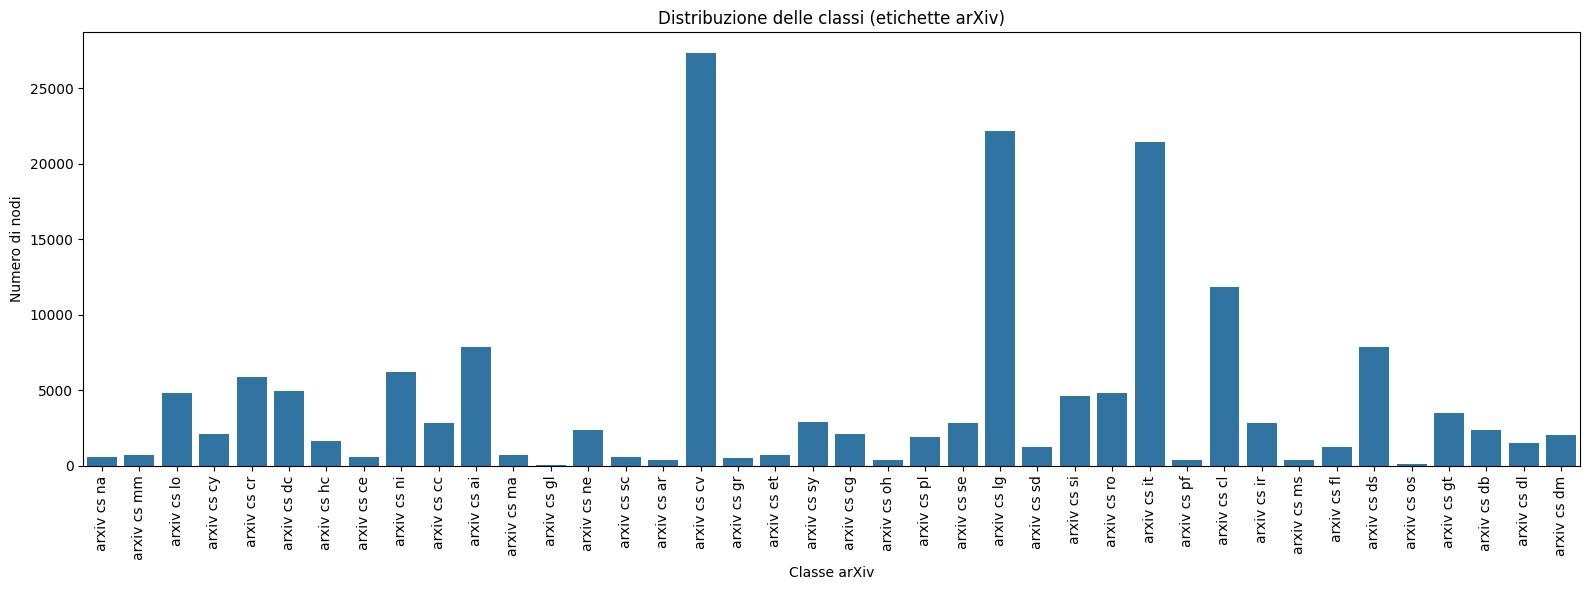

In [7]:
from rich.console import Console
from rich.table import Table
from rich import box

# Calcola distribuzione
y = data.y.view(-1).numpy()
counts = pd.Series(y).value_counts().sort_index()

# === RICH: Tabella colorata
console = Console()
table = Table(title="📊 Distribuzione delle Classi ArXiv", box=box.SQUARE)

table.add_column("Classe", justify="center", style="cyan", no_wrap=True)
table.add_column("Nome", justify="left", style="green")
table.add_column("Numero Articoli", justify="right", style="magenta")

for i, count in enumerate(counts):
    table.add_row(f"{i:2d}", class_names[i], str(count))

console.print(table)


plt.figure(figsize=(16, 6))
sns.barplot(x=class_names, y=counts.values)
plt.title("Distribuzione delle classi (etichette arXiv)")
plt.xlabel("Classe arXiv")
plt.ylabel("Numero di nodi")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("label_distribution_named.png")
plt.show()


In [8]:
split_idx = dataset.get_idx_split()
for split in ["train", "valid", "test"]:
    idx = split_idx[split]
    print(f"{split.capitalize()} set: {len(idx)} nodi ({len(idx) / data.num_nodes:.2%})")


Train set: 90941 nodi (53.70%)
Valid set: 29799 nodi (17.60%)
Test set: 48603 nodi (28.70%)


🕒 Anni min/max: 1971 - 2020


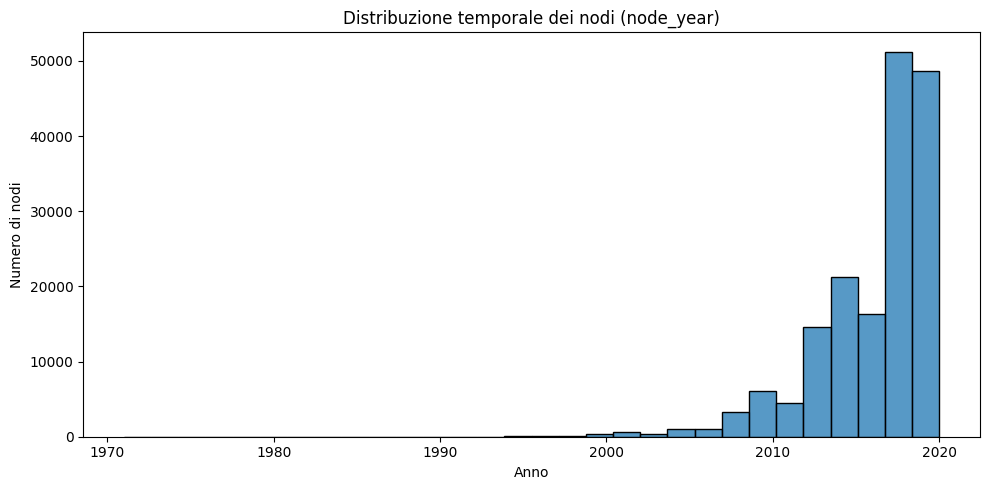

In [9]:
node_year = data.node_year.view(-1).numpy()
print("🕒 Anni min/max:", node_year.min(), "-", node_year.max())

plt.figure(figsize=(10, 5))
sns.histplot(node_year, bins=30)
plt.title("Distribuzione temporale dei nodi (node_year)")
plt.xlabel("Anno")
plt.ylabel("Numero di nodi")
plt.tight_layout()
plt.savefig("year_distribution.png")
plt.show()


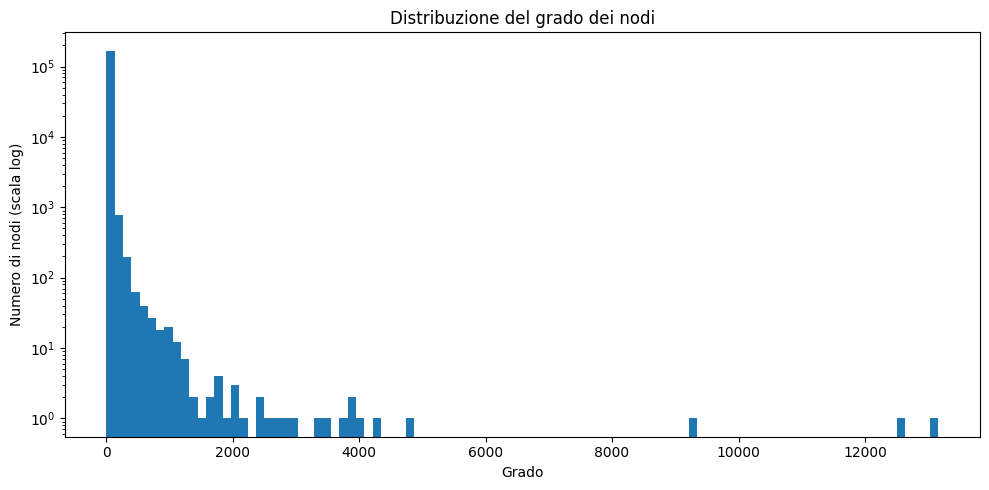

In [10]:
edge_index = data.edge_index.numpy()
dst = edge_index[1]
degree = np.bincount(dst, minlength=data.num_nodes)

plt.figure(figsize=(10, 5))
plt.hist(degree, bins=100, log=True)
plt.title("Distribuzione del grado dei nodi")
plt.xlabel("Grado")
plt.ylabel("Numero di nodi (scala log)")
plt.tight_layout()
plt.savefig("degree_distribution.png")
plt.show()


In [11]:
def visualizza_sottografo_khop(data, nodo_centrale=0, k=2, class_names=None):
    import networkx as nx
    from torch_geometric.utils import to_networkx, k_hop_subgraph
    import matplotlib.patches as mpatches

    print(f"📷 Generazione sottografo {k}-hop dal nodo {nodo_centrale}...")

    # Estrazione del sottografo
    nodi_sub, edge_index_sub, _, _ = k_hop_subgraph(
        node_idx=nodo_centrale,
        num_hops=k,
        edge_index=data.edge_index,
        relabel_nodes=True
    )

    # Limite massimo per evitare grafi illeggibili
    if nodi_sub.shape[0] > 300:
        print(f"⚠️ Sottografo troppo grande ({nodi_sub.shape[0]} nodi). Visualizzazione saltata.")
        return

    # Prepara sottografo
    sub_data = data.clone()
    sub_data.edge_index = edge_index_sub
    sub_data.num_nodes = nodi_sub.shape[0]
    y_sub = data.y[nodi_sub].view(-1).tolist()

    # Palette colori
    palette = sns.color_palette("tab20", 40)
    unique_labels = sorted(set(y_sub))
    colori_nodi = [palette[label % len(palette)] for label in y_sub]

    # Costruzione legenda
    legend_handles = []
    if class_names and len(unique_labels) <= 15:
        for label in unique_labels:
            nome = class_names[label]
            patch = mpatches.Patch(color=palette[label % len(palette)], label=nome)
            legend_handles.append(patch)

    # Costruzione grafo e posizione nodi
    G = to_networkx(sub_data, to_undirected=True)
    pos = nx.kamada_kawai_layout(G)

    # Plot
    plt.figure(figsize=(9, 9))
    nx.draw(
        G, pos,
        node_color=colori_nodi,
        node_size=40,
        edge_color="gray",
        alpha=0.75
    )
    plt.title(f"Sottografo {k}-hop dal nodo {nodo_centrale} (colori per classe)")
    plt.axis("off")

    if legend_handles:
        plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

    plt.tight_layout()
    plt.savefig("subgraph_khop_colored.png", bbox_inches="tight")
    plt.show()



Script di node exploration in senso letterale, in quanto grazie alla libreria ipywidgest siamo in gardo di esplorare fisicamente la struttura del dataset


In [12]:
from ipywidgets import interact, IntSlider, Dropdown
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def esplora_grafo_interattivo(data, class_names=None, max_nodi=500):
    import networkx as nx
    from torch_geometric.utils import to_networkx, k_hop_subgraph
    import matplotlib.patches as mpatches

    def visualizza(nodo_centrale, k):
        print(f"🔍 Generazione sottografo {k}-hop dal nodo {nodo_centrale}...")

        nodi_sub, edge_index_sub, _, _ = k_hop_subgraph(
            node_idx=nodo_centrale,
            num_hops=k,
            edge_index=data.edge_index,
            relabel_nodes=True
        )

        if nodi_sub.shape[0] > max_nodi:
            print(f"⚠️ Sottografo troppo grande ({nodi_sub.shape[0]} nodi). Visualizzazione saltata.")
            return

        sub_data = data.clone()
        sub_data.edge_index = edge_index_sub
        sub_data.num_nodes = nodi_sub.shape[0]
        y_sub = data.y[nodi_sub].view(-1).tolist()

        palette = sns.color_palette("tab20", 40)
        unique_labels = sorted(set(y_sub))
        colori_nodi = [palette[label % len(palette)] for label in y_sub]

        legend_handles = []
        if class_names and len(unique_labels) <= 15:
            for label in unique_labels:
                nome = class_names[label]
                patch = mpatches.Patch(color=palette[label % len(palette)], label=nome)
                legend_handles.append(patch)

        G = to_networkx(sub_data, to_undirected=True)
        pos = nx.kamada_kawai_layout(G)

        plt.figure(figsize=(8, 8))
        nx.draw(
            G, pos,
            node_color=colori_nodi,
            node_size=40,
            edge_color="gray",
            alpha=0.75
        )
        plt.title(f"Sottografo {k}-hop dal nodo {nodo_centrale}")
        plt.axis("off")

        if legend_handles:
            plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

        plt.tight_layout()
        plt.show()

    # Widget interattivi
    max_node_id = data.num_nodes - 1
    interact(
        visualizza,
        nodo_centrale=IntSlider(min=0, max=max_node_id, step=1, value=0, description="Nodo"),
        k=IntSlider(min=1, max=5, step=1, value=2, description="K-hop")
    )


In [13]:
esplora_grafo_interattivo(data, class_names=class_names)


interactive(children=(IntSlider(value=0, description='Nodo', max=169342), IntSlider(value=2, description='K-ho…

Qua vediamo i paper piu citati, possiamo notare la popolarità di topic su ml e visione artificiale (Computer Vision)

In [14]:
import pandas as pd
import networkx as nx
from torch_geometric.utils import to_networkx
from ogb.nodeproppred import PygNodePropPredDataset
from rich.console import Console
from rich.table import Table
from rich import box

# === 1. Carica dataset e titoli ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
data = dataset[0]

df_titles = pd.read_csv("dataset/titleabs.tsv", sep="\t", names=["paper_id", "title", "abstract"])
df_titles["paper_id"] = df_titles["paper_id"].astype(str)

# === 2. Carica mapping: OGBN index → MAG paper ID
mapping_path = "dataset/ogbn-arxiv/ogbn_arxiv/mapping/nodeidx2paperid.csv.gz"
df_mapping = pd.read_csv(mapping_path, header=None, names=["MAG_ID"])
ogbn_to_mag = df_mapping["MAG_ID"].astype(str).tolist()

# === 3. Mapping classi arXiv
mapping_path = 'dataset/ogbn-arxiv/ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz'
def load_label_mapping(path):
    import gzip, csv
    label_to_category = {}
    with gzip.open(path, 'rt') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            label_to_category[int(row[0])] = row[1]
    return label_to_category

label_to_category = load_label_mapping(mapping_path)
class_names = [label_to_category[i] for i in range(len(label_to_category))]

# === 4. Mapping leggibile
arxiv_nomi_umani = {
    "arxiv cs ai": "Intelligenza Artificiale",
    "arxiv cs ar": "Architettura Hardware",
    "arxiv cs cc": "Teoria della Computazione",
    "arxiv cs ce": "Ingegneria Informatica",
    "arxiv cs cg": "Grafica Computazionale",
    "arxiv cs cl": "Elaborazione Linguaggio",
    "arxiv cs cr": "Sicurezza Informatica",
    "arxiv cs cv": "Visione Artificiale",
    "arxiv cs cy": "Cybersecurity",
    "arxiv cs db": "Basi di Dati",
    "arxiv cs dc": "Computazione Distribuita",
    "arxiv cs dl": "Deep Learning",
    "arxiv cs dm": "Data Mining",
    "arxiv cs ds": "Algoritmi e Strutture Dati",
    "arxiv cs et": "Informatica Teorica",
    "arxiv cs fl": "Logica Formale",
    "arxiv cs gl": "Letteratura Generale ",
    "arxiv cs gr": "Teoria dei Grafi",
    "arxiv cs gt": "Teoria dei Giochi",
    "arxiv cs hc": "Interazione Uomo-Macchina",
    "arxiv cs ir": "Recupero dell’Informazione",
    "arxiv cs it": "Teoria dell’Informazione",
    "arxiv cs lg": "Machine Learning",
    "arxiv cs lo": "Logica Computazionale",
    "arxiv cs ma": "Agenti e Multiagenti",
    "arxiv cs mm": "Multimedia",
    "arxiv cs ms": "Software Matematico",
    "arxiv cs na": "Analisi Numerica",
    "arxiv cs ne": "Reti Neurali",
    "arxiv cs ni": "Reti Informatiche",
    "arxiv cs oh": "Hardware Open",
    "arxiv cs os": "Sistemi Operativi",
    "arxiv cs pf": "Formal Proofs",
    "arxiv cs pl": "Linguaggi di Programmazione",
    "arxiv cs ro": "Robotica",
    "arxiv cs sc": "Simulazioni",
    "arxiv cs sd": "Sistemi Distribuiti",
    "arxiv cs se": "Ingegneria del Software",
    "arxiv cs si": "Segnali e Sistemi",
    "arxiv cs sy": "Sistemi Dinamici"
}


# === 5. Calcola in-degree e top paper
G = to_networkx(data, to_undirected=False)
in_degrees = dict(G.in_degree())
top_10 = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]

top_rows = []
for ogbn_id, indeg in top_10:
    mag_id = ogbn_to_mag[ogbn_id]
    label_idx = int(data.y[ogbn_id].item())
    codice_categoria = class_names[label_idx]
    categoria = arxiv_nomi_umani.get(codice_categoria, codice_categoria)

    row = df_titles[df_titles["paper_id"] == mag_id]
    title = row.iloc[0]["title"] if not row.empty else "[Titolo non trovato]"

    top_rows.append({
        "OGBN ID": ogbn_id,
        "MAG ID": mag_id,
        "In-Degree": indeg,
        "Categoria": categoria,
        "Titolo": title
    })

# === 6. Visualizzazione con Rich
console = Console()
table = Table(title="Top 10 Paper per In-Degree", box=box.SIMPLE_HEAVY)

table.add_column("OGBN ID", justify="center", style="cyan")
table.add_column("MAG ID", justify="center", style="bright_black")
table.add_column("Citazioni", justify="right", style="magenta")
table.add_column("Categoria", style="green")
table.add_column("Titolo", style="yellow")

for row in top_rows:
    titolo = row["Titolo"][:80] + ("..." if len(row["Titolo"]) > 80 else "")
    table.add_row(
        str(row["OGBN ID"]),
        row["MAG ID"],
        str(row["In-Degree"]),
        row["Categoria"],
        titolo
    )

console.print(table)

# === 7. Salva MAG ID e Titolo per uso successivo (es. query OpenAlex)
df_export = pd.DataFrame(top_rows)[["MAG ID", "Titolo"]]
df_export.to_csv("top_mag_ids.csv", index=False)
print("✅ File salvato: top_mag_ids.csv")



                                            Top 10 Paper per In-Degree                                             
                                                                                                                   
  OGBN ID     MAG ID     Citazioni   Categoria                 Titolo                                              
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
   1353     1519399059       13155   Machine Learning          a maximum entropy theorem with applications to the  
                                                               measurement of biodiversity                         
   67166    2949649109       12527   Visione Artificiale       automatic assessment of full left ventricular       
                                                               coverage in cardiac cine magnetic ...               
   25208    1682151956        9244   Visione Artificiale       actors vs shared memory two models at work on big   
                                                               data application frameworks                         
   69794    2949110617        4779   Machine Learning          parallel exhaustive search without coordination     
   93649    2952020069        4238   Visione Artificiale       activity dynamics in collaboration networks         
  115359    2131297149        4033   Elaborazione Linguaggio   hybrid xml retrieval combining information          
                                                               retrieval and a native xml database                 
   22035    2950157671        3861   Visione Artificiale       sensitivity analysis of minimum spanning trees in   
                                                               sub inverse ackermann time                          
  133376    2953083211        3844   Visione Artificiale       joint optimization and variable selection of high   
                                                               dimensional gaussian processes                      
  106699    2950133701        3737   Elaborazione Linguaggio   practical algorithms for finding extremal sets      
  166425    2952624498        3407   Visione Artificiale       identifiers in registers describing network         
                                                               algorithms with logic                              

✅ File salvato: top_mag_ids.csv


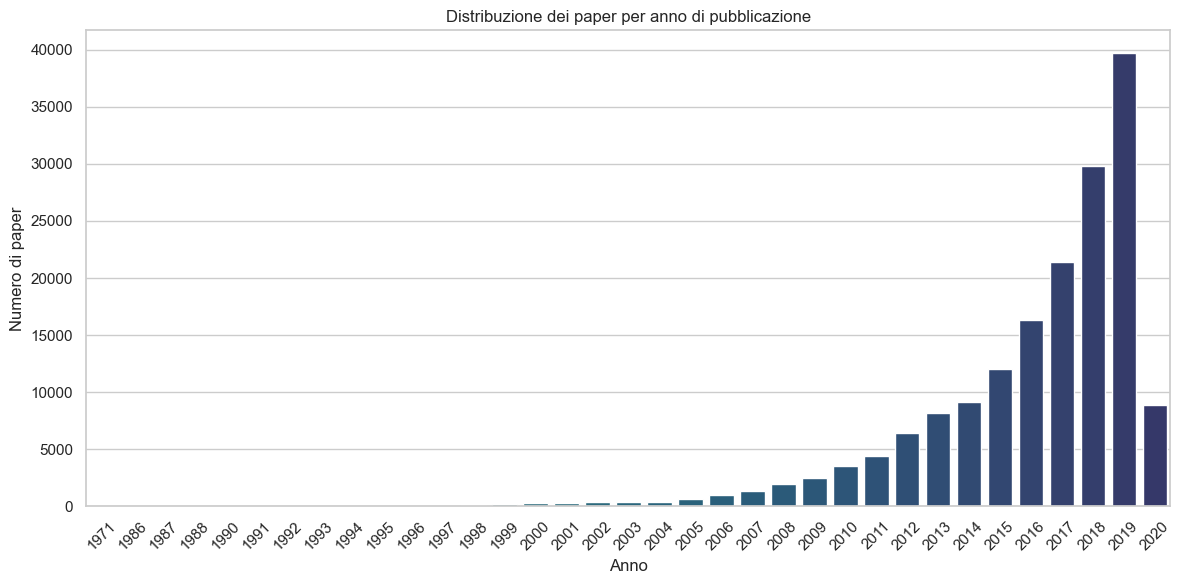

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estrai gli anni
years = data.node_year.squeeze().tolist()
df_years = pd.DataFrame({"Anno": years})

# Plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
sns.countplot(data=df_years, x="Anno", hue="Anno", palette="crest", legend=False)

plt.title("Distribuzione dei paper per anno di pubblicazione")
plt.ylabel("Numero di paper")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import networkx as nx
from torch_geometric.utils import to_networkx
from rich.console import Console
from rich.table import Table
from rich import box

# === 1. Costruisci grafo e calcola in-degree
G = to_networkx(data, to_undirected=False)
in_degrees = dict(G.in_degree())

# === 2. Estrai anno di pubblicazione per ogni nodo
years = data.node_year.squeeze().tolist()
year_dict = {i: years[i] for i in range(len(years))}

# === 3. Trova il paper più citato per ogni anno
top_by_year = {}
for node_id, year in year_dict.items():
    indeg = in_degrees.get(node_id, 0)
    if year not in top_by_year or indeg > top_by_year[year]["in_degree"]:
        top_by_year[year] = {"node_id": node_id, "in_degree": indeg}

# === 4. Costruisci la lista dei top paper
top_rows = []
for year, info in sorted(top_by_year.items()):
    node_id = info["node_id"]
    indeg = info["in_degree"]
    mag_id = ogbn_to_mag[node_id]
    label_idx = int(data.y[node_id].item())
    label = class_names[label_idx]
    categoria = arxiv_nomi_umani.get(label, label)

    row = df_titles[df_titles["paper_id"] == mag_id]
    title = row.iloc[0]["title"] if not row.empty else "[Titolo non trovato]"

    top_rows.append({
        "Anno": year,
        "Citazioni": indeg,
        "Categoria": categoria,
        "Titolo": title,
        "MAG ID": mag_id  # 👈 AGGIUNTO QUI
    })

# === 5. Visualizzazione con Rich
console = Console()
table = Table(title="📚 Top Paper per Anno", box=box.SQUARE)
table.add_column("Anno", justify="center", style="cyan")
table.add_column("Citazioni", justify="center", style="magenta")
table.add_column("Categoria", style="green")
table.add_column("Titolo", style="yellow")

for row in top_rows:
    titolo = row["Titolo"][:80] + ("..." if len(row["Titolo"]) > 80 else "")
    table.add_row(str(row["Anno"]), str(row["Citazioni"]), row["Categoria"], titolo)

console.print(table)

# === 6. Salva MAG ID e Titolo per query future (OpenAlex ecc.)
df_export = pd.DataFrame(top_rows)[["MAG ID", "Titolo"]]
df_export.to_csv("top_mag_ids.csv", index=False)
print("✅ File salvato: top_mag_ids.csv")


                                               📚 Top Paper per Anno                                               
┌──────┬───────────┬─────────────────────────────┬────────────────────────────────────────────────────────────────┐
│ Anno │ Citazioni │ Categoria                   │ Titolo                                                         │
├──────┼───────────┼─────────────────────────────┼────────────────────────────────────────────────────────────────┤
│ 1971 │    178    │ Segnali e Sistemi           │ writing on dirty flash memory                                  │
│ 1986 │     4     │ Reti Informatiche           │ emotion recognition from speech based on relevant feature and  │
│      │           │                             │ majority voting                                                │
│ 1987 │     3     │ Logica Computazionale       │ provable methods for training neural networks with sparse      │
│      │           │                             │ connectivity                                                   │
│ 1988 │     3     │ Simulazioni                 │ a stochastic temporal model of polyphonic midi performance     │
│      │           │                             │ with ornaments                                                 │
│ 1990 │    124    │ Intelligenza Artificiale    │ checks and controls in spreadsheets                            │
│ 1991 │    45     │ Algoritmi e Strutture Dati  │ google matrix dynamical attractors and ulam networks           │
│ 1992 │    24     │ Algoritmi e Strutture Dati  │ does a plane imitate a bird does computer vision have to       │
│      │           │                             │ follow biological parad...                                     │
│ 1993 │    15     │ Intelligenza Artificiale    │ an approximation algorithm for a shortest dubins path problem  │
│ 1994 │    86     │ Intelligenza Artificiale    │ enhanced blind decoding of tardos codes with new map based     │
│      │           │                             │ functions                                                      │
│ 1995 │    54     │ Linguaggi di Programmazione │ the complexity of free flood it on 2ixn boards                 │
│ 1996 │    331    │ Intelligenza Artificiale    │ predicting tongue motion in unlabeled ultrasound videos using  │
│      │           │                             │ convolutional lstm...                                          │
│ 1997 │    28     │ Intelligenza Artificiale    │ a linear memory algorithm for baum welch training              │
│ 1998 │    169    │ Machine Learning            │ a betweenness structure entropy of complex networks            │
│ 1999 │    154    │ Machine Learning            │ accurate and efficient private release of datacubes and        │
│      │           │                             │ contingency tables                                             │
│ 2000 │    111    │ Intelligenza Artificiale    │ learning contour fragment based shape model with and or tree   │
│      │           │                             │ representation                                                 │
│ 2001 │    106    │ Algoritmi e Strutture Dati  │ rock climber distance frogs versus dogs                        │
│ 2002 │    342    │ Intelligenza Artificiale    │ on the robustness of temporal properties for stochastic models │
│ 2003 │    211    │ Elaborazione Linguaggio     │ object oriented program comprehension effect of expertise task │
│      │           │                             │ and phase                                                      │
│ 2004 │    226    │ Teoria dell’Informazione    │ a fully convolutional neural network based structured          │
│      │           │                             │ prediction approach toward...                                  │
│ 2005 │    214    │ Elaborazione Linguaggio     │ hiring under uncertainty                                       │
│ 2006 │    208    │ Teoria dell’Informazione    │ multi 

✅ File salvato: top_mag_ids.csv


C:\Users\paolo\AppData\Local\Temp\ipykernel_7324\1450844364.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["Conteggio_log"] = np.log1p(df_top["Conteggio"])  # log(1 + x)


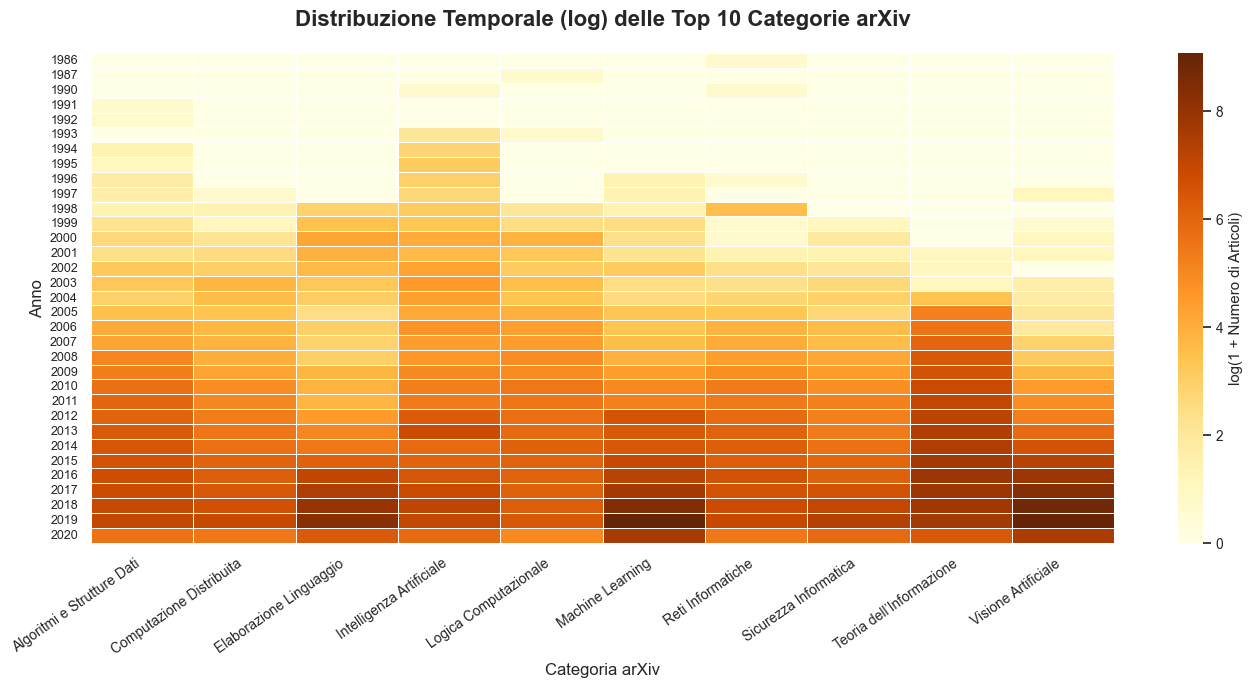

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Costruzione come prima
labels = data.y.view(-1).tolist()
years = data.node_year.view(-1).tolist()

df_nodes = pd.DataFrame({
    "Anno": years,
    "Codice": [class_names[int(l)] for l in labels]
})
df_nodes["Categoria"] = df_nodes["Codice"].map(arxiv_nomi_umani)

df_counts = df_nodes.groupby(["Anno", "Categoria"]).size().reset_index(name="Conteggio")
top10 = df_nodes["Categoria"].value_counts().nlargest(10).index.tolist()
df_top = df_counts[df_counts["Categoria"].isin(top10)]

# === Applica log trasformazione (per maggiore leggibilità)
df_top["Conteggio_log"] = np.log1p(df_top["Conteggio"])  # log(1 + x)

# === Pivot per heatmap
pivot_table = df_top.pivot(index="Anno", columns="Categoria", values="Conteggio_log").fillna(0)

# === Heatmap curata con scala logaritmica
plt.figure(figsize=(14, 7))
sns.set(font_scale=0.9)

ax = sns.heatmap(
    pivot_table,
    cmap="YlOrBr",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "log(1 + Numero di Articoli)"}
)

plt.title("Distribuzione Temporale (log) delle Top 10 Categorie arXiv", fontsize=16, weight="bold", pad=20)
plt.ylabel("Anno", fontsize=12)
plt.xlabel("Categoria arXiv", fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()


In [18]:
from collections import Counter
import pandas as pd
import string
from rich.console import Console
from rich.table import Table
from wordcloud import STOPWORDS

# === 1. Prepara stopwords personalizzate ===
stopwords = set(STOPWORDS)
stopwords.update({"using", "based", "approach", "via", "new", "method", "model", "analysis", "learning", "results", "paper"})

# === 2. Funzione per conteggio parole ===
def conta_parole(series, stopwords, top_n=30):
    all_text = " ".join(series.fillna("").astype(str)).lower()
    all_text = all_text.translate(str.maketrans('', '', string.punctuation))
    words = all_text.split()
    filtered = [w for w in words if w not in stopwords and len(w) > 2]
    counter = Counter(filtered)
    return counter.most_common(top_n)

# === 3. Funzione per stampa tabella ===
def stampa_rich_tabella(freq_list, titolo):
    console = Console()
    table = Table(title=titolo, show_lines=True)
    table.add_column("🔤 Parola", style="bold cyan")
    table.add_column("📊 Frequenza", justify="right", style="bold magenta")

    for word, count in freq_list:
        table.add_row(word, str(count))
    
    console.print(table)

# === 4. Applica alle colonne 'title' e 'abstract'
freq_titoli = conta_parole(df_titles["title"], stopwords, top_n=30)
freq_abstract = conta_parole(df_titles["abstract"], stopwords, top_n=30)

# === 5. Visualizza con Rich
stampa_rich_tabella(freq_titoli, "📘 Top 30 Parole nei Titoli")
stampa_rich_tabella(freq_abstract, "📙 Top 30 Parole negli Abstract")


   📘 Top 30 Parole nei Titoli   
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ 🔤 Parola      ┃ 📊 Frequenza ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ networks       │        17190 │
├────────────────┼──────────────┤
│ deep           │        10268 │
├────────────────┼──────────────┤
│ neural         │         9931 │
├────────────────┼──────────────┤
│ network        │         9007 │
├────────────────┼──────────────┤
│ data           │         8268 │
├────────────────┼──────────────┤
│ multi          │         7777 │
├────────────────┼──────────────┤
│ systems        │         6811 │
├────────────────┼──────────────┤
│ detection      │         6102 │
├────────────────┼──────────────┤
│ image          │         5205 │
├────────────────┼──────────────┤
│ time           │         5089 │
├────────────────┼──────────────┤
│ efficient      │         4480 │
├────────────────┼──────────────┤
│ information    │         4379 │
├────────────────┼──────────────┤
│ models         │         4143 │
├────────────────┼──────────────┤
│ graph          │         3946 │
├────────────────┼──────────────┤
│ classification │         3774 │
├────────────────┼──────────────┤
│ distributed    │         3707 │
├────────────────┼──────────────┤
│ recognition    │         3615 │
├────────────────┼──────────────┤
│ algorithm      │         3614 │
├────────────────┼──────────────┤
│ codes          │         3595 │
├────────────────┼──────────────┤
│ convolutional  │         3563 │
├────────────────┼──────────────┤
│ optimal        │         3562 │
├────────────────┼──────────────┤
│ algorithms     │         3449 │
├────────────────┼──────────────┤
│ estimation     │         3405 │
├────────────────┼──────────────┤
│ optimization   │         3340 │
├────────────────┼──────────────┤
│ graphs         │         3270 │
├────────────────┼──────────────┤
│ linear         │         3247 │
├────────────────┼──────────────┤
│ machine        │         3209 │
├────────────────┼──────────────┤
│ system         │         3183 │
├────────────────┼──────────────┤
│ control        │         3134 │
├────────────────┼──────────────┤
│ wireless       │         3063 │
└────────────────┴──────────────┘

    📙 Top 30 Parole negli    
           Abstract           
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ 🔤 Parola   ┃ 📊 Frequenza ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ data        │       108406 │
├─────────────┼──────────────┤
│ problem     │        85448 │
├─────────────┼──────────────┤
│ network     │        81790 │
├─────────────┼──────────────┤
│ show        │        79921 │
├─────────────┼──────────────┤
│ algorithm   │        74175 │
├─────────────┼──────────────┤
│ proposed    │        67468 │
├─────────────┼──────────────┤
│ performance │        65374 │
├─────────────┼──────────────┤
│ networks    │        58361 │
├─────────────┼──────────────┤
│ information │        56781 │
├─────────────┼──────────────┤
│ propose     │        55714 │
├─────────────┼──────────────┤
│ two         │        55389 │
├─────────────┼──────────────┤
│ time        │        53949 │
├─────────────┼──────────────┤
│ models      │        53512 │
├─────────────┼──────────────┤
│ system      │        50672 │
├─────────────┼──────────────┤
│ methods     │        49086 │
├─────────────┼──────────────┤
│ different   │        47571 │
├─────────────┼──────────────┤
│ algorithms  │        46634 │
├─────────────┼──────────────┤
│ number      │        46236 │
├─────────────┼──────────────┤
│ used        │        44899 │
├─────────────┼──────────────┤
│ systems     │        44080 │
├─────────────┼──────────────┤
│ one         │        42647 │
├─────────────┼──────────────┤
│ neural      │        39941 │
├─────────────┼──────────────┤
│ work        │        39586 │
├─────────────┼──────────────┤
│ use         │        39437 │
├─────────────┼──────────────┤
│ present     │        39234 │
├─────────────┼──────────────┤
│ set         │        38919 │
├─────────────┼──────────────┤
│ first       │        36782 │
├─────────────┼──────────────┤
│ image       │        36224 │
├─────────────┼──────────────┤
│ framework   │        36196 │
├─────────────┼──────────────┤
│ training    │        35615 │
└─────────────┴──────────────┘

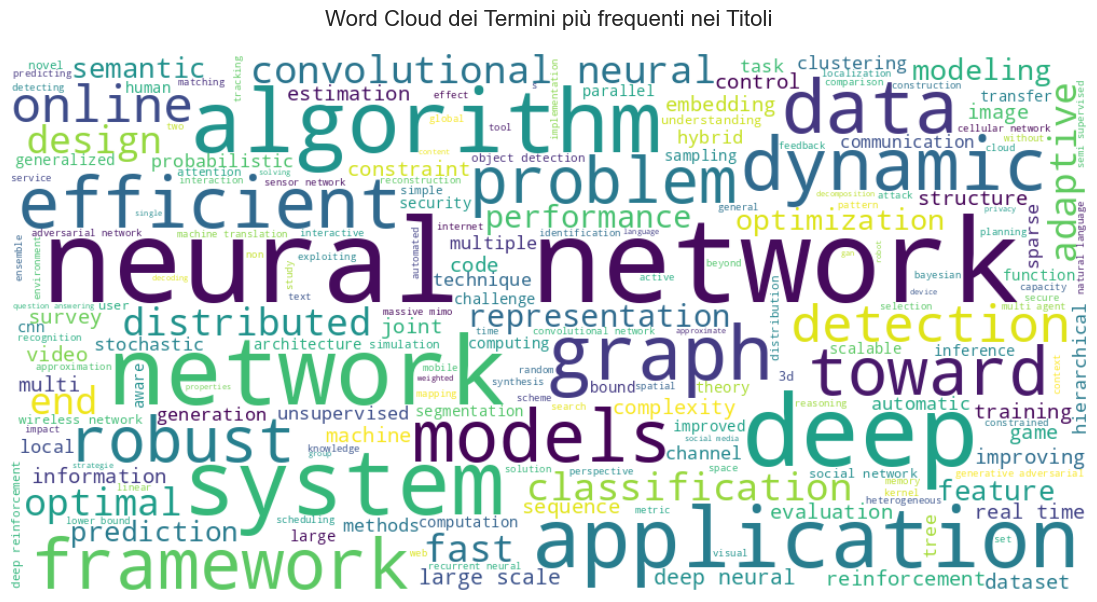

In [19]:
# 📚 Analisi Word Cloud dei Titoli più frequenti

import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import string

# === 1. Carica i titoli
df_titles = pd.read_csv("dataset/titleabs.tsv", sep="\t", names=["paper_id", "title", "abstract"])
df_titles["title"] = df_titles["title"].fillna("").astype(str)

# === 2. Pre-elaborazione del testo
stopwords = set(STOPWORDS)
custom_stopwords = {"using", "based", "approach", "via", "new", "method", "model", "analysis", "learning"}
stopwords.update(custom_stopwords)

# Unione di tutti i titoli in un unico testo
all_titles = " ".join(df_titles["title"]).lower()

# Rimozione della punteggiatura
translator = str.maketrans("", "", string.punctuation)
clean_text = all_titles.translate(translator)

# === 3. Generazione della word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords,
    max_words=200,
    colormap='viridis',
    contour_color='steelblue',
    contour_width=2
).generate(clean_text)

# === 4. Visualizzazione
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud dei Termini più frequenti nei Titoli", fontsize=16, pad=20)
plt.show()


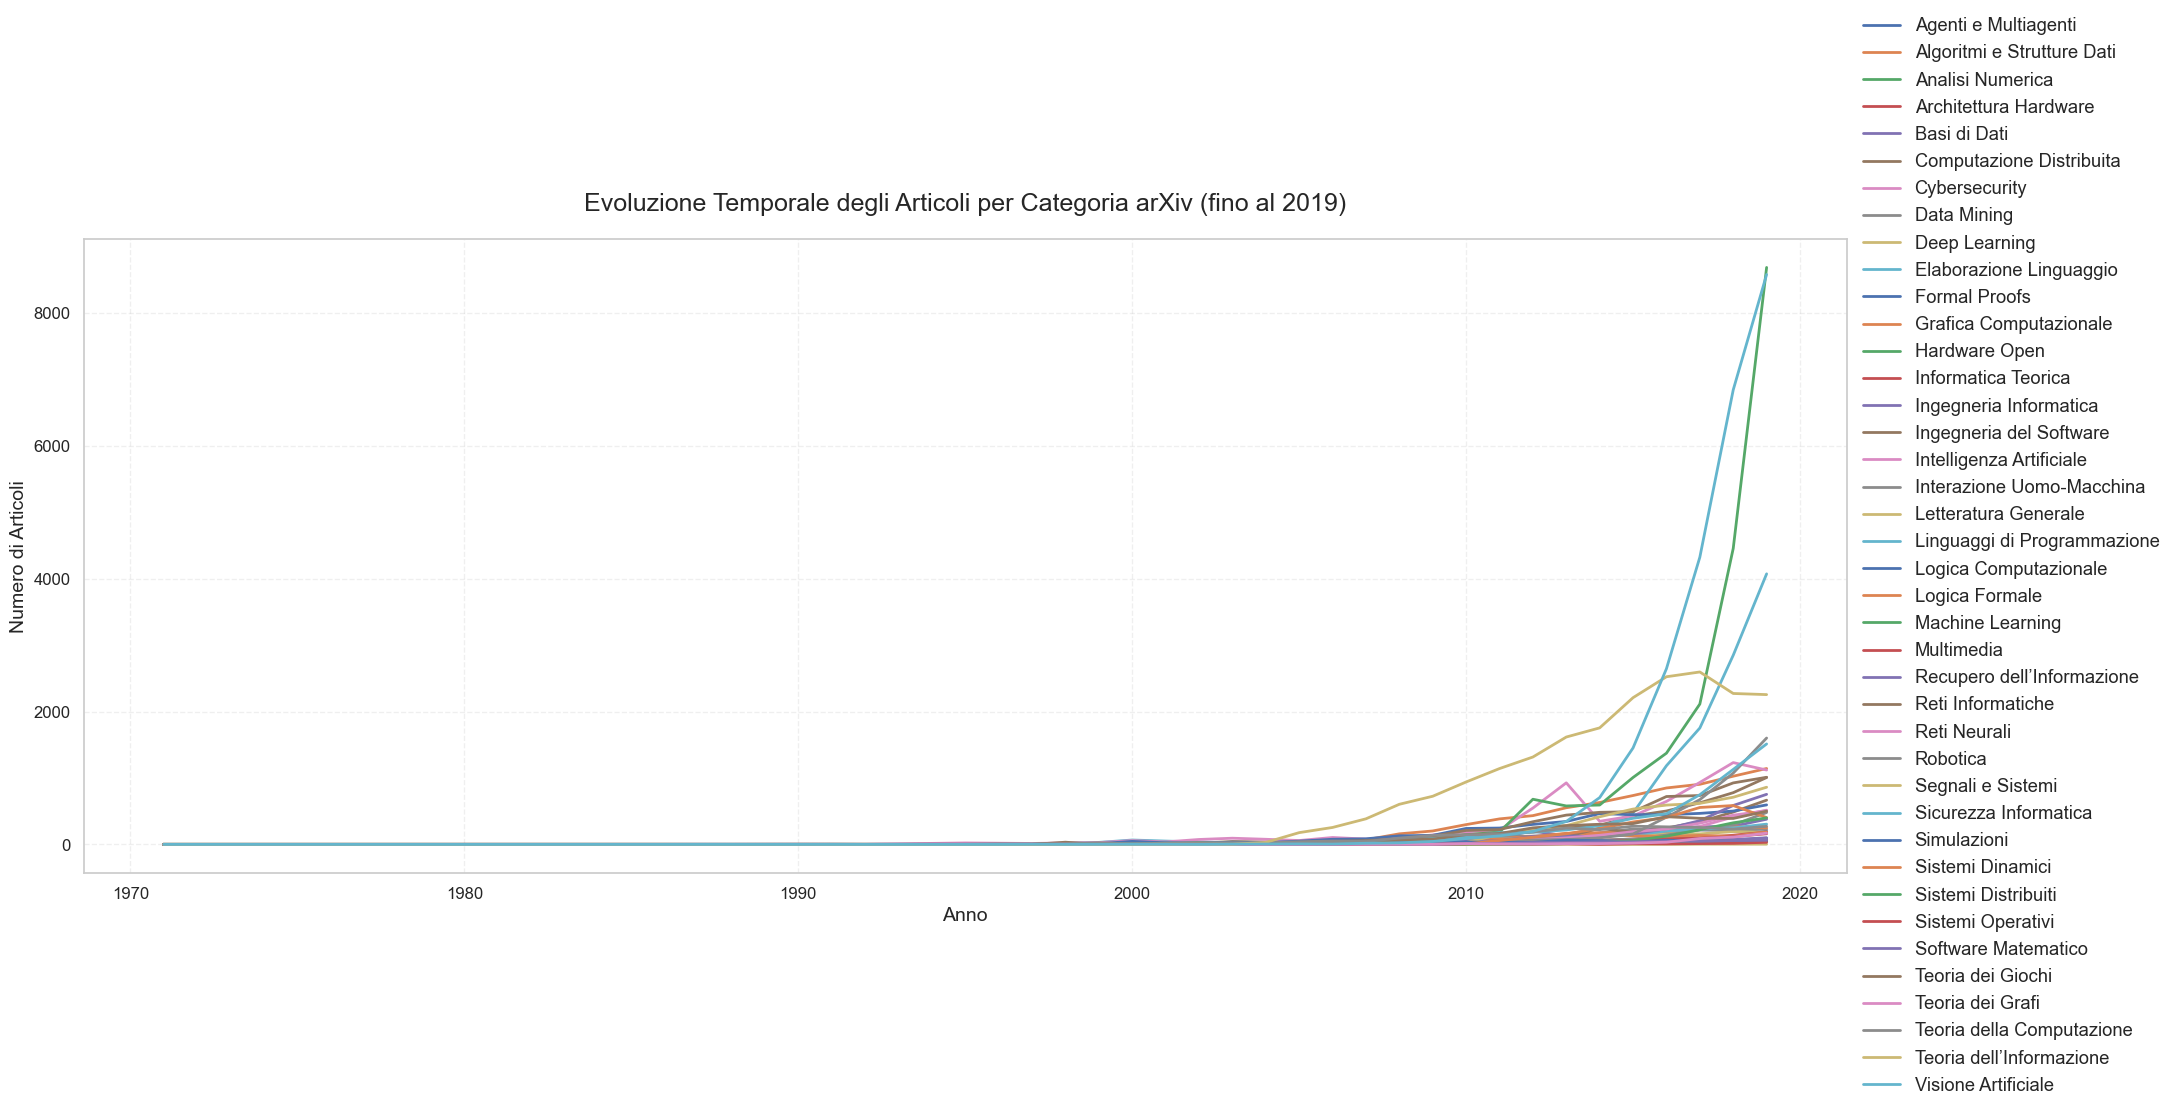

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Costruzione del DataFrame con nomi umani
df_nodes = pd.DataFrame({
    "Anno": data.node_year.view(-1).tolist(),
    "Codice": [class_names[int(y)] for y in data.y.view(-1).tolist()]
})
df_nodes["Categoria"] = df_nodes["Codice"].map(arxiv_nomi_umani)

# 2. Filtro fino al 2019
df_nodes = df_nodes[df_nodes["Anno"] <= 2019]

# 3. Conteggio articoli per anno e categoria
df_trend = df_nodes.groupby(["Anno", "Categoria"]).size().reset_index(name="Articoli")
pivot = df_trend.pivot(index="Anno", columns="Categoria", values="Articoli").fillna(0)

# 4. Plot professionale
plt.figure(figsize=(22, 10))
sns.set(style="whitegrid", font_scale=1.2)

for categoria in pivot.columns:
    plt.plot(pivot.index, pivot[categoria], label=categoria, linewidth=2)

# 5. Estetica e layout
plt.title("Evoluzione Temporale degli Articoli per Categoria arXiv (fino al 2019)", fontsize=18, pad=20)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Numero di Articoli", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
plt.tight_layout()
plt.show()


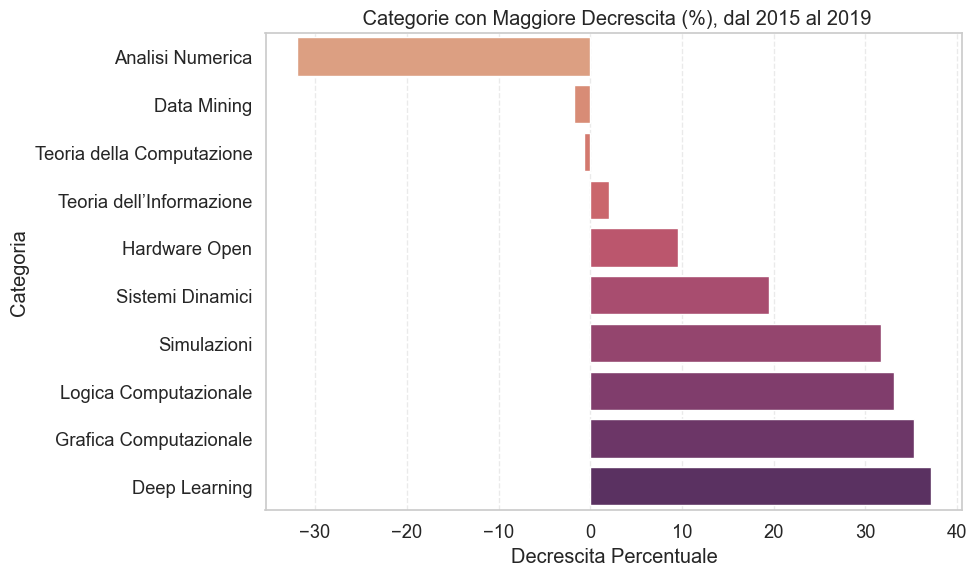

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assicurati di avere già questo
# - data
# - class_names
# - arxiv_nomi_umani

# 1. Costruzione DataFrame nodi
labels = data.y.view(-1).tolist()
years = data.node_year.view(-1).tolist()

df_nodes = pd.DataFrame({
    "Anno": years,
    "Codice": [class_names[int(l)] for l in labels]
})
df_nodes["Categoria umana"] = df_nodes["Codice"].map(arxiv_nomi_umani)

# 2. Filtra solo dal 2015 al 2019
df_recent = df_nodes[df_nodes["Anno"].between(2015, 2019)]

# 3. Conta per anno e categoria
counts_by_year_cat = df_recent.groupby(["Anno", "Categoria umana"]).size().unstack(fill_value=0)

# 4. Calcola variazione percentuale (2019 vs 2015)
perc_diff = ((counts_by_year_cat.loc[2019] - counts_by_year_cat.loc[2015]) / counts_by_year_cat.loc[2015]) * 100

# 5. Ordina e seleziona le 10 più in decrescita
top_decrescita = perc_diff.sort_values().head(10)

# 6. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_decrescita.values, y=top_decrescita.index, hue=top_decrescita.index, palette="flare", legend=False)
plt.title(" Categorie con Maggiore Decrescita (%), dal 2015 al 2019")
plt.xlabel("Decrescita Percentuale")
plt.ylabel("Categoria")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [22]:
top10_mag_ids = [ogbn_to_mag[data.x.size(0) - len(top_rows) + i] for i in range(10)]

# Oppure direttamente dai nodi, se conservati
# Se hai salvato i node_id originali (come suggerito), meglio ancora:
top10_mag_ids = [ogbn_to_mag[info["node_id"]] for info in top_by_year.values()]
top10_mag_ids = top10_mag_ids[:10]

print(top10_mag_ids)


['2950133701', '2949649109', '1519399059', '2952224880', '3012541776', '2950147620', '2951430429', '1931755669', '2949944631', '2511422681']


In [23]:
import requests
from rich.console import Console
from rich.table import Table
from rich import box

# Lista dei MAG_ID da interrogare (già estratti)
mag_ids = [
    '2950133701', '2949649109', '1519399059', '2952224880', '3012541776',
    '2950147620', '2951430429', '1931755669', '2949944631', '2511422681'
]

# Setup Rich
console = Console()
table = Table(title="🧑‍🔬 Autori e Titoli dei Top Paper", box=box.MINIMAL_DOUBLE_HEAD)
table.add_column("MAG ID", style="cyan", no_wrap=True)
table.add_column("Titolo", style="yellow")
table.add_column("Autori", style="green")

for mag_id in mag_ids:
    openalex_id = f"W{mag_id}"
    url = f"https://api.openalex.org/works/{openalex_id}"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            title = data.get("title", "[Titolo non disponibile]")
            authorships = data.get("authorships", [])
            autori = ", ".join([a['author']['display_name'] for a in authorships])
            table.add_row(mag_id, title[:80] + ("..." if len(title) > 80 else ""), autori)
        else:
            table.add_row(mag_id, "[Errore nella richiesta]", "❌")
    except Exception as e:
        table.add_row(mag_id, "[Errore di rete]", str(e))

console.print(table)


                                        🧑‍🔬 Autori e Titoli dei Top Paper                                         
             ╷                                                 ╷                                                   
  MAG ID     │ Titolo                                          │ Autori                                            
 ════════════╪═════════════════════════════════════════════════╪══════════════════════════════════════════════════ 
  2950133701 │ Practical Algorithms for Finding Extremal Sets  │ Martin Marinov, Nicholas Nash, David Gregg        
  2949649109 │ Automatic Assessment of Full Left Ventricular   │ Le Zhang, Ali Gooya, Marco Pereañez, Bo Dong,     
             │ Coverage in Cardiac Cine Magnetic ...           │ Stefan K. Piechnik, Stefan Neubauer, Steffen E.   
             │                                                 │ Petersen, Alejandro F. Frangi                     
  1519399059 │ A maximum entropy theorem with applications to  │ Tom Leinster                                      
             │ the measurement of biodiversity                 │                                                   
  2952224880 │ Alignment Based Kernel Learning with a          │ Arash Afkanpour, Csaba Szepesvári, Michael        
             │ Continuous Set of Base Kernels                  │ Bowling                                           
  3012541776 │ Utilizing Language Relatedness to improve       │ Anoop Kunchukuttan, Pushpak Bhattacharyya         
             │ Machine Translation: A Case Study on L...       │                                                   
  2950147620 │ A Fully Convolutional Neural Network based      │ Avijit Dasgupta, Sonam Singh                      
             │ Structured Prediction Approach Toward...        │                                                   
  2951430429 │ Light Field Saliency Detection with Deep        │ Jun Zhang, Yamei Liu, Shengping Zhang, Ronald     
             │ Convolutional Networks                          │ Poppe, Meng Wang                                  
  1931755669 │ Adaptive Replication in Distributed Content     │ Mathieu Leconte, Marc Lelarge, Laurent Massoulié  
             │ Delivery Networks                               │                                                   
  2949944631 │ HT-Paxos: High Throughput State-Machine         │ Vinit Kumar, Ajay Agarwal                         
             │ Replication Protocol for Large Clustered...     │                                                   
  2511422681 │ Physical Design Obfuscation of Hardware: A      │ Arunkumar Vijayakumar, Vinay C. Patil, Daniel     
             │ Comprehensive Investigation of Device...        │ Holcomb, Christof Paar, Sandip Kundu              
             ╵                                                 ╵

In [24]:
import pandas as pd
import networkx as nx
from torch_geometric.utils import to_networkx
from ogb.nodeproppred import PygNodePropPredDataset

# Carica dataset
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
data = dataset[0]

# Carica mapping OGBN → MAG ID
mapping_path = "dataset/ogbn-arxiv/ogbn_arxiv/mapping/nodeidx2paperid.csv.gz"
df_mapping = pd.read_csv(mapping_path, header=None, names=["MAG_ID"])
ogbn_to_mag = df_mapping["MAG_ID"].astype(str).tolist()

# Calcola in-degree
G = to_networkx(data, to_undirected=False)
in_degrees = dict(G.in_degree())

# Estrai top 100 paper per in-degree
top_k = 100
top_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:top_k]
top_mag_ids = [ogbn_to_mag[node_id] for node_id, _ in top_nodes]

# Salva in CSV
df_export = pd.DataFrame(top_mag_ids, columns=["MAG_ID"])
df_export.to_csv("top_100_mag_ids.csv", index=False)
print("✅ Salvato top_100_mag_ids.csv")


✅ Salvato top_100_mag_ids.csv


                🏛️ Top Istituti nei Top 100 paper                
╭────────────────────────────────────────────────────┬─────────╮
│ Istituto                                           │ # Paper │
├────────────────────────────────────────────────────┼─────────┤
│ Victoria University of Wellington                  │       5 │
│ University of Massachusetts Amherst                │       5 │
│ Tampere University of Applied Sciences             │       5 │
│ Université Grenoble Alpes                          │       5 │
│ ETH Zurich                                         │       5 │
│ Microsoft Research (United Kingdom)                │       4 │
│ Stanford University                                │       4 │
│ University of California, Davis                    │       4 │
│ Universitat Politècnica de Catalunya               │       4 │
│ Laboratoire d'Informatique de Grenoble             │       4 │
│ University of Engineering & Management             │       3 │
│ Ericsson (Sweden)                                  │       3 │
│ Chinese University of Hong Kong                    │       3 │
│ King Abdullah University of Science and Technology │       3 │
│ Pennsylvania State University                      │       3 │
╰────────────────────────────────────────────────────┴─────────╯

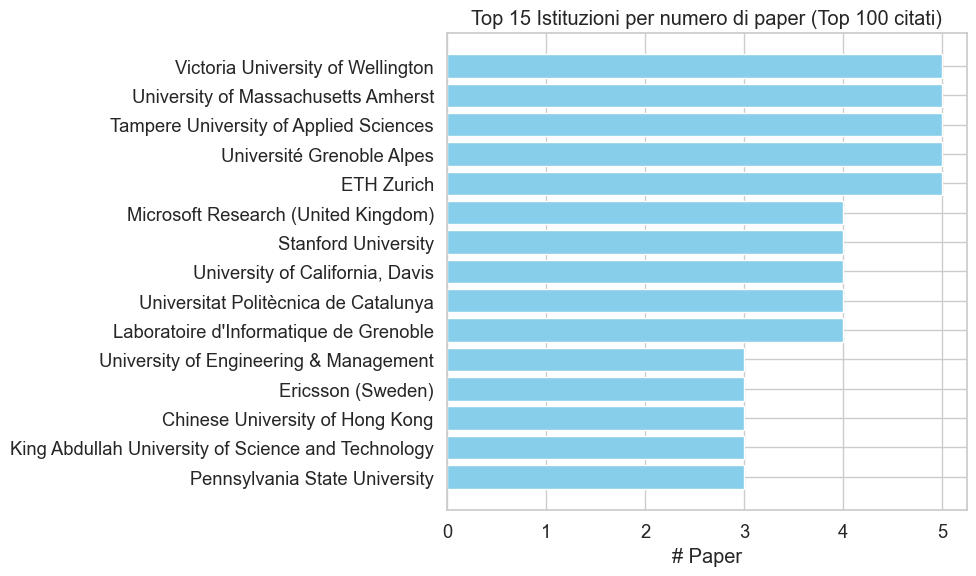

In [25]:
import pandas as pd
import requests
from collections import Counter
import time
import os
import matplotlib.pyplot as plt
from rich.console import Console
from rich.table import Table
from rich import box

# === Flag: vuoi davvero eseguire le query OpenAlex? ===
ESEGUI_QUERY = False  # ⬅️ Cambia a True solo se vuoi fare le chiamate API

# === 1. Carica MAG_ID dal file ===
df = pd.read_csv("top_100_mag_ids.csv")
mag_ids = df["MAG_ID"].tolist()
risultato_path = "openalex_istituti.csv"

if ESEGUI_QUERY:
    institution_counter = Counter()

    for i, mag_id in enumerate(mag_ids, 1):
        openalex_id = f"W{mag_id}"
        url = f"https://api.openalex.org/works/{openalex_id}"

        print(f"[{i}/{len(mag_ids)}] 🔍 Recupero dati per MAG_ID: {mag_id}...")

        try:
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()
                authorships = data.get("authorships", [])
                for auth in authorships:
                    for inst in auth.get("institutions", []):
                        name = inst.get("display_name")
                        if name:
                            institution_counter[name] += 1
            else:
                print(f"⚠️  Errore {response.status_code} per MAG_ID {mag_id}")
        except Exception as e:
            print(f"❌ Errore durante la richiesta: {e}")

        time.sleep(1.2)

    # === Salva i risultati ===
    df_out = pd.DataFrame(institution_counter.items(), columns=["Istituto", "Paper"])
    df_out.to_csv(risultato_path, index=False)
    print(f"\n✅ Risultati salvati in {risultato_path}")

# === 2. Visualizzazione dei risultati ===
if os.path.exists(risultato_path):
    df_risultati = pd.read_csv(risultato_path)

    # Rich Table
    console = Console()
    table = Table(title="🏛️ Top Istituti nei Top 100 paper", box=box.ROUNDED)
    table.add_column("Istituto", style="cyan")
    table.add_column("# Paper", justify="right", style="magenta")

    for _, row in df_risultati.sort_values("Paper", ascending=False).head(15).iterrows():
        table.add_row(row["Istituto"], str(row["Paper"]))

    console.print(table)

    # Barplot
    top15 = df_risultati.sort_values("Paper", ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(top15["Istituto"], top15["Paper"], color="skyblue")
    plt.title("Top 15 Istituzioni per numero di paper (Top 100 citati)")
    plt.xlabel("# Paper")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Nessun file di risultati trovato. Esegui con `ESEGUI_QUERY = True` per crearne uno.")


La **classificazione dei nodi** è un compito fondamentale nell'analisi dei grafi: dato un nodo e le sue connessioni nel grafo, l'obiettivo è predire a quale classe appartiene. Questo è particolarmente utile in contesti come reti di citazioni, reti sociali o sistemi di raccomandazione.

Nel nostro caso, classifichiamo articoli accademici presenti nel dataset **ogbn-arxiv** in base al campo di ricerca (es. Machine Learning, Visione Artificiale, ecc.).

### 🔧 Modello: GraphSAGE
Utilizziamo il modello **GraphSAGE** (*Graph Sample and Aggregate*), una GNN che costruisce rappresentazioni dei nodi combinando le feature dei vicini in modo efficiente. Qui usiamo una semplice architettura a due layer con attivazione `ReLU` intermedia.

### 🚀 Training e valutazione
La pipeline prevede:
1. **Caricamento del dataset** e divisione in train/val/test.
2. **Definizione del modello** e ottimizzatore.
3. **Resume da checkpoint**, se presente.
4. **Loop di training** con salvataggio del miglior modello basato su accuratezza in validation.
5. **Early stopping** per evitare overfitting.
6. **Estrazione degli embedding finali** da salvare su disco.

Il training è monitorato con un log CSV e stampa progressiva delle metriche a ogni epoca.


In [26]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Definizione modello ===
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_sage_model.pt"
checkpoint_path = "checkpoint_sage.pth"
log_path = "training_log.csv"

model = GraphSAGE(data.num_features, 128, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# === 3. Resume da checkpoint se disponibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")
    if os.path.exists(log_path):
        os.remove(log_path)  # reset log se nuovo training

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training con Early Stopping e Resume ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    train_acc, val_acc, test_acc = evaluate()

    # === Log visivo
    print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    # === Logging CSV
    with open(log_path, "a") as f:
        f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

    # === Model Saving
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), model_path)
        print("💾 Nuovo best model salvato")
    else:
        patience_counter += 1
        print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

    # === Salvataggio checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_acc': best_val_acc,
        'patience_counter': patience_counter
    }, checkpoint_path)

    if patience_counter >= early_stop_patience:
        print("🛑 Early stopping attivato!")
        break

# === 6. Salva embedding dal miglior modello ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "sage_node_embeddings.pt")
print("✅ Embedding salvati in 'sage_node_embeddings.pt'")


🔁 Resume training da epoch 322, best val acc: 0.6946
[Epoch 322] Loss: 0.9700 | Train: 0.7061 | Val: 0.6941 | Test: 0.6844
⏳ Early stopping counter: 11/10
🛑 Early stopping attivato!
✅ Embedding salvati in 'sage_node_embeddings.pt'


     📊 Riepilogo Completo Training GraphSAGE      
                                                   
  Epoch     Loss   Train Acc   Val Acc   Test Acc  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
      1   3.6761      0.1100    0.2297     0.2156  
      2   3.4230      0.1108    0.2302     0.2157  
      3   3.1740      0.1478    0.2416     0.2228  
      4   3.0435      0.2246    0.1774     0.1584  
      5   3.0188      0.1791    0.0763     0.0586  
      6   3.0045      0.1792    0.0765     0.0587  
      7   2.9320      0.1955    0.1096     0.0876  
      8   2.8569      0.2726    0.2855     0.2595  
      9   2.8057      0.2939    0.3070     0.2752  
     10   2.7602      0.2967    0.3083     0.2756  
     11   2.7075      0.2980    0.3093     0.2762  
     12   2.6466      0.2994    0.3105     0.2783  
     13   2.5817      0.3021    0.3125     0.2805  
     14   2.5178      0.3120    0.3234     0.2936  
     15   2.4571      0.3344    0.3527     0.3298  
     16   2.3996      0.3622    0.3892     0.3802  
     17   2.3450      0.3856    0.4149     0.4097  
     18   2.2923      0.4045    0.4294     0.4201  
     19   2.2392      0.4183    0.4341     0.4207  
     20   2.1863      0.4263    0.4350     0.4207  
     21   2.1361      0.4333    0.4414     0.4288  
     22   2.0898      0.4418    0.4567     0.4470  
     23   2.0462      0.4542    0.4771     0.4716  
     24   2.0045      0.4665    0.4952     0.4919  
     25   1.9653      0.4764    0.5068     0.5042  
     26   1.9289      0.4825    0.5114     0.5091  
     27   1.8946      0.4875    0.5143     0.5120  
     28   1.8618      0.4921    0.5174     0.5156  
     29   1.8308      0.4968    0.5217     0.5191  
     30   1.8017      0.5017    0.5250     0.5235  
     31   1.7744      0.5065    0.5293     0.5265  
     32   1.7486      0.5123    0.5338     0.5301  
     33   1.7238      0.5197    0.5411     0.5366  
     34   1.7006      0.5266    0.5498     0.5463  
     35   1.6788      0.5337    0.5567     0.5553  
     36   1.6572      0.5380    0.5608     0.5585  
     37   1.6359      0.5426    0.5632     0.5585  
     38   1.6164      0.5466    0.5650     0.5596  
     39   1.5984      0.5523    0.5713     0.5656  
     40   1.5806      0.5582    0.5764     0.5742  
     41   1.5631      0.5630    0.5815     0.5803  
     42   1.5464      0.5669    0.5848     0.5814  
     43   1.5309      0.5707    0.5861     0.5813  
     44   1.5161      0.5741    0.5889     0.5833  
     45   1.5017      0.5775    0.5922     0.5865  
     46   1.4878      0.5807    0.5953     0.5898  
     47   1.4747      0.5840    0.5987     0.5925  
     48   1.4621      0.5867    0.6013     0.5951  
     49   1.4498      0.5891    0.6036     0.5986  
     50   1.4384      0.5916    0.6065     0.6012  
     51   1.4277      0.5938    0.6084     0.6016  
     52   1.4169      0.5961    0.6091     0.6018  
     53   1.4067      0.5981    0.6102     0.6035  
     54   1.3974      0.5996    0.6125     0.6055  
     55   1.3883      0.6017    0.6149     0.6068  
     56   1.3795      0.6039    0.6163     0.6087  
     57   1.3711      0.6065    0.6180     0.6113  
     58   1.3632      0.6080    0.6193     0.6138  
     59   1.3556      0.6093    0.6204     0.6144  
     60   1.3483      0.6104    0.6212     0.6149  
     61   1.3413      0.6118    0.6232     0.6155  
     62   1.3346      0.6135    0.6249     0.6169  
     63   1.3281      0.6151    0.6259     0.6192  
     64   1.3219      0.6166    0.6274     0.6200  
     65   1.3159      0.6176    0.6282     0.6217  
     66   1.3101      0.6185    0.6288     0.6234  
     67   1.3046      0.6201    0.6300     0.6244  
     68   1.2992      0.6217    0.6314     0.6258  
     69   1.2939      0.6229    0.6328     0.6272  
     70   1.2889      0.6240    0.6337     0.6280  
     71   1.2840      0.6249    0.6346     0.6288  
     72   1.2793      0.6259    0.6350     0.6298  
     73   1.2747      0.6273    0.6360     0.6309

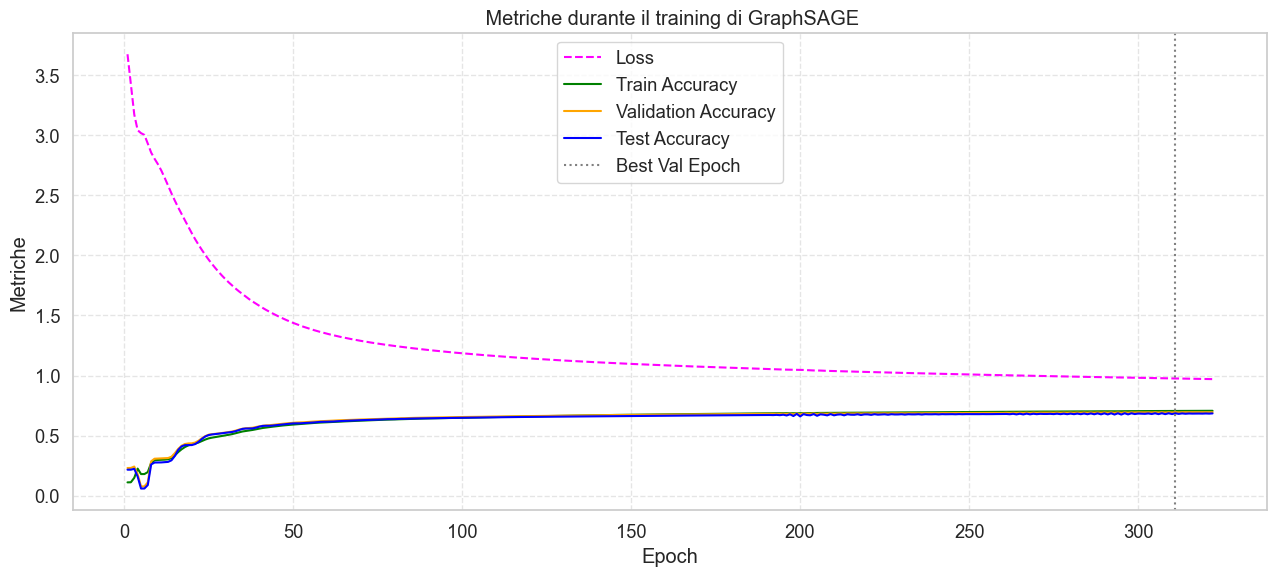

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from rich.console import Console
from rich.table import Table
from rich import box

# === 1. Carica il file di log del training ===
log_path = "training_log.csv"
df_log = pd.read_csv(log_path, names=["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"])

# === 2. Visualizzazione tabellare di tutte le epoche con Rich ===
console = Console()
table = Table(title="📊 Riepilogo Completo Training GraphSAGE", box=box.SIMPLE_HEAVY)
table.add_column("Epoch", justify="right", style="cyan")
table.add_column("Loss", justify="right", style="magenta")
table.add_column("Train Acc", justify="right", style="green")
table.add_column("Val Acc", justify="right", style="yellow")
table.add_column("Test Acc", justify="right", style="blue")

best_row = df_log["Val Acc"].idxmax()

for i, row in df_log.iterrows():
    style = "bold white" if i == best_row else ""
    table.add_row(
        str(int(row["Epoch"])),
        f"{row['Loss']:.4f}",
        f"{row['Train Acc']:.4f}",
        f"{row['Val Acc']:.4f}",
        f"{row['Test Acc']:.4f}",
        style=style
    )

console.print(table)

# === 3. Plot delle metriche nel tempo ===
plt.figure(figsize=(13, 6))
plt.plot(df_log["Epoch"], df_log["Loss"], label="Loss", color="magenta", linestyle="--")
plt.plot(df_log["Epoch"], df_log["Train Acc"], label="Train Accuracy", color="green")
plt.plot(df_log["Epoch"], df_log["Val Acc"], label="Validation Accuracy", color="orange")
plt.plot(df_log["Epoch"], df_log["Test Acc"], label="Test Accuracy", color="blue")
plt.axvline(df_log.loc[best_row, "Epoch"], color="gray", linestyle=":", label="Best Val Epoch")

plt.xlabel("Epoch")
plt.ylabel("Metriche")
plt.title(" Metriche durante il training di GraphSAGE")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Classificazione con GCN (Graph Convolutional Network)

In questa sezione addestriamo un modello **GCN**, una delle architetture più classiche per la classificazione su grafi. A differenza di GraphSAGE, il GCN effettua una convoluzione che combina direttamente i vicini in una forma normalizzata, ed è particolarmente efficace quando la struttura del grafo è ben formata e completa.

###  Preparazione
- Carichiamo nuovamente il dataset `ogbn-arxiv` e verifichiamo che le feature dei nodi siano esattamente **128**, come richiesto dal checkpoint eventualmente disponibile.
- Dividiamo il dataset in train/val/test e spostiamo tutto su `cuda` se disponibile.

###  Architettura GCN
- Il modello implementato ha **2 layer di convoluzione** `GCNConv` con attivazione ReLU tra i due.
- Le dimensioni nascoste sono impostate a 128, coerentemente con la configurazione del GraphSAGE per un confronto equo.

###  Training con Early Stopping
- Viene adottato un meccanismo di **early stopping** con pazienza di 10 epoche.
- Il training può riprendere automaticamente da un **checkpoint** compatibile (basato sul numero di feature in input).
- A ogni epoca viene registrata la loss e l’accuratezza su train, validation e test, salvando il **miglior modello**.

###  Estrazione degli embedding
Alla fine dell’addestramento, estraiamo gli **embedding** dei nodi dal GCN allena


In [28]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Forza le 128 feature originali ===
EXPECTED_INPUT_DIM = 128
if data.x.shape[1] > EXPECTED_INPUT_DIM:
    print(f"✂️ Taglio feature extra: da {data.x.shape[1]} → {EXPECTED_INPUT_DIM}")
    data.x = data.x[:, :EXPECTED_INPUT_DIM]
elif data.x.shape[1] < EXPECTED_INPUT_DIM:
    raise ValueError(f"❌ data.x ha solo {data.x.shape[1]} feature, ne servono esattamente 128!")

# === 3. Modello GCN ===
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# === 4. Paths ===
model_path = "best_gcn_model.pt"
checkpoint_path = "checkpoint_gcn.pth"
log_path = "training_log_gcn.csv"

# === 5. Instanzia modello e ottimizzatore ===
model = GCN(EXPECTED_INPUT_DIM, 128, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# === 6. Resume da checkpoint se compatibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        ckpt_in_dim = checkpoint['model_state_dict']['conv1.lin.weight'].shape[1]
        if ckpt_in_dim == EXPECTED_INPUT_DIM:
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_val_acc = checkpoint['best_val_acc']
            patience_counter = checkpoint['patience_counter']
            print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
        else:
            print(f"⚠️ Checkpoint incompatibile: input dim = {ckpt_in_dim}, expected = {EXPECTED_INPUT_DIM}")
            print("🆕 Partenza da zero...")
    except Exception as e:
        print(f"❌ Errore nel caricamento checkpoint: {e}")
        print("🆕 Partenza da zero...")
else:
    print("🆕 Inizio nuovo training...")

# === 7. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 8. Training con Early Stopping ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()

    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 9. Embedding finali ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()
torch.save(embeddings, "gcn_node_embeddings.pt")
print("✅ Embedding salvati in 'gcn_node_embeddings.pt'")


🔁 Resume training da epoch 191, best val acc: 0.6782
[Epoch 200] Loss: 1.0996 | Train: 0.6792 | Val: 0.6804 | Test: 0.6694
💾 Nuovo best model salvato
[Epoch 210] Loss: 1.0913 | Train: 0.6814 | Val: 0.6825 | Test: 0.6710
💾 Nuovo best model salvato
[Epoch 220] Loss: 1.0837 | Train: 0.6835 | Val: 0.6839 | Test: 0.6725
💾 Nuovo best model salvato
[Epoch 230] Loss: 1.0767 | Train: 0.6846 | Val: 0.6851 | Test: 0.6741
💾 Nuovo best model salvato
[Epoch 240] Loss: 1.0703 | Train: 0.6860 | Val: 0.6868 | Test: 0.6750
💾 Nuovo best model salvato
[Epoch 250] Loss: 1.0643 | Train: 0.6879 | Val: 0.6877 | Test: 0.6765
💾 Nuovo best model salvato
[Epoch 260] Loss: 1.0587 | Train: 0.6897 | Val: 0.6883 | Test: 0.6777
💾 Nuovo best model salvato
[Epoch 270] Loss: 1.0535 | Train: 0.6910 | Val: 0.6893 | Test: 0.6788
💾 Nuovo best model salvato
[Epoch 280] Loss: 1.0486 | Train: 0.6923 | Val: 0.6901 | Test: 0.6813
💾 Nuovo best model salvato
[Epoch 290] Loss: 1.0440 | Train: 0.6929 | Val: 0.6903 | Test: 0.6786
💾 Nu

   📊 Riepilogo Training GCN (ultime 10 epoche)    
                                                   
  Epoch     Loss   Train Acc   Val Acc   Test Acc  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
    200   1.0996      0.6792    0.6804     0.6694  
    210   1.0913      0.6814    0.6825     0.6710  
    220   1.0837      0.6835    0.6839     0.6725  
    230   1.0767      0.6846    0.6851     0.6741  
    240   1.0703      0.6860    0.6868     0.6750  
    250   1.0643      0.6879    0.6877     0.6765  
    260   1.0587      0.6897    0.6883     0.6777  
    270   1.0535      0.6910    0.6893     0.6788  
    280   1.0486      0.6923    0.6901     0.6813  
    290   1.0440      0.6929    0.6903     0.6786 


📈 Media ultimi 10: Val Acc = 0.6864 | Test Acc = 0.6755


C:\Users\paolo\AppData\Local\Temp\ipykernel_7324\678983252.py:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\paolo\AppData\Local\Temp\ipykernel_7324\678983252.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig("gcn_training_plot.png")
C:\Users\paolo\DM2\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


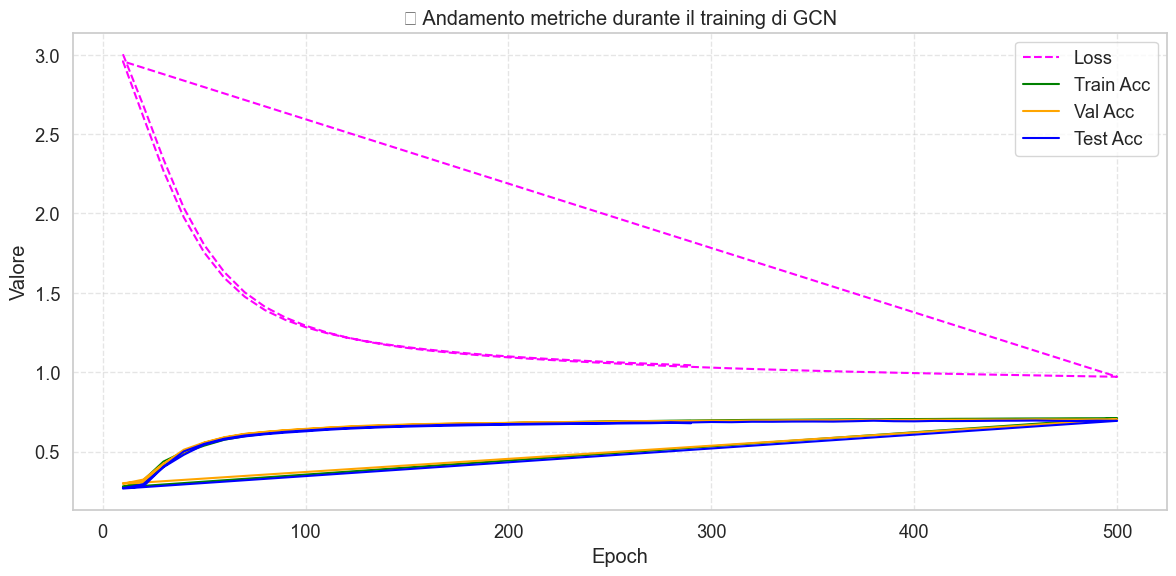

✅ Grafico salvato in 'gcn_training_plot.png'


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from rich.console import Console
from rich.table import Table
from rich import box
import os

# === 1. Carica il file di log del training (GCN) ===
log_path = "training_log_gcn.csv"
if not os.path.exists(log_path):
    raise FileNotFoundError(f"❌ Il file '{log_path}' non esiste. Assicurati che il training sia stato completato.")

# Se il CSV non ha header
df_log = pd.read_csv(log_path, names=["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"])

# Converte le colonne in numeriche, rimuovendo eventuali stringhe problematiche
df_log[["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"]] = df_log[["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"]].apply(pd.to_numeric, errors="coerce")
df_log = df_log.dropna()

# === 2. Visualizzazione tabellare con Rich (ultimi 10 step) ===
console = Console()
table = Table(title="📊 Riepilogo Training GCN (ultime 10 epoche)", box=box.SIMPLE_HEAVY)
table.add_column("Epoch", justify="right", style="cyan")
table.add_column("Loss", justify="right", style="magenta")
table.add_column("Train Acc", justify="right", style="green")
table.add_column("Val Acc", justify="right", style="yellow")
table.add_column("Test Acc", justify="right", style="blue")

for _, row in df_log.tail(10).iterrows():
    table.add_row(
        str(int(row["Epoch"])),
        f"{row['Loss']:.4f}",
        f"{row['Train Acc']:.4f}",
        f"{row['Val Acc']:.4f}",
        f"{row['Test Acc']:.4f}",
    )

console.print(table)

# === 3. Stampa statistiche finali
val_mean = df_log["Val Acc"].tail(10).mean()
test_mean = df_log["Test Acc"].tail(10).mean()
print(f"\n📈 Media ultimi 10: Val Acc = {val_mean:.4f} | Test Acc = {test_mean:.4f}")

# === 4. Plot delle metriche nel tempo
plt.figure(figsize=(12, 6))
plt.plot(df_log["Epoch"], df_log["Loss"], label="Loss", color="magenta", linestyle="--")
plt.plot(df_log["Epoch"], df_log["Train Acc"], label="Train Acc", color="green")
plt.plot(df_log["Epoch"], df_log["Val Acc"], label="Val Acc", color="orange")
plt.plot(df_log["Epoch"], df_log["Test Acc"], label="Test Acc", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Valore")
plt.title("📊 Andamento metriche durante il training di GCN")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gcn_training_plot.png")
plt.show()

print("✅ Grafico salvato in 'gcn_training_plot.png'")



In questa sezione addestriamo un modello **GAT**, una variante delle GNN che introduce un meccanismo di **attenzione** tra i nodi. A differenza di GCN o GraphSAGE, GAT assegna un peso diverso a ciascun vicino durante l’aggregazione, migliorando la capacità del modello di focalizzarsi sui nodi più rilevanti.

###  Vantaggi dell'attenzione
- Ogni nodo **pesa dinamicamente** i suoi vicini in base al contenuto delle feature.
- Migliora le performance in grafi eterogenei o rumorosi.
- Consente una maggiore **espressività** rispetto ai metodi basati su media o somma.

###  Configurazione
- Architettura con **2 layer GATConv**: il primo con 8 teste di attenzione, il secondo con 1.
- Applichiamo **dropout 0.6** prima di ogni layer per regolarizzazione.
- Ottimizzazione con `Adam` e **weight decay**.

###  Training
- Implementiamo resume da checkpoint, early stopping e logging CSV.
- Ogni 10 epoche valutiamo accuratezza su training, validation e test.
- Alla fine salviamo gli **embedding dei nodi** prodotti dal GAT, che potranno essere utilizzati per classificazione tradizionale o visualizzazione.

> Il modello GAT è particolarmente adatto in contesti dove la rilevanza dei vicini non è omogenea, come nelle reti sociali o nei grafi citazionali ad alta densità.


In [30]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Definizione modello GAT ===
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_gat_model.pt"
checkpoint_path = "checkpoint_gat.pth"
log_path = "training_log_gat.csv"
model = GAT(data.num_features, 8, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

# === 3. Resume da checkpoint se disponibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training con Early Stopping e Resume ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 6. Salva embedding dal miglior modello ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "gat_node_embeddings.pt")
print("✅ Embedding salvati in 'gat_node_embeddings.pt'")


🔁 Resume training da epoch 501, best val acc: 0.6406
[Epoch 510] Loss: 1.8665 | Train: 0.6221 | Val: 0.6388 | Test: 0.6338
⏳ Early stopping counter: 1/10
[Epoch 520] Loss: 1.8609 | Train: 0.6211 | Val: 0.6394 | Test: 0.6351
⏳ Early stopping counter: 2/10
[Epoch 530] Loss: 1.8646 | Train: 0.6212 | Val: 0.6389 | Test: 0.6347
⏳ Early stopping counter: 3/10
[Epoch 540] Loss: 1.8636 | Train: 0.6230 | Val: 0.6389 | Test: 0.6331
⏳ Early stopping counter: 4/10
[Epoch 550] Loss: 1.8655 | Train: 0.6225 | Val: 0.6394 | Test: 0.6326
⏳ Early stopping counter: 5/10
[Epoch 560] Loss: 1.8629 | Train: 0.6229 | Val: 0.6399 | Test: 0.6358
⏳ Early stopping counter: 6/10
[Epoch 570] Loss: 1.8667 | Train: 0.6214 | Val: 0.6396 | Test: 0.6384
⏳ Early stopping counter: 7/10
[Epoch 580] Loss: 1.8671 | Train: 0.6223 | Val: 0.6388 | Test: 0.6343
⏳ Early stopping counter: 8/10
[Epoch 590] Loss: 1.8626 | Train: 0.6221 | Val: 0.6390 | Test: 0.6331
⏳ Early stopping counter: 9/10
[Epoch 600] Loss: 1.8698 | Train: 0.62

     Riepilogo Training GAT (ultime 10 epoche)     
                                                   
  Epoch     Loss   Train Acc   Val Acc   Test Acc  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
    510   1.8665      0.6221    0.6388     0.6338  
    520   1.8609      0.6211    0.6394     0.6351  
    530   1.8646      0.6212    0.6389     0.6347  
    540   1.8636      0.6230    0.6389     0.6331  
    550   1.8655      0.6225    0.6394     0.6326  
    560   1.8629      0.6229    0.6399     0.6358  
    570   1.8667      0.6214    0.6396     0.6384  
    580   1.8671      0.6223    0.6388     0.6343  
    590   1.8626      0.6221    0.6390     0.6331  
    600   1.8698      0.6212    0.6392     0.6361 

C:\Users\paolo\AppData\Local\Temp\ipykernel_7324\1877363592.py:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\paolo\DM2\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


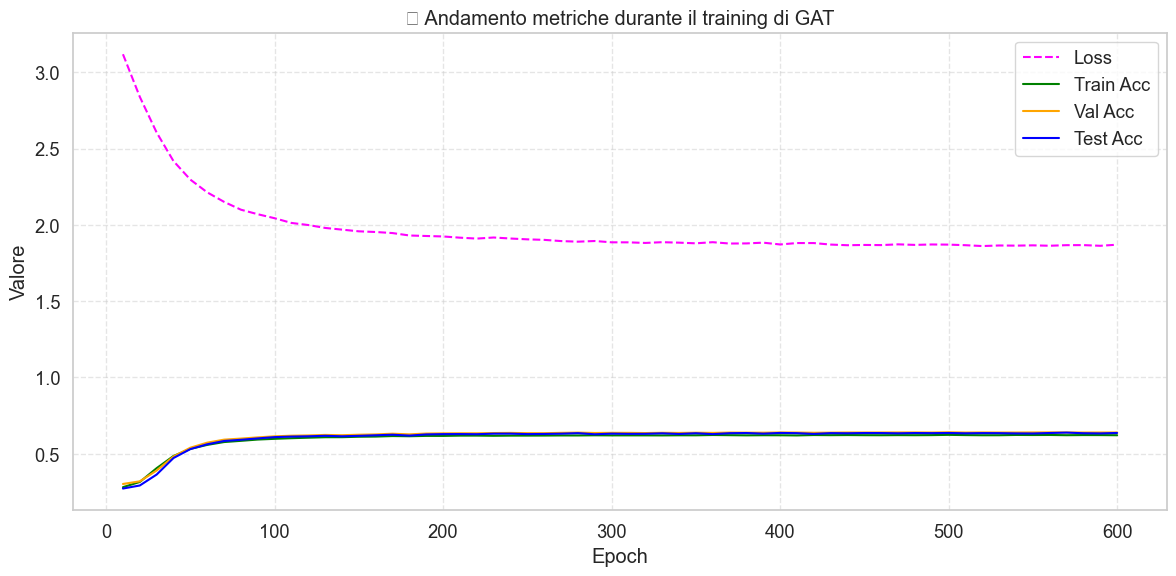

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from rich.console import Console
from rich.table import Table
from rich import box
import os

# === 1. Carica il file di log del training (GAT) ===
log_path = "training_log_gat.csv"
if not os.path.exists(log_path):
    raise FileNotFoundError(f"❌ Il file '{log_path}' non esiste.")

# Leggi il file CSV e forza la conversione in numerico, ignorando righe non valide
df_log = pd.read_csv(log_path, names=["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"])
df_log[["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"]] = df_log[["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"]].apply(pd.to_numeric, errors="coerce")
df_log = df_log.dropna()

# === 2. Visualizzazione tabellare con Rich (ultimi 10 step) ===
console = Console()
table = Table(title=" Riepilogo Training GAT (ultime 10 epoche)", box=box.SIMPLE_HEAVY)
table.add_column("Epoch", justify="right", style="cyan")
table.add_column("Loss", justify="right", style="magenta")
table.add_column("Train Acc", justify="right", style="green")
table.add_column("Val Acc", justify="right", style="yellow")
table.add_column("Test Acc", justify="right", style="blue")

for _, row in df_log.tail(10).iterrows():
    table.add_row(
        str(int(row["Epoch"])),
        f"{row['Loss']:.4f}",
        f"{row['Train Acc']:.4f}",
        f"{row['Val Acc']:.4f}",
        f"{row['Test Acc']:.4f}",
    )

console.print(table)

# === 3. Plot delle metriche nel tempo ===
plt.figure(figsize=(12, 6))
plt.plot(df_log["Epoch"], df_log["Loss"], label="Loss", color="magenta", linestyle="--")
plt.plot(df_log["Epoch"], df_log["Train Acc"], label="Train Acc", color="green")
plt.plot(df_log["Epoch"], df_log["Val Acc"], label="Val Acc", color="orange")
plt.plot(df_log["Epoch"], df_log["Test Acc"], label="Test Acc", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Valore")
plt.title("📈 Andamento metriche durante il training di GAT")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Classificazione con GATv2 (versione leggera)

In questa sezione esploriamo l'utilizzo del modello **GATv2**, un'evoluzione del classico Graph Attention Network (GAT), che migliora la flessibilità dell'attenzione. A differenza di GAT, GATv2 consente di **calcolare i pesi di attenzione direttamente sulle feature non trasformate**, rendendolo più espressivo soprattutto in scenari con variazioni strutturali.

###  GATv2 "light": architettura compatta
Per ridurre il costo computazionale rispetto a GAT standard:
- Usiamo **solo 2 teste di attenzione** nel primo layer e **una sola testa** nel secondo.
- Abbassiamo il numero di **neuroni nascosti a 64**, mantenendo performance stabili.
- Applichiamo `dropout=0.4` su input e layer intermedi per evitare overfitting.

###  Addestramento
Il training segue la stessa logica dei modelli precedenti:
- Resume automatico da checkpoint.
- Early stopping con pazienza di 10 epoche.
- Log in CSV e salvataggio del miglior modello su base validation accuracy.

###  Output: embedding dei nodi
Al termine dell'allenamento, estraiamo e salviamo gli **embedding prodotti dal GATv2**, che saranno utilizzati nelle successive fasi di metric learning o classificazione tradizionale.

> L'obiettivo di questo setup è confrontare l’efficacia del meccanismo di attenzione avanzato di GATv2 rispetto a GAT standard, mantenendo un profilo computazionale più leggero.


In [32]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Definizione modello GATv2 leggero ===
class LightGATv2(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=2, dropout=0.4)
        self.conv2 = GATv2Conv(hidden_channels * 2, out_channels, heads=1, concat=False, dropout=0.4)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_gatv2_model.pt"
checkpoint_path = "checkpoint_gatv2.pth"
log_path = "training_log_gatv2.csv"
model = LightGATv2(data.num_features, 64, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

# === 3. Resume da checkpoint se disponibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training con Early Stopping e Resume ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 6. Salva embedding dal miglior modello ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "gatv2_node_embeddings.pt")
print("✅ Embedding salvati in 'gatv2_node_embeddings.pt'")


🔁 Resume training da epoch 201, best val acc: 0.6644
[Epoch 210] Loss: 1.4678 | Train: 0.6607 | Val: 0.6646 | Test: 0.6618
💾 Nuovo best model salvato
[Epoch 220] Loss: 1.4666 | Train: 0.6617 | Val: 0.6645 | Test: 0.6623
⏳ Early stopping counter: 1/10
[Epoch 230] Loss: 1.4664 | Train: 0.6618 | Val: 0.6636 | Test: 0.6582
⏳ Early stopping counter: 2/10
[Epoch 240] Loss: 1.4618 | Train: 0.6627 | Val: 0.6648 | Test: 0.6597
💾 Nuovo best model salvato
[Epoch 250] Loss: 1.4542 | Train: 0.6625 | Val: 0.6661 | Test: 0.6647
💾 Nuovo best model salvato
[Epoch 260] Loss: 1.4604 | Train: 0.6638 | Val: 0.6661 | Test: 0.6627
💾 Nuovo best model salvato
[Epoch 270] Loss: 1.4497 | Train: 0.6640 | Val: 0.6653 | Test: 0.6587
⏳ Early stopping counter: 1/10
[Epoch 280] Loss: 1.4561 | Train: 0.6644 | Val: 0.6675 | Test: 0.6647
💾 Nuovo best model salvato
[Epoch 290] Loss: 1.4475 | Train: 0.6642 | Val: 0.6675 | Test: 0.6642
⏳ Early stopping counter: 1/10
[Epoch 300] Loss: 1.4534 | Train: 0.6646 | Val: 0.6680 | T

  📊 Riepilogo Training GATv2 (ultime 10 epoche)   
                                                   
  Epoch     Loss   Train Acc   Val Acc   Test Acc  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
    210   1.4678      0.6607    0.6646     0.6618  
    220   1.4666      0.6617    0.6645     0.6623  
    230   1.4664      0.6618    0.6636     0.6582  
    240   1.4618      0.6627    0.6648     0.6597  
    250   1.4542      0.6625    0.6661     0.6647  
    260   1.4604      0.6638    0.6661     0.6627  
    270   1.4497      0.6640    0.6653     0.6587  
    280   1.4561      0.6644    0.6675     0.6647  
    290   1.4475      0.6642    0.6675     0.6642  
    300   1.4534      0.6646    0.6680     0.6630 

C:\Users\paolo\AppData\Local\Temp\ipykernel_7324\4179465499.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\paolo\DM2\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


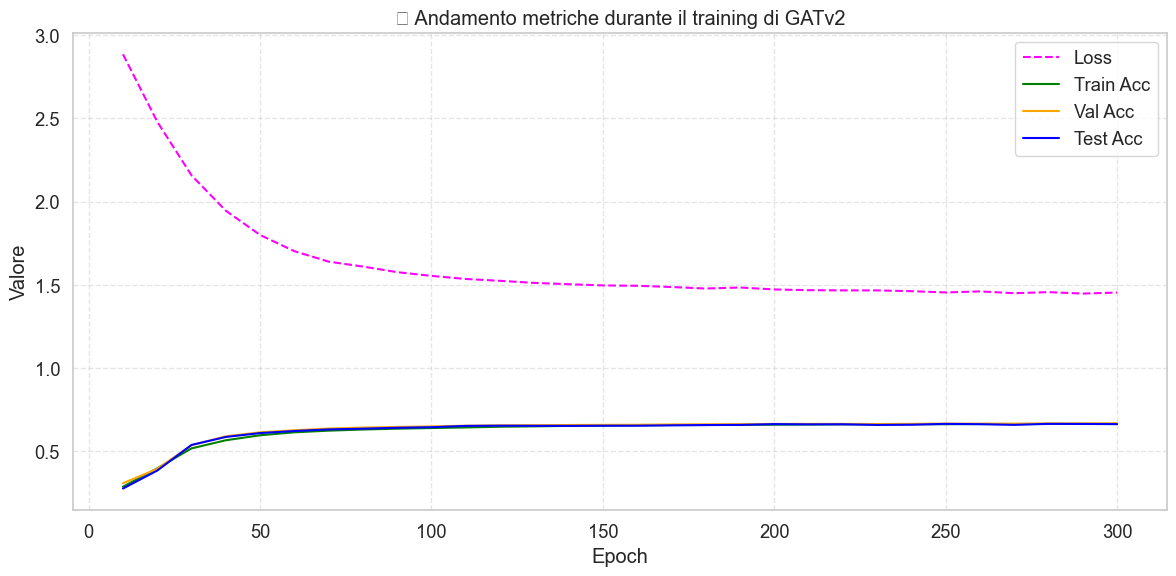

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from rich.console import Console
from rich.table import Table
from rich import box
import os

# === 1. Carica il file di log ===
log_path = "training_log_gatv2.csv"
if not os.path.exists(log_path):
    raise FileNotFoundError(f"❌ Il file '{log_path}' non esiste.")

df_log = pd.read_csv(log_path, names=["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"])

# 🔧 Conversione sicura in numerico
df_log[["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"]] = df_log[
    ["Epoch", "Loss", "Train Acc", "Val Acc", "Test Acc"]
].apply(pd.to_numeric, errors="coerce")

# Rimuove le righe con valori non numerici (NaN)
df_log = df_log.dropna()

# === 2. Visualizzazione tabellare con Rich (ultime 10 epoche) ===
console = Console()
table = Table(title="📊 Riepilogo Training GATv2 (ultime 10 epoche)", box=box.SIMPLE_HEAVY)
table.add_column("Epoch", justify="right", style="cyan")
table.add_column("Loss", justify="right", style="magenta")
table.add_column("Train Acc", justify="right", style="green")
table.add_column("Val Acc", justify="right", style="yellow")
table.add_column("Test Acc", justify="right", style="blue")

for _, row in df_log.tail(10).iterrows():
    table.add_row(
        str(int(row["Epoch"])),
        f"{row['Loss']:.4f}",
        f"{row['Train Acc']:.4f}",
        f"{row['Val Acc']:.4f}",
        f"{row['Test Acc']:.4f}",
    )

console.print(table)

# === 3. Plot delle metriche nel tempo ===
plt.figure(figsize=(12, 6))
plt.plot(df_log["Epoch"], df_log["Loss"], label="Loss", color="magenta", linestyle="--")
plt.plot(df_log["Epoch"], df_log["Train Acc"], label="Train Acc", color="green")
plt.plot(df_log["Epoch"], df_log["Val Acc"], label="Val Acc", color="orange")
plt.plot(df_log["Epoch"], df_log["Test Acc"], label="Test Acc", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Valore")
plt.title("📈 Andamento metriche durante il training di GATv2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Classificazione tradizionale su embedding GNN

Dopo aver addestrato diverse GNN (GCN, GraphSAGE, GAT, GATv2), utilizziamo gli **embedding prodotti dai modelli** per eseguire una classificazione supervisionata con metodi standard.

###  Obiettivo
Valutare quanto siano informativi gli embedding estratti dalle reti neurali su grafo, confrontando le loro performance **in input a un classificatore Logistic Regression**. Questo approccio è utile per:
- Separare la fase di **estrazione di feature** (GNN) da quella di **classificazione**.
- Usare modelli **più interpretabili** o più efficienti nella fase predittiva.

###  Procedura
1. Carichiamo gli embedding salvati dai modelli GNN.
2. Standardizziamo le feature con `StandardScaler`.
3. Alleniamo una **Logistic Regression multinomiale** su `train`, valutando su `val` e `test`.
4. Confrontiamo l’accuratezza ottenuta dai vari embedding.

> Sebbene in questo esempio usiamo **Logistic Regression**, in seguito analizzeremo anche altri classificatori (es. MLP, k-NN) per un confronto più ampio.

Alla fine, riportiamo i risultati in una tabella riepilogativa con validation e test accuracy per ciascun embedding.


In [39]:
import torch
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from sklearn.preprocessing import StandardScaler

# === 1. Carica dataset ogbn-arxiv per etichette e split ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze().numpy()

# === 2. Funzione per valutare logistic regression su un embedding ===
def evaluate_embedding(embedding_path, name):
    print(f"\n🔍 Valutazione Logistic Regression su: {name}")

    # Carica embedding
    emb = torch.load(embedding_path).numpy()

    # Standardizza le feature
    emb = StandardScaler().fit_transform(emb)

    # Estrai gli indici per train/val/test
    train_idx = split_idx['train'].numpy()
    val_idx = split_idx['valid'].numpy()
    test_idx = split_idx['test'].numpy()

    # Prepara Logistic Regression
    clf = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
    clf.fit(emb[train_idx], labels[train_idx])

    # Valutazione
    val_acc = accuracy_score(labels[val_idx], clf.predict(emb[val_idx]))
    test_acc = accuracy_score(labels[test_idx], clf.predict(emb[test_idx]))

    print(f"📈 Val Accuracy:  {val_acc:.4f}")
    print(f"🧪 Test Accuracy: {test_acc:.4f}")
    return name, val_acc, test_acc

# === 3. Lista embedding da confrontare ===
embedding_files = {
    "GraphSAGE": "sage_node_embeddings.pt",
    "GCN": "gcn_node_embeddings.pt",
    "GAT": "gat_node_embeddings.pt",
    "GATv2": "gatv2_node_embeddings.pt"
}

# === 4. Esegui valutazioni
results = []
for name, path in embedding_files.items():
    results.append(evaluate_embedding(path, name))

# === 5. Tabella finale
df_results = pd.DataFrame(results, columns=["Model", "Val Acc", "Test Acc"])
print("\n📊 Confronto Logistic Regression sui vari embedding:")
print(df_results.to_string(index=False))



🔍 Valutazione Logistic Regression su: GraphSAGE


C:\Users\paolo\DM2\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


📈 Val Accuracy:  0.6942
🧪 Test Accuracy: 0.6839

🔍 Valutazione Logistic Regression su: GCN


C:\Users\paolo\DM2\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


📈 Val Accuracy:  0.6965
🧪 Test Accuracy: 0.6840

🔍 Valutazione Logistic Regression su: GAT


C:\Users\paolo\DM2\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


📈 Val Accuracy:  0.6725
🧪 Test Accuracy: 0.6638

🔍 Valutazione Logistic Regression su: GATv2


C:\Users\paolo\DM2\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


📈 Val Accuracy:  0.6894
🧪 Test Accuracy: 0.6799

📊 Confronto Logistic Regression sui vari embedding:
    Model  Val Acc  Test Acc
GraphSAGE 0.694184  0.683950
      GCN 0.696533  0.683970
      GAT 0.672472  0.663848
    GATv2 0.689386  0.679917


## Classificazione con Random Forest su embedding GNN

Oltre alla Logistic Regression, esploriamo l'efficacia di un classificatore **non lineare**: la **Random Forest**. Questo tipo di modello è robusto, interpretabile e adatto a gestire **feature complesse e non scalate perfettamente**, come quelle generate dalle GNN.

### 🌲 Perché Random Forest?
- Non richiede ipotesi lineari sui dati.
- Gestisce bene feature ad alta dimensionalità e interazioni complesse.
- È poco sensibile al rumore e offre una buona generalizzazione.

### 🧪 Dettagli dell'esperimento
- Usiamo gli **embedding generati da GCN, GraphSAGE, GAT e GATv2**.
- Alleniamo una Random Forest con un numero contenuto di alberi (`n_estimators=10`) per limitare l’uso di memoria.
- Per evitare overload di RAM, campioniamo una frazione (`50%`) dei set di validazione e test.
- Calcoliamo l’**accuratezza** su entrambi i set.

> Questo approccio permette di testare la qualità degli embedding in un contesto non lineare, fornendo un'altra prospettiva oltre ai modelli lineari come la Logistic Regression.

Alla fine riportiamo una tabella comparativa delle performance.


In [40]:
import torch
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from sklearn.model_selection import train_test_split

# === 1. Carica dataset e indici ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze().numpy()

train_idx = split_idx["train"].numpy()
val_idx = split_idx["valid"].numpy()
test_idx = split_idx["test"].numpy()

# === 2. Funzione di valutazione con Random Forest ===
def eval_random_forest(embedding_path, model_name, sample_frac=0.5, n_estimators=10):
    print(f"\n🌲 Valutazione Random Forest su: {model_name}")
    emb = torch.load(embedding_path).numpy()

    # Opzionale: riduciamo il set per non esplodere la RAM
    val_sample = int(len(val_idx) * sample_frac)
    test_sample = int(len(test_idx) * sample_frac)

    clf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=-1, random_state=42)
    clf.fit(emb[train_idx], labels[train_idx])

    val_acc = accuracy_score(labels[val_idx[:val_sample]], clf.predict(emb[val_idx[:val_sample]]))
    test_acc = accuracy_score(labels[test_idx[:test_sample]], clf.predict(emb[test_idx[:test_sample]]))

    print(f"🟡 Val Accuracy: {val_acc:.4f}")
    print(f"🟢 Test Accuracy: {test_acc:.4f}")
    return model_name, val_acc, test_acc

# === 3. Valutazione su tutti gli embedding ===
results = []
results.append(eval_random_forest("sage_node_embeddings.pt", "GraphSAGE"))
results.append(eval_random_forest("gcn_node_embeddings.pt", "GCN"))
results.append(eval_random_forest("gat_node_embeddings.pt", "GAT"))
results.append(eval_random_forest("gatv2_node_embeddings.pt", "GATv2"))

# === 4. Confronto finale ===
print("\n📊 Confronto Random Forest sui vari embedding:")
df = pd.DataFrame(results, columns=["Model", "Val Acc", "Test Acc"])
print(df.to_string(index=False))



🌲 Valutazione Random Forest su: GraphSAGE
🟡 Val Accuracy: 0.6656
🟢 Test Accuracy: 0.6513

🌲 Valutazione Random Forest su: GCN
🟡 Val Accuracy: 0.6711
🟢 Test Accuracy: 0.6540

🌲 Valutazione Random Forest su: GAT
🟡 Val Accuracy: 0.6699
🟢 Test Accuracy: 0.6492

🌲 Valutazione Random Forest su: GATv2
🟡 Val Accuracy: 0.6738
🟢 Test Accuracy: 0.6568

📊 Confronto Random Forest sui vari embedding:
    Model  Val Acc  Test Acc
GraphSAGE 0.665615  0.651290
      GCN 0.671119  0.654047
      GAT 0.669911  0.649191
    GATv2 0.673804  0.656763


## Classificazione con k-NN su embedding GNN

Per completare il confronto tra metodi di classificazione tradizionali, valutiamo le performance del **k-Nearest Neighbors (k-NN)**, un approccio semplice ma efficace che si basa sulla **prossimità tra punti nello spazio degli embedding**.

### Perché k-NN?
- Si affida unicamente alla **distanza** tra i vettori: ideale per testare se gli embedding separano bene le classi.
- Non ha una fase di training vera e propria: la classificazione avviene al momento della predizione.
- È un buon indicatore della **struttura geometrica** appresa dal modello.

### Esperimento
- Testiamo k-NN con diversi valori di `k` (da 3 a 7).
- Utilizziamo gli embedding ottenuti da GraphSAGE, GCN, GAT e GATv2.
- Valutiamo l’**accuracy su validation e test** set.
- Riportiamo i risultati in forma tabellare, per confrontare rapidamente l’effetto di `k` su ogni tipo di embedding.

> Un buon embedding dovrebbe garantire performance elevate anche con modelli semplici come k-NN, confermando che le classi sono ben separate nello spazio latente.


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import torch
from ogb.nodeproppred import PygNodePropPredDataset
import pandas as pd

# === 1. Setup: carica dataset e label ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
split_idx = dataset.get_idx_split()
y = dataset[0].y.squeeze()

train_idx = split_idx["train"].numpy()
val_idx = split_idx["valid"].numpy()
test_idx = split_idx["test"].numpy()

# === 2. Carica gli embedding salvati ===
embeddings = {
    "GraphSAGE": torch.load("sage_node_embeddings.pt").numpy(),
    "GCN": torch.load("gcn_node_embeddings.pt").numpy(),
    "GAT": torch.load("gat_node_embeddings.pt").numpy(),
    "GATv2": torch.load("gatv2_node_embeddings.pt").numpy(),
}

# === 3. Valutazione dinamica su diversi n_neighbors ===
results = []
neighbors_range = range(3, 8)

for name, emb in embeddings.items():
    for k in neighbors_range:
        knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
        knn.fit(emb[train_idx], y[train_idx])

        val_acc = accuracy_score(y[val_idx], knn.predict(emb[val_idx]))
        test_acc = accuracy_score(y[test_idx], knn.predict(emb[test_idx]))

        print(f"🔍 {name} | k={k} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
        results.append((name, k, val_acc, test_acc))

# === 4. Tabella riassuntiva ===
df = pd.DataFrame(results, columns=["Model", "k", "Val Acc", "Test Acc"])
print("\n📊 Riepilogo risultati KNN su tutti gli embedding:")
print(df.pivot(index="k", columns="Model", values="Test Acc").round(4)) 


🔍 GraphSAGE | k=3 | Val Acc: 0.6743 | Test Acc: 0.6500
🔍 GraphSAGE | k=4 | Val Acc: 0.6821 | Test Acc: 0.6592
🔍 GraphSAGE | k=5 | Val Acc: 0.6887 | Test Acc: 0.6674
🔍 GraphSAGE | k=6 | Val Acc: 0.6889 | Test Acc: 0.6707
🔍 GraphSAGE | k=7 | Val Acc: 0.6909 | Test Acc: 0.6745
🔍 GCN | k=3 | Val Acc: 0.6596 | Test Acc: 0.6369
🔍 GCN | k=4 | Val Acc: 0.6706 | Test Acc: 0.6497
🔍 GCN | k=5 | Val Acc: 0.6772 | Test Acc: 0.6585
🔍 GCN | k=6 | Val Acc: 0.6818 | Test Acc: 0.6632
🔍 GCN | k=7 | Val Acc: 0.6822 | Test Acc: 0.6676
🔍 GAT | k=3 | Val Acc: 0.6512 | Test Acc: 0.6372
🔍 GAT | k=4 | Val Acc: 0.6630 | Test Acc: 0.6481
🔍 GAT | k=5 | Val Acc: 0.6713 | Test Acc: 0.6576
🔍 GAT | k=6 | Val Acc: 0.6748 | Test Acc: 0.6620
🔍 GAT | k=7 | Val Acc: 0.6781 | Test Acc: 0.6644
🔍 GATv2 | k=3 | Val Acc: 0.6698 | Test Acc: 0.6494
🔍 GATv2 | k=4 | Val Acc: 0.6796 | Test Acc: 0.6589
🔍 GATv2 | k=5 | Val Acc: 0.6855 | Test Acc: 0.6660
🔍 GATv2 | k=6 | Val Acc: 0.6893 | Test Acc: 0.6713
🔍 GATv2 | k=7 | Val Acc: 0.6902

🔍 Valutazione Linear SVM su: GraphSAGE
📘 Val Accuracy: 0.6817
📗 Test Accuracy: 0.6701
🔍 Valutazione Linear SVM su: GCN
📘 Val Accuracy: 0.6809
📗 Test Accuracy: 0.6623
🔍 Valutazione Linear SVM su: GAT
📘 Val Accuracy: 0.6696
📗 Test Accuracy: 0.6587
🔍 Valutazione Linear SVM su: GATv2
📘 Val Accuracy: 0.6856
📗 Test Accuracy: 0.6754


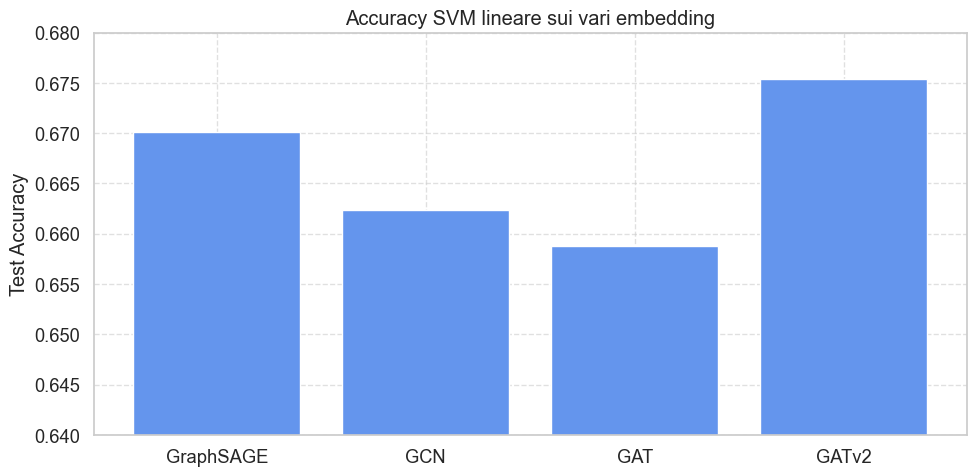

In [42]:
import torch
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica tutti gli embedding salvati ===
embeddings = {
    "GraphSAGE": torch.load("sage_node_embeddings.pt"),
    "GCN": torch.load("gcn_node_embeddings.pt"),
    "GAT": torch.load("gat_node_embeddings.pt"),
    "GATv2": torch.load("gatv2_node_embeddings.pt"),
}

# === 2. Carica indici e label ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze().numpy()

train_idx = split_idx['train'].numpy()
val_idx = split_idx['valid'].numpy()
test_idx = split_idx['test'].numpy()

# === 3. Funzione di valutazione SVM (LinearSVC per efficienza) ===
def eval_linear_svm(name, emb):
    print(f"🔍 Valutazione Linear SVM su: {name}")
    X = emb.numpy()
    clf = LinearSVC(max_iter=5000)
    clf.fit(X[train_idx], labels[train_idx])

    val_acc = accuracy_score(labels[val_idx], clf.predict(X[val_idx]))
    test_acc = accuracy_score(labels[test_idx], clf.predict(X[test_idx]))

    print(f"📘 Val Accuracy: {val_acc:.4f}")
    print(f"📗 Test Accuracy: {test_acc:.4f}")
    return val_acc, test_acc

# === 4. Esegui SVM su tutti gli embedding ===
results = []
for name, emb in embeddings.items():
    val_acc, test_acc = eval_linear_svm(name, emb)
    results.append((name, val_acc, test_acc))

# === 5. Salva e mostra tabella finale ===
df = pd.DataFrame(results, columns=["Model", "Val Acc", "Test Acc"])
df.to_csv("svm_linear_results.csv", index=False)

import matplotlib.pyplot as plt

# === Salva il CSV ===
df.to_csv("svm_linear_results.csv", index=False)

# === Plot ===
plt.figure(figsize=(10, 5))
plt.bar(df["Model"], df["Test Acc"], color="cornflowerblue")
plt.title("Accuracy SVM lineare sui vari embedding")
plt.ylabel("Test Accuracy")
plt.ylim(0.64, 0.68)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



## Analisi della Largest Connected Component (LCC)

I grafi reali, come quello del dataset `ogbn-arxiv`, possono essere **sparsi** e contenere **componenti disconnesse**. Per molte tecniche (es. Metric Learning, visualizzazione, clustering), è preferibile lavorare sulla **Largest Connected Component (LCC)**, ovvero il sottografo connesso più grande, che rappresenta la parte più strutturata e informativa del grafo.

###  In questa sezione:
- Convertiamo il grafo in una rappresentazione `networkx` per analizzare la connettività.
- Estraiamo la LCC e costruiamo un nuovo oggetto `Data` PyTorch Geometric filtrato solo su questa componente.
- Visualizziamo statistiche chiave:
  - Numero totale di nodi nel grafo originale.
  - Numero di nodi e archi nella LCC.

> Isolare la LCC aiuta a garantire che i metodi successivi (es. triplet mining o GNN locali) lavorino su un sottografo **ben connesso** e rappresentativo.


In [43]:
import torch
import pandas as pd
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data
import networkx as nx
from rich.console import Console
from rich.table import Table
from rich import box

console = Console()

def filter_data_by_mask(data, mask):
    node_idx = mask.nonzero(as_tuple=False).view(-1)
    mapping = {old_idx.item(): new_idx for new_idx, old_idx in enumerate(node_idx)}

    x = data.x[node_idx]
    y = data.y[node_idx]

    edge_mask = mask[data.edge_index[0]] & mask[data.edge_index[1]]
    edge_index = data.edge_index[:, edge_mask]
    edge_index = torch.stack([
        torch.tensor([mapping[idx.item()] for idx in edge_index[0]]),
        torch.tensor([mapping[idx.item()] for idx in edge_index[1]])
    ])

    return Data(x=x, edge_index=edge_index, y=y)

def main():
    console.rule("[bold blue]🔍 Analisi Largest Connected Component")

    dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
    data = dataset[0]

    console.print(f"📦 Numero totale di nodi: [bold]{data.num_nodes}[/bold]")
    G = to_networkx(data, to_undirected=True)

    console.print("🔄 Calcolo componenti connesse...")
    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)

    largest_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    largest_mask[list(largest_component)] = True

    filtered_data = filter_data_by_mask(data, largest_mask)

    # Tabella riassuntiva con Rich
    table = Table(title="📊 Largest Connected Component", box=box.SIMPLE)
    table.add_column("Statistica", style="cyan", justify="right")
    table.add_column("Valore", style="bold")

    table.add_row("Numero totale nodi", str(data.num_nodes))
    table.add_row("Nodi nella componente", str(filtered_data.num_nodes))
    table.add_row("Archi nella componente", str(filtered_data.edge_index.size(1)))

    console.print(table)

if __name__ == "__main__":
    main()


───────────────────────────────────── 🔍 Analisi Largest Connected Component ──────────────────────────────────────

📦 Numero totale di nodi: 169343

🔄 Calcolo componenti connesse...

   📊 Largest Connected Component   
                                    
              Statistica   Valore   
 ────────────────────────────────── 
      Numero totale nodi   169343   
   Nodi nella componente   169343   
  Archi nella componente   2315598 

## Analisi dei nodi centrali tramite PageRank

Dopo aver isolato la **Largest Connected Component** (LCC) del grafo `ogbn-arxiv`, ci concentriamo sull’analisi della **centralità dei nodi** utilizzando l’algoritmo **PageRank**, introdotto da Google per valutare l'importanza delle pagine web, ma ampiamente usato in ambito grafi.

###  Obiettivo
Identificare i nodi più centrali (e potenzialmente più influenti) nella struttura del grafo:
- Un nodo con alto PageRank è fortemente connesso a **nodi a loro volta influenti**.
- Può rappresentare un paper particolarmente citato o autorevole nel grafo delle citazioni scientifiche.

###  Procedura
1. Convertiamo il grafo in un oggetto `networkx`.
2. Estraiamo la **componente connessa più grande**.
3. Calcoliamo il **PageRank** su questo sottografo.
4. Visualizziamo i **top 10 nodi** con i punteggi più alti in una tabella ordinata.
5. Riportiamo statistiche generali sul grafo filtrato (nodi e archi).

> L’analisi della centralità sarà utile nelle fasi successive di **Metric Learning** per selezionare nodi di riferimento (anchor) significativi.


In [44]:
import torch
import pandas as pd
import networkx as nx
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import box

from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx

# === Setup Rich ===
console = Console()

# === 1. Carica dataset ===
console.print("📦 [bold]Caricamento del dataset ogbn-arxiv...[/bold]")
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]

# === 2. Conversione a grafo undirected ===
console.print("🔁 [bold]Conversione in grafo NetworkX (undirected)...[/bold]")
G = to_networkx(data, to_undirected=True)

# === 3. Estrazione della largest weakly connected component ===
console.print("📊 [bold]Calcolo largest connected component...[/bold]")
components = list(nx.connected_components(G))
largest_component = max(components, key=len)
G_sub = G.subgraph(largest_component).copy()

# === 4. Calcolo del PageRank ===
console.print("🧠 [bold]Calcolo del PageRank...[/bold] (può richiedere qualche secondo)")
pagerank_scores = nx.pagerank(G_sub)

# === 5. Top 10 nodi con PageRank più alto ===
top_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

# === 6. Visualizzazione con Rich ===
console.print("\n✨ [bold magenta]Top 10 nodi per PageRank nella largest connected component[/bold magenta]")

table = Table(title="📈 Top 10 PageRank", box=box.SIMPLE_HEAVY)
table.add_column("Rank", justify="right", style="cyan")
table.add_column("Node ID", justify="right", style="green")
table.add_column("PageRank Score", justify="right", style="yellow")

for i, (node_id, score) in enumerate(top_nodes, start=1):
    table.add_row(str(i), str(node_id), f"{score:.6e}")

console.print(table)

# === 7. Statistiche generali ===
console.print(
    Panel.fit(
        f"[bold]Nodi totali nella componente:[/bold] {len(G_sub)}\n"
        f"[bold]Archi totali nella componente:[/bold] {G_sub.number_of_edges()}",
        title="📌 [i]Largest Component Info[/i]",
        border_style="bright_blue"
    )
)


📦 Caricamento del dataset ogbn-arxiv...

🔁 Conversione in grafo NetworkX (undirected)...

📊 Calcolo largest connected component...

🧠 Calcolo del PageRank... (può richiedere qualche secondo)

✨ Top 10 nodi per PageRank nella largest connected component

        📈 Top 10 PageRank         
                                   
  Rank   Node ID   PageRank Score  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
     1      1353     3.240089e-03  
     2     67166     2.589161e-03  
     3     25208     1.973960e-03  
     4    106699     1.133126e-03  
     5     69794     1.035317e-03  
     6    115359     8.767053e-04  
     7     93649     8.614382e-04  
     8     94874     8.405713e-04  
     9     22035     8.277438e-04  
    10    133376     7.222428e-04 

╭────── 📌 Largest Component Info ───────╮
│ Nodi totali nella componente: 169343   │
│ Archi totali nella componente: 1157799 │
╰────────────────────────────────────────╯

📚 Calcolo PageRank...
🔗 Aggiunta feature PageRank al tensor x


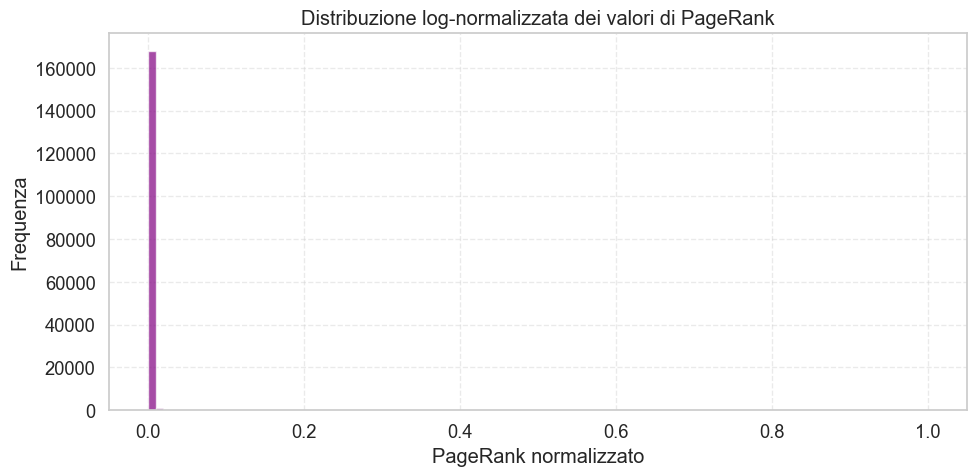

✅ Dataset con PageRank salvato come 'ogbn_arxiv_with_pagerank.pt'


In [45]:
import torch
import numpy as np
import networkx as nx
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# === 1. Carica il dataset ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
G = to_networkx(data, to_undirected=True)

# === 2. Calcolo PageRank su tutto il grafo ===
print("📚 Calcolo PageRank...")
pagerank_dict = nx.pagerank(G, alpha=0.85)
pagerank_values = np.array([pagerank_dict[i] for i in range(data.num_nodes)])

# === 3. Log-transform + normalizzazione ===
pagerank_values_log = np.log1p(pagerank_values)  # log(1 + x)
scaler = MinMaxScaler()
pagerank_norm_log = scaler.fit_transform(pagerank_values_log.reshape(-1, 1))
pagerank_tensor = torch.tensor(pagerank_norm_log, dtype=torch.float32)

# === 4. Aggiunta del PageRank normalizzato come feature extra ===
print("🔗 Aggiunta feature PageRank al tensor x")
data.x = torch.cat([data.x, pagerank_tensor], dim=1)

# === 5. Istogramma distribuzione (post-log) ===
plt.figure(figsize=(10, 5))
plt.hist(pagerank_norm_log, bins=100, color="purple", alpha=0.7)
plt.title("Distribuzione log-normalizzata dei valori di PageRank")
plt.xlabel("PageRank normalizzato")
plt.ylabel("Frequenza")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# === 6. Salva il dataset modificato ===
torch.save(data, "ogbn_arxiv_with_pagerank.pt")
print("✅ Dataset con PageRank salvato come 'ogbn_arxiv_with_pagerank.pt'")


In [46]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx
import networkx as nx

# === 1. Carica dataset e grafo ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
G = to_networkx(data, to_undirected=True)

# === 2. Trova largest connected component ===
components = list(nx.connected_components(G))
largest_component = max(components, key=len)
G_lcc = G.subgraph(largest_component).copy()

# === 3. Calcola PageRank ===
pagerank_dict = nx.pagerank(G_lcc, alpha=0.85)

# === 4. Normalizza PageRank con MinMaxScaler ===
node_ids = list(pagerank_dict.keys())
pagerank_values = np.array(list(pagerank_dict.values())).reshape(-1, 1)
scaler = MinMaxScaler()
pagerank_norm = scaler.fit_transform(pagerank_values)

# === 5. Aggiungi PageRank normalizzato come nuova feature ===
# Default: 0 per nodi fuori dalla largest connected component
pagerank_feature = torch.zeros(data.num_nodes, 1)
for idx, node_id in enumerate(node_ids):
    pagerank_feature[node_id] = torch.tensor(pagerank_norm[idx])

# === 6. Concatena al feature tensor originale ===
data.x = torch.cat([data.x, pagerank_feature], dim=1)
print(f"✅ Nuova dimensione delle feature: {data.x.size()}")


✅ Nuova dimensione delle feature: torch.Size([169343, 129])


Qua addestriamo gcn con pagerank come feature aggiuntiva

In [47]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Carica dataset modificato con PageRank ===
data = torch.load("ogbn_arxiv_with_pagerank.pt")
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Modello aggiornato GCN con input +1 feature ===
class GCNWithPageRank(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_gcn_pagerank.pt"
checkpoint_path = "checkpoint_gcn_pagerank.pth"
log_path = "training_log_gcn_pagerank.csv"
model = GCNWithPageRank(data.num_features, 128, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# === 3. Resume training se esiste checkpoint ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training loop con Early Stopping e log ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 6. Salva embedding finali ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "gcn_pagerank_node_embeddings.pt")
print("✅ Embedding salvati in 'gcn_pagerank_node_embeddings.pt'")



🔁 Resume training da epoch 301, best val acc: 0.6947
[Epoch 310] Loss: 1.0260 | Train: 0.6983 | Val: 0.6948 | Test: 0.6829
💾 Nuovo best model salvato
[Epoch 320] Loss: 1.0217 | Train: 0.6991 | Val: 0.6961 | Test: 0.6846
💾 Nuovo best model salvato
[Epoch 330] Loss: 1.0176 | Train: 0.7000 | Val: 0.6969 | Test: 0.6857
💾 Nuovo best model salvato
[Epoch 340] Loss: 1.0138 | Train: 0.7008 | Val: 0.6971 | Test: 0.6860
💾 Nuovo best model salvato
[Epoch 350] Loss: 1.0102 | Train: 0.7016 | Val: 0.6978 | Test: 0.6869
💾 Nuovo best model salvato
[Epoch 360] Loss: 1.0068 | Train: 0.7023 | Val: 0.6976 | Test: 0.6870
⏳ Early stopping counter: 1/10
[Epoch 370] Loss: 1.0035 | Train: 0.7032 | Val: 0.6984 | Test: 0.6885
💾 Nuovo best model salvato
[Epoch 380] Loss: 1.0004 | Train: 0.7037 | Val: 0.6988 | Test: 0.6882
💾 Nuovo best model salvato
[Epoch 390] Loss: 0.9975 | Train: 0.7045 | Val: 0.6992 | Test: 0.6884
💾 Nuovo best model salvato
[Epoch 400] Loss: 0.9946 | Train: 0.7053 | Val: 0.7007 | Test: 0.6902


In [48]:
import torch
import pandas as pd
import networkx as nx
from rich.console import Console
from rich.table import Table
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx

# === 1. Caricamento del dataset ===
console = Console()
console.print("📦 [bold]Caricamento del dataset ogbn-arxiv...[/bold]")
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]

# === 2. Conversione in grafo NetworkX ===
console.print("🔁 [bold]Conversione in grafo NetworkX (undirected)...[/bold]")
G = to_networkx(data, to_undirected=True)

# === 3. Calcolo delle feature strutturali ===
console.print("🧠 [bold]Calcolo delle feature strutturali (Degree, Clustering)...[/bold]")
degree_dict = dict(G.degree())
clustering_dict = nx.clustering(G)

# === 4. Costruzione del DataFrame ===
node_ids = list(degree_dict.keys())
df_structural = pd.DataFrame({
    "Node ID": node_ids,
    "Degree": [degree_dict[n] for n in node_ids],
    "ClusteringCoeff": [clustering_dict[n] for n in node_ids],
})

# === 5. Visualizzazione con Rich (primi 20 nodi) ===
console.print("\n📊 [bold magenta]Anteprima delle feature strutturali (primi 20 nodi):[/bold magenta]\n")
table = Table(show_header=True, header_style="bold cyan")
table.add_column("Node ID", justify="right")
table.add_column("Degree", justify="right")
table.add_column("ClusteringCoeff", justify="right")

for _, row in df_structural.head(20).iterrows():
    table.add_row(str(row["Node ID"]), str(row["Degree"]), f"{row['ClusteringCoeff']:.4f}")

console.print(table)


📦 Caricamento del dataset ogbn-arxiv...

🔁 Conversione in grafo NetworkX (undirected)...

🧠 Calcolo delle feature strutturali (Degree, Clustering)...

📊 Anteprima delle feature strutturali (primi 20 nodi):

┏━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Node ID ┃ Degree ┃ ClusteringCoeff ┃
┡━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│     0.0 │  291.0 │          0.0344 │
│     1.0 │    2.0 │          1.0000 │
│     2.0 │   14.0 │          0.2088 │
│     3.0 │    2.0 │          1.0000 │
│     4.0 │    6.0 │          0.8000 │
│     5.0 │    1.0 │          0.0000 │
│     6.0 │    8.0 │          0.0000 │
│     7.0 │    2.0 │          1.0000 │
│     8.0 │    1.0 │          0.0000 │
│     9.0 │    3.0 │          0.6667 │
│    10.0 │    5.0 │          0.2000 │
│    11.0 │    5.0 │          0.6000 │
│    12.0 │    7.0 │          0.4762 │
│    13.0 │    5.0 │          0.4000 │
│    14.0 │    7.0 │          0.0952 │
│    15.0 │   11.0 │          0.2909 │
│    16.0 │    5.0 │          0.3000 │
│    17.0 │   21.0 │          0.0476 │
│    18.0 │    1.0 │          0.0000 │
│    19.0 │    2.0 │          0.0000 │
└─────────┴────────┴─────────────────┘

## Integrazione di Feature Strutturali: Grado e Clustering Coefficiente

Per arricchire la rappresentazione dei nodi, calcoliamo e integriamo **feature strutturali del grafo** che non sono esplicitamente incluse nelle feature originarie. In particolare, aggiungiamo:
- **Grado del nodo**: il numero di archi incidenti.
- **Coefficiente di clustering locale**: misura quanto i vicini di un nodo tendono a formare triangoli (densità locale).

Includere informazioni **topologiche** che aiutino le GNN (o altri modelli) a:
- Distinguere nodi periferici da quelli centrali.
- Sfruttare la **struttura locale** per inferenze più robuste.

1. Convertiamo il grafo in `networkx` per calcolare:
   - Il **grado** tramite `G.degree()`.
   - Il **clustering coefficient** con `nx.clustering()`.
2. Normalizziamo entrambe le feature con **Min-Max Scaling**.
3. Le convertiamo in tensori PyTorch e le **concateniamo** alle feature originali di `data.x`.
4. Salviamo il nuovo oggetto `Data` nel file `ogbn_arxiv_with_structural.pt`.

> Queste feature strutturali verranno poi usate in modelli GNN o Metric Learning, permettendo un confronto con versioni basate solo su feature originali.


In [49]:
import torch
import pandas as pd
import networkx as nx
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx
from sklearn.preprocessing import MinMaxScaler

# === 1. Carica dataset ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]

# === 2. Conversione in grafo NetworkX ===
G = to_networkx(data, to_undirected=True)

# === 3. Calcolo delle feature strutturali ===
degree_dict = dict(G.degree())
clustering_dict = nx.clustering(G)

# === 4. Costruzione DataFrame delle feature ===
node_ids = list(degree_dict.keys())
df_structural = pd.DataFrame({
    "Node ID": node_ids,
    "Degree": [degree_dict[n] for n in node_ids],
    "ClusteringCoeff": [clustering_dict[n] for n in node_ids],
})

# === 5. Normalizzazione (Min-Max) ===
scaler = MinMaxScaler()
df_structural[["Degree", "ClusteringCoeff"]] = scaler.fit_transform(df_structural[["Degree", "ClusteringCoeff"]])

# === 6. Conversione in tensori torch ===
degree_tensor = torch.tensor(df_structural["Degree"].values, dtype=torch.float).view(-1, 1)
clustering_tensor = torch.tensor(df_structural["ClusteringCoeff"].values, dtype=torch.float).view(-1, 1)

# === 7. Concatenazione con data.x ===
data.x = torch.cat([data.x, degree_tensor, clustering_tensor], dim=1)

# === 8. Salva il nuovo oggetto data ===
torch.save(data, "ogbn_arxiv_with_structural.pt") 

# Output per conferma
data.x.shape


torch.Size([169343, 130])

In [50]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Carica dataset con nuove feature ===
data = torch.load("ogbn_arxiv_with_structural.pt")

# === 2. Setup split e evaluator ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv')
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 3. Definizione modello GraphSAGE ===
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_sage_structural.pt"
checkpoint_path = "checkpoint_sage_structural.pth"
log_path = "training_log_sage_structural.csv"
model = GraphSAGE(data.x.size(1), 128, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# === 4. Resume da checkpoint se esiste ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 5. Funzioni training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 6. Training con Early Stopping ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

        # Logging su CSV
        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 7. Salvataggio embedding finale ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "sage_structural_embeddings.pt")
print("✅ Embedding salvati in 'sage_structural_embeddings.pt'")


🔁 Resume training da epoch 301, best val acc: 0.6935
[Epoch 310] Loss: 0.9634 | Train: 0.7060 | Val: 0.6948 | Test: 0.6884
💾 Nuovo best model salvato
[Epoch 320] Loss: 0.9583 | Train: 0.7080 | Val: 0.6924 | Test: 0.6802
⏳ Early stopping counter: 1/10
[Epoch 330] Loss: 0.9538 | Train: 0.7091 | Val: 0.6943 | Test: 0.6818
⏳ Early stopping counter: 2/10
[Epoch 340] Loss: 0.9496 | Train: 0.7101 | Val: 0.6957 | Test: 0.6857
💾 Nuovo best model salvato
[Epoch 350] Loss: 0.9485 | Train: 0.7091 | Val: 0.6977 | Test: 0.6930
💾 Nuovo best model salvato
[Epoch 360] Loss: 0.9415 | Train: 0.7119 | Val: 0.6970 | Test: 0.6875
⏳ Early stopping counter: 1/10
[Epoch 370] Loss: 0.9379 | Train: 0.7127 | Val: 0.6970 | Test: 0.6844
⏳ Early stopping counter: 2/10
[Epoch 380] Loss: 0.9342 | Train: 0.7137 | Val: 0.6963 | Test: 0.6829
⏳ Early stopping counter: 3/10
[Epoch 390] Loss: 0.9304 | Train: 0.7146 | Val: 0.6966 | Test: 0.6844
⏳ Early stopping counter: 4/10
[Epoch 400] Loss: 0.9300 | Train: 0.7135 | Val: 0.

In [51]:
import os
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Percorso immagine ===
img_path = "structural_scatter.png"

# === 2. Se esiste già l'immagine, la mostriamo ===
if os.path.exists(img_path):
    print("🖼️ Scatter plot già generato, lo mostro...")
    Image.open(img_path).show()
else:
    print("🎨 Genero scatter plot e lo salvo...")

    # === 3. Carica dataset con feature strutturali ===
    dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
    data = torch.load("ogbn_arxiv_with_structural.pt")

    # === 4. Estrai le ultime due feature strutturali (degree e clustering) ===
    degree = data.x[:, -2].cpu().numpy()
    clustering = data.x[:, -1].cpu().numpy()
    labels = data.y.squeeze().cpu().numpy()

    # === 5. Costruisci DataFrame per plotting ===
    df = pd.DataFrame({
        "Degree": degree,
        "ClusteringCoeff": clustering,
        "Label": labels
    })

    # === 6. Scatter plot con seaborn ===
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df.sample(5000, random_state=42),  # sample per alleggerire
        x="Degree", y="ClusteringCoeff", hue="Label",
        palette="tab10", s=20, alpha=0.7, linewidth=0
    )
    plt.title("Distribuzione strutturale (Degree vs ClusteringCoeff) colorata per Label")
    plt.xlabel("Degree (normalizzato)")
    plt.ylabel("Clustering Coefficient (normalizzato)")
    plt.legend(title="Classe", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.3)

    # ✅ Salva e mostra
    plt.savefig(img_path, dpi=300)
    plt.show()


🖼️ Scatter plot già generato, lo mostro...


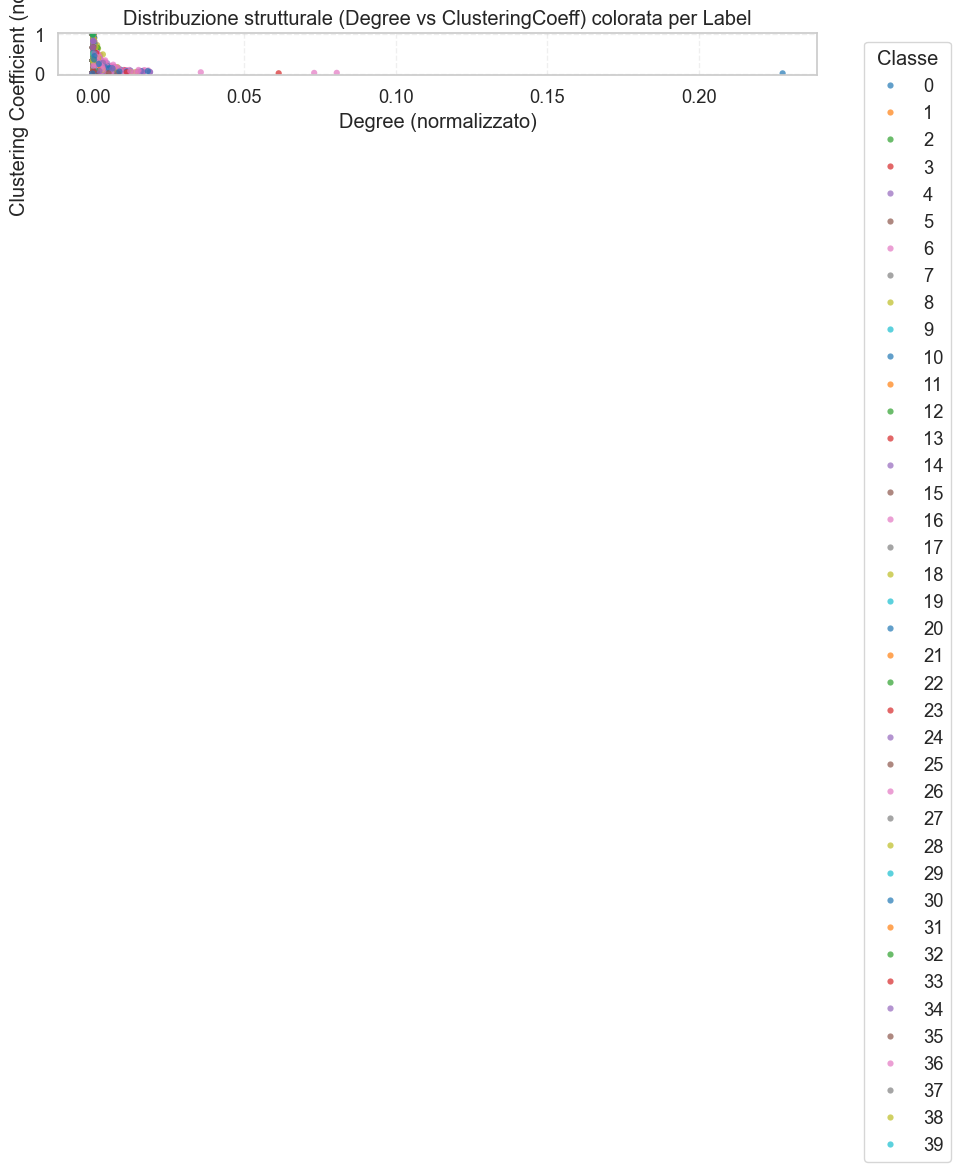

In [52]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica dataset con feature strutturali ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = torch.load("ogbn_arxiv_with_structural.pt")  # <-- usa il file che hai salvato prima

# === 2. Estrai le ultime due feature strutturali (degree e clustering) ===
degree = data.x[:, -2].cpu().numpy()
clustering = data.x[:, -1].cpu().numpy()
labels = data.y.squeeze().cpu().numpy()

# === 3. Costruisci DataFrame per plotting ===
df = pd.DataFrame({
    "Degree": degree,
    "ClusteringCoeff": clustering,
    "Label": labels
})

# === 4. Scatter plot ===
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df.sample(5000, random_state=42),  # sample per alleggerire
    x="Degree", y="ClusteringCoeff", hue="Label", palette="tab10", s=20, alpha=0.7, linewidth=0
)
plt.title("Distribuzione strutturale (Degree vs ClusteringCoeff) colorata per Label")
plt.xlabel("Degree (normalizzato)")
plt.ylabel("Clustering Coefficient (normalizzato)")
plt.legend(title="Classe", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


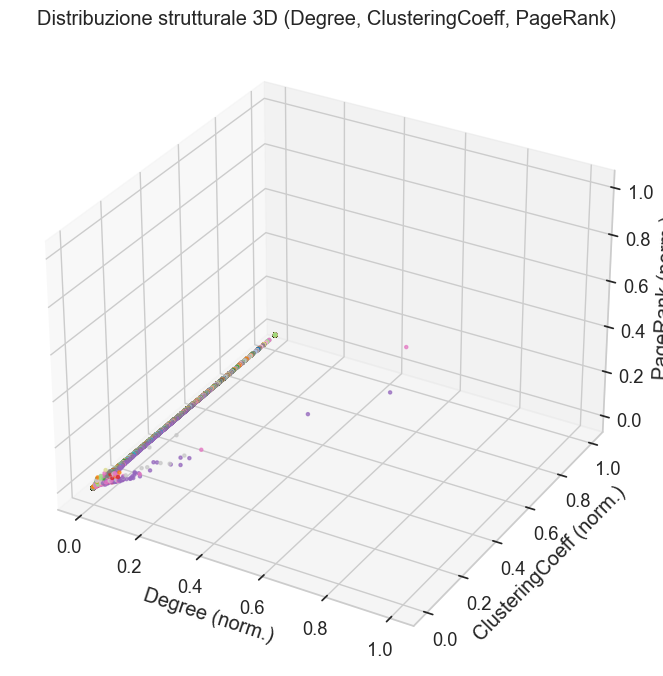

In [53]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import to_networkx
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# === 1. Carica il dataset ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
labels = data.y.squeeze().numpy()

# === 2. Conversione in grafo NetworkX ===
G = to_networkx(data, to_undirected=True)

# === 3. Calcolo delle feature strutturali ===
degree_dict = dict(G.degree())
clustering_dict = nx.clustering(G)
pagerank_dict = nx.pagerank(G, alpha=0.85)

# === 4. DataFrame con tutte le feature ===
node_ids = list(degree_dict.keys())
df_structural = pd.DataFrame({
    "Node ID": node_ids,
    "Degree": [degree_dict[n] for n in node_ids],
    "ClusteringCoeff": [clustering_dict[n] for n in node_ids],
    "PageRank": [pagerank_dict[n] for n in node_ids],
    "Label": [labels[n] for n in node_ids]
})

# === 5. Normalizzazione ===
scaler = MinMaxScaler()
df_structural[["Degree", "ClusteringCoeff", "PageRank"]] = scaler.fit_transform(
    df_structural[["Degree", "ClusteringCoeff", "PageRank"]])

# === 6. Visualizzazione 3D ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_structural["Degree"],
    df_structural["ClusteringCoeff"],
    df_structural["PageRank"],
    c=df_structural["Label"],
    cmap='tab20',
    s=5,
    alpha=0.7
)

ax.set_title("Distribuzione strutturale 3D (Degree, ClusteringCoeff, PageRank)")
ax.set_xlabel("Degree (norm.)")
ax.set_ylabel("ClusteringCoeff (norm.)")
ax.set_zlabel("PageRank (norm.)")

plt.tight_layout()
plt.show()



Per analizzare visivamente la distribuzione dei nodi nello spazio delle feature, applichiamo tecniche di **riduzione dimensionale** su `data.x`, che ora include:
- Le **feature originarie** del dataset ogbn-arxiv.
- Le **feature strutturali**: grado e coefficiente di clustering normalizzati.

- **PCA (Principal Component Analysis)**: riduzione lineare delle dimensioni che preserva la massima varianza.
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: tecnica non lineare che enfatizza la preservazione delle **relazioni locali**.

- Valutare la **separabilità tra classi** visivamente.
- Intuire se le nuove feature strutturali contribuiscono a una maggiore **discriminabilità**.
- Esplorare la **forma dello spazio latente** su cui verranno basate le triplette per il metric learning.



> Un clustering ben visibile (soprattutto con t-SNE) è un buon indicatore che gli embedding contengano informazioni utili per una classificazione o un metric learning efficace.


In [54]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from PIL import Image

# === 1. Carica dataset ===
data_path = "ogbn_arxiv_with_structural.pt"
data = torch.load(data_path)

X = data.x.cpu().numpy()
y = data.y.squeeze().cpu().numpy()

# === 2. Percorsi per salvataggio ===
pca_file = "X_pca_structural.npy"
tsne_file = "X_tsne_structural.npy"
img_file_png = "pca_tsne_structural_features.png"
img_file_pdf = "pca_tsne_structural_features.pdf"

# === 3. PCA ===
if os.path.exists(pca_file):
    print("🔁 PCA già calcolato, carico da file...")
    X_pca = np.load(pca_file)
else:
    print("🔄 Calcolo PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    np.save(pca_file, X_pca)

# === 4. t-SNE ===
if os.path.exists(tsne_file):
    print("🔁 t-SNE già calcolato, carico da file...")
    X_tsne = np.load(tsne_file)
else:
    print("🔄 Calcolo t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    X_tsne = tsne.fit_transform(X)
    np.save(tsne_file, X_tsne)

# === 5. Visualizzazione o caricamento immagini ===
if not os.path.exists(img_file_png):
    print("📊 Genero e salvo i grafici...")

    plt.figure(figsize=(12, 5))

    # --- PCA ---
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab20", s=1)
    plt.title("PCA delle feature (originali + strutturali)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label="Classe")

    # --- t-SNE ---
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab20", s=1)
    plt.title("t-SNE delle feature (originali + strutturali)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(scatter, label="Classe")

    plt.tight_layout()
    plt.savefig(img_file_png, dpi=300)
    plt.savefig(img_file_pdf)
    plt.show()
else:
    print(f"🖼️ Immagine già generata: {img_file_png}")
    Image.open(img_file_png).show()


🔁 PCA già calcolato, carico da file...
🔁 t-SNE già calcolato, carico da file...
🖼️ Immagine già generata: pca_tsne_structural_features.png


## Valutazione della qualità del clustering: Silhouette Score

Per rafforzare l’analisi visiva della distribuzione dei nodi nello spazio delle feature (ottenuto con PCA e t-SNE), calcoliamo un indicatore quantitativo: il **Silhouette Score**.

###  Cos'è il Silhouette Score?
- Misura **quanto bene ogni punto è assegnato alla propria classe** rispetto a quelle vicine.
- Valori vicini a **1.0** indicano una **buona separazione** tra cluster.
- Valori vicini a **0.0** indicano **sovrapposizione** tra le classi.

###  Procedura
- Standardizziamo le feature (incluso grado e clustering coefficient).
- Applichiamo **PCA** e **t-SNE** per ottenere rappresentazioni bidimensionali.
- Campioniamo **5.000 nodi** per rendere il calcolo del silhouette score efficiente.
- Calcoliamo e visualizziamo:
  - Il **Silhouette Score** per PCA.
  - Il **Silhouette Score** per t-SNE.
- Mostriamo entrambi i grafici con il valore corrispondente nel titolo.

###  Obiettivo
- Capire **quanto le classi sono distinguibili** nello spazio proiettato.
- Valutare se le **feature strutturali** migliorano la **discriminabilità** dei nodi.

> Il silhouette score è un criterio utile anche per selezionare le strategie più efficaci di **triplet mining** nel metric learning.


In [55]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica dataset ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = torch.load("ogbn_arxiv_with_structural.pt")

scaler = StandardScaler()
X = scaler.fit_transform(data.x.numpy())
y = data.y.squeeze().numpy()

# === 2. Percorsi file salvati ===
pca_file = "X_pca.npy"
tsne_file = "X_tsne.npy"
fig_file_png = "pca_tsne_silhouette.png"
fig_file_pdf = "pca_tsne_silhouette.pdf"

# === 3. Carica o calcola PCA ===
if os.path.exists(pca_file):
    print("🔁 PCA già calcolato, carico da file...")
    X_pca = np.load(pca_file)
else:
    print("🔄 Calcolo PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    np.save(pca_file, X_pca)

# === 4. Carica o calcola t-SNE ===
if os.path.exists(tsne_file):
    print("🔁 t-SNE già calcolato, carico da file...")
    X_tsne = np.load(tsne_file)
else:
    print("🔄 Calcolo t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X)
    np.save(tsne_file, X_tsne)

# === 5. Calcolo silhouette score su un campione ===
print("⚡ Calcolo silhouette score su 5000 campioni...")
X_pca_sample, y_sample = resample(X_pca, y, n_samples=5000, random_state=42)
X_tsne_sample, _ = resample(X_tsne, y, n_samples=5000, random_state=42)

pca_silhouette = silhouette_score(X_pca_sample, y_sample)
tsne_silhouette = silhouette_score(X_tsne_sample, y_sample)

# === 6. Visualizzazione e salvataggio grafici ===
if not os.path.exists(fig_file_png):
    print("📊 Genero e salvo visualizzazione...")
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab20", s=1)
    plt.title(f"PCA (Silhouette ~ {pca_silhouette:.3f})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label="Classe")

    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab20", s=1)
    plt.title(f"t-SNE (Silhouette ~ {tsne_silhouette:.3f})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(scatter, label="Classe")

    plt.tight_layout()
    plt.savefig(fig_file_png, dpi=300)
    plt.savefig(fig_file_pdf)
    plt.show()
else:
    print(f"🖼️ Immagini già presenti: {fig_file_png}")
    from PIL import Image
    Image.open(fig_file_png).show()

# === 7. Output silhouette
print("\n✅ Silhouette Score (su 5000 nodi campionati):")
print(f"PCA:  {pca_silhouette:.4f}")
print(f"t-SNE:{tsne_silhouette:.4f}")


🔁 PCA già calcolato, carico da file...
🔁 t-SNE già calcolato, carico da file...
⚡ Calcolo silhouette score su 5000 campioni...
🖼️ Immagini già presenti: pca_tsne_silhouette.png

✅ Silhouette Score (su 5000 nodi campionati):
PCA:  -0.2929
t-SNE:-0.2192


In [56]:
import torch
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica gli embedding ===
embeddings = {
    "GraphSAGE": torch.load("sage_node_embeddings.pt"),
    "GCN": torch.load("gcn_node_embeddings.pt"),
    "GAT": torch.load("gat_node_embeddings.pt"),
    "GATv2": torch.load("gatv2_node_embeddings.pt"),
}

# === 2. Carica i dati OGB ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze().numpy()
train_idx = split_idx['train'].numpy()
val_idx = split_idx['valid'].numpy()
test_idx = split_idx['test'].numpy()

# === 3. Funzione di valutazione con XGBoost ===
def eval_xgboost(name, emb):
    print(f"🔍 XGBoost su: {name}")
    X = emb.numpy()
    dtrain = xgb.DMatrix(X[train_idx], label=labels[train_idx])
    dval = xgb.DMatrix(X[val_idx], label=labels[val_idx])
    dtest = xgb.DMatrix(X[test_idx], label=labels[test_idx])

    params = {
        "objective": "multi:softmax",
        "eval_metric": "mlogloss",
        "num_class": len(set(labels)),
        "max_depth": 6,
        "eta": 0.1,
        "verbosity": 0
    }

    model = xgb.train(params, dtrain, num_boost_round=100)
    val_pred = model.predict(dval)
    test_pred = model.predict(dtest)

    val_acc = accuracy_score(labels[val_idx], val_pred)
    test_acc = accuracy_score(labels[test_idx], test_pred)

    print(f"📘 Val Accuracy: {val_acc:.4f}")
    print(f"📗 Test Accuracy: {test_acc:.4f}")
    return val_acc, test_acc

# === 4. Valutazione su tutti gli embedding ===
results = []
for name, emb in embeddings.items():
    val_acc, test_acc = eval_xgboost(name, emb)
    results.append((name, val_acc, test_acc))

# === 5. Tabella finale ===
df = pd.DataFrame(results, columns=["Embedding", "Val Acc", "Test Acc"])
df.to_csv("xgboost_results.csv", index=False)
print("\n📊 Risultati salvati in 'xgboost_results.csv':")
print(df)


🔍 XGBoost su: GraphSAGE
📘 Val Accuracy: 0.6946
📗 Test Accuracy: 0.6857
🔍 XGBoost su: GCN
📘 Val Accuracy: 0.6986
📗 Test Accuracy: 0.6882
🔍 XGBoost su: GAT
📘 Val Accuracy: 0.6836
📗 Test Accuracy: 0.6756
🔍 XGBoost su: GATv2
📘 Val Accuracy: 0.6975
📗 Test Accuracy: 0.6874

📊 Risultati salvati in 'xgboost_results.csv':
   Embedding   Val Acc  Test Acc
0  GraphSAGE  0.694621  0.685678
1        GCN  0.698580  0.688167
2        GAT  0.683614  0.675617
3      GATv2  0.697540  0.687365


In [57]:
import torch
import numpy as np
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
import time
import os

# === Config ===
NUM_PAIRS = 50000
SAVE_PATH = "metric_learning_pairs.pt"

# === 1. Carica embedding e label ===
print("📦 Caricamento embedding e label...")
X = torch.load("gcn_node_embeddings.pt")  
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
labels = dataset[0].y.squeeze()
labels_np = labels.numpy()
num_nodes = X.size(0)

# === 2. Genera coppie positive/negative con logging ===
def generate_pairs(X, labels, num_pairs=50000, log_every=5000):
    x1, x2, y = [], [], []
    class_labels = np.unique(labels)

    start_time = time.time()
    for i in range(num_pairs):
        if i % log_every == 0 and i > 0:
            elapsed = time.time() - start_time
            print(f"🔄 Generato {i}/{num_pairs} coppie in {elapsed:.2f}s")

        # Positive pair
        class_id = np.random.choice(class_labels)
        same_class_idxs = np.where(labels == class_id)[0]
        i1, i2 = np.random.choice(same_class_idxs, 2, replace=False)
        x1.append(X[i1])
        x2.append(X[i2])
        y.append(1)

        # Negative pair
        while True:
            i1 = np.random.randint(num_nodes)
            i2 = np.random.randint(num_nodes)
            if labels[i1] != labels[i2]:
                break
        x1.append(X[i1])
        x2.append(X[i2])
        y.append(0)

    print("✅ Generazione completata.")
    return torch.stack(x1), torch.stack(x2), torch.tensor(y)

print("🚀 Generazione in corso...")
x1, x2, labels_pair = generate_pairs(X, labels_np, num_pairs=NUM_PAIRS)

# === 3. Salvataggio output ===
print("💾 Salvataggio in corso...")
torch.save({'x1': x1, 'x2': x2, 'labels': labels_pair}, SAVE_PATH)
print(f"✅ Salvataggio completato in: {SAVE_PATH}")



📦 Caricamento embedding e label...
🚀 Generazione in corso...
🔄 Generato 5000/50000 coppie in 2.67s
🔄 Generato 10000/50000 coppie in 5.18s
🔄 Generato 15000/50000 coppie in 8.34s
🔄 Generato 20000/50000 coppie in 11.92s
🔄 Generato 25000/50000 coppie in 15.33s
🔄 Generato 30000/50000 coppie in 18.49s
🔄 Generato 35000/50000 coppie in 21.90s
🔄 Generato 40000/50000 coppie in 25.26s
🔄 Generato 45000/50000 coppie in 28.58s
✅ Generazione completata.
💾 Salvataggio in corso...
✅ Salvataggio completato in: metric_learning_pairs.pt


## Generazione di coppie per Metric Learning

Per addestrare un modello basato su **Metric Learning**, è necessario costruire un dataset di **coppie**:
- **Positive**: due nodi appartenenti alla **stessa classe**.
- **Negative**: due nodi appartenenti a **classi diverse**.

Questo approccio è usato in contesti come:
- **Siamese Networks** con **contrastive loss**.
- **Triplet Loss** con anchor-positive-negative.
- Apprendimento di uno **spazio latente** in cui la distanza rifletta la similarità semantica.

### 🧪 Procedura
1. Carichiamo gli **embedding pre-addestrati** (es. da GCN).
2. Estraiamo le etichette originali del dataset `ogbn-arxiv`.
3. Generiamo `N` coppie bilanciate (50% positive, 50% negative):
   - Positive: due nodi con la stessa etichetta.
   - Negative: due nodi con etichette diverse.
4. Salviamo il dataset come tensore contenente:
   - `x1`: primo elemento della coppia.
   - `x2`: secondo elemento.
   - `labels`: `1` per coppie positive, `0` per negative.

> Questo dataset è pronto per essere utilizzato in un **modello siamesi**, o in una pipeline di apprendimento metrico supervisionato.


🔁 Ripristino dal checkpoint corrente...
🔁 Ripresa dall'epoca 31


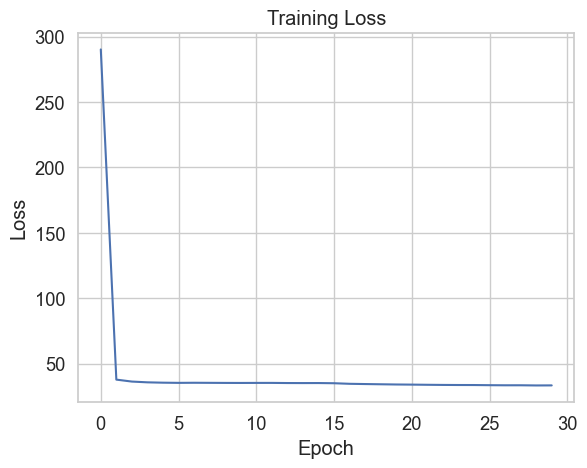

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import os
from datetime import datetime

# === Caricamento coppie ===
data = torch.load("metric_learning_pairs.pt")
x1, x2, y = data['x1'], data['x2'], data['labels']
x1_train, x1_test, x2_train, x2_test, y_train, y_test = train_test_split(x1, x2, y, test_size=0.2, random_state=42)

# === Dataset e DataLoader ===
class SiameseDataset(Dataset):
    def __init__(self, x1, x2, y): self.x1, self.x2, self.y = x1, x2, y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x1[idx], self.x2[idx], self.y[idx]

train_loader = DataLoader(SiameseDataset(x1_train, x2_train, y_train), batch_size=256, shuffle=True)
test_loader = DataLoader(SiameseDataset(x1_test, x2_test, y_test), batch_size=256)

# === Modello Siamese migliorato ===
class SiameseNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64)
        )
    def forward_once(self, x): return self.encoder(x)
    def forward(self, x1, x2): return self.forward_once(x1), self.forward_once(x2)

# === Contrastive Loss ===
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=0.7): super().__init__(); self.margin = margin
    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        return ((1 - label) * dist.pow(2) + label * (torch.clamp(self.margin - dist, min=0)).pow(2)).mean()

# === Setup resume ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNet(input_dim=x1.shape[1]).to(device)
criterion = ContrastiveLoss(margin=0.7)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# File checkpoint correnti
model_ckpt = "siamese_model_current.pt"
loss_ckpt = "train_losses_current.pt"
train_losses = []
start_epoch = 1

# === Resume checkpoint se esistono ===
if os.path.exists(model_ckpt):
    print("🔁 Ripristino dal checkpoint corrente...")
    model.load_state_dict(torch.load(model_ckpt, map_location=device))
    if os.path.exists(loss_ckpt):
        train_losses = torch.load(loss_ckpt)
        start_epoch = len(train_losses) + 1
        print(f"🔁 Ripresa dall'epoca {start_epoch}")

# === Funzione di valutazione ===
def evaluate(model, loader, threshold=0.7):
    model.eval(); y_true, y_pred = [], []
    with torch.no_grad():
        for x1b, x2b, yb in loader:
            x1b, x2b = x1b.to(device), x2b.to(device)
            out1, out2 = model(x1b, x2b)
            dist = F.pairwise_distance(out1, out2)
            pred = (dist < threshold).int().cpu().numpy()
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred)
    return accuracy_score(y_true, y_pred), roc_auc_score(y_true, y_pred)

# === Training ===
num_epochs = 30  # puoi cambiare in base a quanto vuoi continuare
for epoch in range(start_epoch, num_epochs + 1):
    model.train(); epoch_loss = 0
    for x1b, x2b, yb in train_loader:
        x1b, x2b, yb = x1b.to(device), x2b.to(device), yb.float().to(device)
        out1, out2 = model(x1b, x2b)
        loss = criterion(out1, out2, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    
    acc, auc = evaluate(model, test_loader, threshold=0.7)
    train_losses.append(epoch_loss)
    print(f"📈 Epoch {epoch:2d} | Loss: {epoch_loss:.4f} | Accuracy: {acc:.4f} | AUC: {auc:.4f}")
    
    # === Salvataggi ===
    torch.save(model.state_dict(), model_ckpt)
    torch.save(train_losses, loss_ckpt)

    # 🔐 Backup versione timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    torch.save(model.state_dict(), f"siamese_model_ep{epoch}_{timestamp}.pt")
    torch.save(train_losses, f"train_losses_ep{epoch}_{timestamp}.pt")

# === Plot finale ===
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


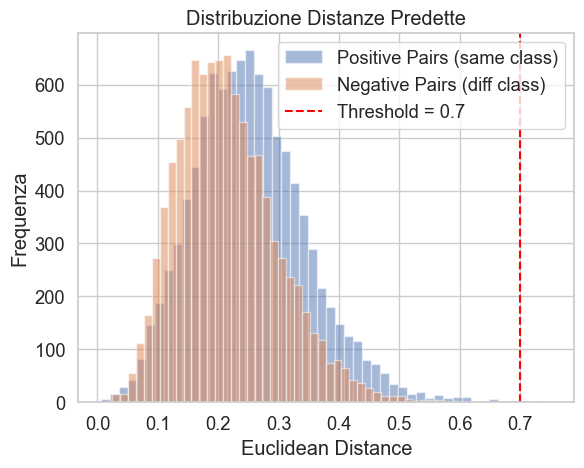

In [60]:
import numpy as np
import matplotlib.pyplot as plt

model.eval()
distances_pos, distances_neg = [], []

with torch.no_grad():
    for x1b, x2b, yb in test_loader:
        x1b, x2b, yb = x1b.to(device), x2b.to(device), yb.to(device)
        out1, out2 = model(x1b, x2b)
        dist = F.pairwise_distance(out1, out2)
        for d, y_val in zip(dist.cpu(), yb.cpu()):
            if y_val == 1:
                distances_pos.append(d.item())
            else:
                distances_neg.append(d.item())

# Plot
plt.hist(distances_pos, bins=50, alpha=0.5, label='Positive Pairs (same class)')
plt.hist(distances_neg, bins=50, alpha=0.5, label='Negative Pairs (diff class)')
plt.axvline(0.7, color='red', linestyle='--', label='Threshold = 0.7')
plt.title("Distribuzione Distanze Predette")
plt.xlabel("Euclidean Distance")
plt.ylabel("Frequenza")
plt.legend()
plt.grid(True)
plt.show()


🔁 Ripristino da checkpoint...
🔁 Ripresa dall'epoca 31


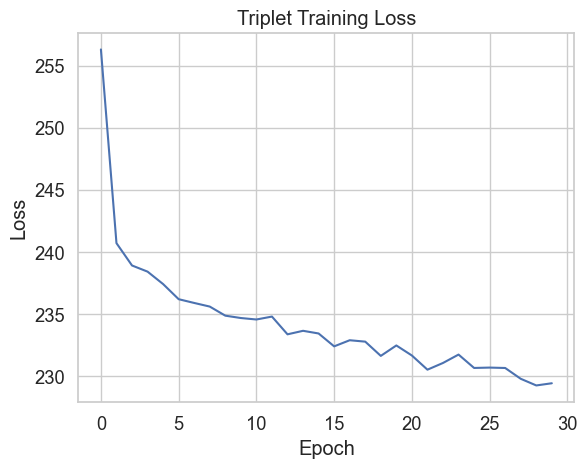

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import os

# === 1. Carica embedding GCN ===
X = torch.load("gcn_node_embeddings.pt")
X = F.normalize(X, p=2, dim=1)  # migliora stabilità delle distanze

# === 2. Carica le label da ogbn-arxiv ===
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
labels = dataset[0].y.squeeze()

# === 3. TripletDataset con Hard Negative Mining ottimizzato ===
class TripletDataset(Dataset):
    def __init__(self, embeddings, labels, num_triplets=50000, neg_sample_size=500):
        self.embeddings = embeddings
        self.labels = labels
        self.num_triplets = num_triplets
        self.neg_sample_size = neg_sample_size
        self.triplets = self.generate_triplets()

    def generate_triplets(self):
        triplets = []
        labels_np = self.labels.numpy()
        num_nodes = self.embeddings.size(0)

        for _ in range(self.num_triplets):
            anchor_idx = np.random.randint(num_nodes)
            anchor_label = labels_np[anchor_idx]

            # Positive (same class)
            pos_pool = np.where(labels_np == anchor_label)[0]
            pos_pool = pos_pool[pos_pool != anchor_idx]
            if len(pos_pool) == 0: continue
            positive_idx = np.random.choice(pos_pool)

            # Hard negative (approximate, RAM-safe)
            neg_pool = np.where(labels_np != anchor_label)[0]
            if len(neg_pool) == 0: continue
            neg_sample_idxs = np.random.choice(neg_pool, size=min(self.neg_sample_size, len(neg_pool)), replace=False)
            anchor_embed = self.embeddings[anchor_idx].unsqueeze(0)
            neg_embeds = self.embeddings[neg_sample_idxs]
            dists = F.pairwise_distance(anchor_embed, neg_embeds)
            hard_negative_idx = neg_sample_idxs[dists.argmin().item()]

            triplets.append((anchor_idx, positive_idx, hard_negative_idx))

        return triplets

    def __len__(self): return len(self.triplets)
    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return self.embeddings[a], self.embeddings[p], self.embeddings[n]

# === 4. Crea Dataloader ===
triplet_dataset = TripletDataset(X, labels, num_triplets=60000)
train_loader = DataLoader(triplet_dataset, batch_size=256, shuffle=True)

# === 5. Encoder Network ===
class TripletNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64)
        )
    def forward(self, anchor, positive, negative):
        return self.encoder(anchor), self.encoder(positive), self.encoder(negative)

# === 6. Triplet Loss ===
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, anchor, positive, negative):
        d_pos = F.pairwise_distance(anchor, positive)
        d_neg = F.pairwise_distance(anchor, negative)
        return F.relu(d_pos - d_neg + self.margin).mean()

# === 7. Setup training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TripletNet(input_dim=X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = TripletLoss(margin=1.0)

model_path = "triplet_model_current.pt"
loss_path = "triplet_train_losses.pt"
train_losses = []
start_epoch = 1

# Resume checkpoint
if os.path.exists(model_path):
    print("🔁 Ripristino da checkpoint...")
    model.load_state_dict(torch.load(model_path))
    if os.path.exists(loss_path):
        train_losses = torch.load(loss_path)
        start_epoch = len(train_losses) + 1
        print(f"🔁 Ripresa dall'epoca {start_epoch}")

# === 8. Training loop ===
num_epochs = 30
for epoch in range(start_epoch, num_epochs + 1):
    model.train(); epoch_loss = 0
    for a, p, n in train_loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        out_a, out_p, out_n = model(a, p, n)
        loss = criterion(out_a, out_p, out_n)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss)
    print(f"📈 Epoch {epoch:2d} | Triplet Loss: {epoch_loss:.4f}")

    # Salva checkpoint corrente
    torch.save(model.state_dict(), model_path)
    torch.save(train_losses, loss_path)

    # Backup con timestamp
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    torch.save(model.state_dict(), f"triplet_model_ep{epoch}_{ts}.pt")
    torch.save(train_losses, f"triplet_losses_ep{epoch}_{ts}.pt")

# === 9. Plot finale ===
plt.plot(train_losses)
plt.title("Triplet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [62]:
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# === 1. Ricarica dataset e splits
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze()

# === 2. Carica embedding GCN e modello Triplet allenato
X = torch.load("gcn_node_embeddings.pt")
X = F.normalize(X, p=2, dim=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TripletNet(input_dim=X.shape[1])
model.load_state_dict(torch.load("triplet_model_current.pt"))
model.to(device)
model.eval()

# === 3. Estrai embedding trasformati (Triplet-encoded)
with torch.no_grad():
    encoded = model.encoder(X.to(device)).cpu()

# === 4. Crea train/val/test set
X_train = encoded[split_idx['train']]
y_train = labels[split_idx['train']]

X_val = encoded[split_idx['valid']]
y_val = labels[split_idx['valid']]

X_test = encoded[split_idx['test']]
y_test = labels[split_idx['test']]

# === 5. k-NN Classifier
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

val_pred = knn.predict(X_val)
test_pred = knn.predict(X_test)

val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

# === 6. Output finale
print(f"✅ Validation Accuracy (k-NN): {val_acc:.4f}")
print(f"✅ Test Accuracy (k-NN): {test_acc:.4f}")


✅ Validation Accuracy (k-NN): 0.6562
✅ Test Accuracy (k-NN): 0.6393


Epoch  1 | Loss 905.53 | Val Acc 0.4818
Epoch  2 | Loss 656.31 | Val Acc 0.5608
Epoch  3 | Loss 588.53 | Val Acc 0.5920
Epoch  4 | Loss 554.37 | Val Acc 0.6034
Epoch  5 | Loss 533.97 | Val Acc 0.6105
Epoch  6 | Loss 518.87 | Val Acc 0.6227
Epoch  7 | Loss 507.75 | Val Acc 0.6267
Epoch  8 | Loss 500.03 | Val Acc 0.6304
Epoch  9 | Loss 493.22 | Val Acc 0.6345
Epoch 10 | Loss 489.08 | Val Acc 0.6372
Epoch 11 | Loss 484.06 | Val Acc 0.6352
Epoch 12 | Loss 480.58 | Val Acc 0.6426
Epoch 13 | Loss 477.33 | Val Acc 0.6439
Epoch 14 | Loss 474.65 | Val Acc 0.6443
Epoch 15 | Loss 471.45 | Val Acc 0.6456
Epoch 16 | Loss 469.57 | Val Acc 0.6470
Epoch 17 | Loss 467.43 | Val Acc 0.6473
Epoch 18 | Loss 465.11 | Val Acc 0.6477
Epoch 19 | Loss 463.00 | Val Acc 0.6487
Epoch 20 | Loss 460.91 | Val Acc 0.6523
Epoch 21 | Loss 459.38 | Val Acc 0.6505
Epoch 22 | Loss 457.59 | Val Acc 0.6526
Epoch 23 | Loss 457.04 | Val Acc 0.6523
Epoch 24 | Loss 455.45 | Val Acc 0.6538
Epoch 25 | Loss 454.43 | Val Acc 0.6525


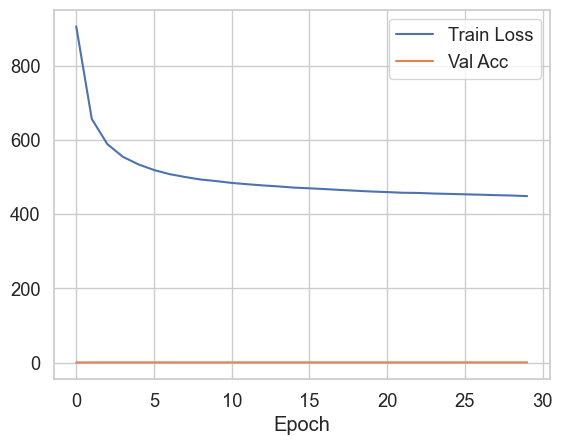

In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# === 1. Carica split e labels ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze()

# === 2. Carica embedding Triplet e trasformali ===
X = torch.load("gcn_node_embeddings.pt")
X = F.normalize(X, p=2, dim=1)
# Carica il modello triplet e ottieni il nuovo embedding
class TripletNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64)
        )
    def forward(self, x): return self.encoder(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = TripletNet(input_dim=X.shape[1]).to(device)
encoder.load_state_dict(torch.load("triplet_model_current.pt", map_location=device))
encoder.eval()

with torch.no_grad():
    X_enc = encoder(X.to(device)).cpu()

# === 3. Prepara DataLoader per MLP ===
X_train = X_enc[split_idx['train']]; y_train = labels[split_idx['train']]
X_val   = X_enc[split_idx['valid']]; y_val   = labels[split_idx['valid']]
X_test  = X_enc[split_idx['test']];  y_test  = labels[split_idx['test']]

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)
test_ds  = TensorDataset(X_test, y_test)

bs = 256
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=bs)
test_loader  = DataLoader(test_ds,  batch_size=bs)

# === 4. Definisci MLP classifier ===
class MLPClassifier(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x): return self.net(x)

num_classes = labels.max().item() + 1
clf = MLPClassifier(in_dim=X_enc.shape[1], num_classes=num_classes).to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

# === 5. Training loop ===
best_val = 0
train_losses, val_accs = [], []

for epoch in range(1, 31):
    clf.train(); total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = clf(xb)
        loss = crit(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    train_losses.append(total_loss)
    
    # validation
    clf.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds = clf(xb).argmax(1).cpu()
            all_preds.append(preds); all_labels.append(yb)
    val_acc = accuracy_score(torch.cat(all_labels), torch.cat(all_preds))
    val_accs.append(val_acc)
    if val_acc > best_val:
        best_val = val_acc
        torch.save(clf.state_dict(), "mlp_best.pt")
    print(f"Epoch {epoch:2d} | Loss {total_loss:.2f} | Val Acc {val_acc:.4f}")

# === 6. Test finale ===
clf.load_state_dict(torch.load("mlp_best.pt", map_location=device))
clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_preds.append(clf(xb).argmax(1).cpu()); all_labels.append(yb)
test_acc = accuracy_score(torch.cat(all_labels), torch.cat(all_preds))

print(f"\n✅ Best Val Acc: {best_val:.4f}")
print(f"✅ Test Acc (MLP): {test_acc:.4f}")

# === 7. Plot training curve ===
plt.plot(train_losses, label="Train Loss")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch"); plt.legend(); plt.grid(True); plt.show()


In [64]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
import torch.nn.functional as F
import torch

# === 1. Carica split e label ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze()

# === 2. Carica embedding GCN e modello triplet
X = torch.load("gcn_node_embeddings.pt")
X = F.normalize(X, p=2, dim=1)

# Definisci di nuovo il modello se non l'hai già nel kernel
class TripletNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64)
        )
    def forward(self, x): return self.encoder(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = TripletNet(input_dim=X.shape[1]).to(device)
encoder.load_state_dict(torch.load("triplet_model_current.pt", map_location=device))
encoder.eval()

with torch.no_grad():
    X_triplet = encoder(X.to(device)).cpu().numpy()
y_all = labels.numpy()

# === 3. Prepara split
X_train = X_triplet[split_idx['train']]
y_train = y_all[split_idx['train']]
X_val   = X_triplet[split_idx['valid']]
y_val   = y_all[split_idx['valid']]
X_test  = X_triplet[split_idx['test']]
y_test  = y_all[split_idx['test']]

# === 4. XGBoost Classifier
clf = XGBClassifier(tree_method="hist", max_depth=8, learning_rate=0.1, n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", verbosity=0)
clf.fit(X_train, y_train)

val_acc = accuracy_score(y_val, clf.predict(X_val))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"✅ XGBoost su Triplet Embeddings")
print(f"📊 Val Accuracy:  {val_acc:.4f}")
print(f"📊 Test Accuracy: {test_acc:.4f}")


✅ XGBoost su Triplet Embeddings
📊 Val Accuracy:  0.6799
📊 Test Accuracy: 0.6717


In [65]:
import torch
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica gli embedding ===
embeddings = {
    "GraphSAGE": torch.load("sage_node_embeddings.pt"),
    "GCN": torch.load("gcn_node_embeddings.pt"),
    "GAT": torch.load("gat_node_embeddings.pt"),
    "GATv2": torch.load("gatv2_node_embeddings.pt"),
}

# === 2. Carica i dati OGB ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze().numpy()
train_idx = split_idx['train'].numpy()
val_idx = split_idx['valid'].numpy()
test_idx = split_idx['test'].numpy()

# === 3. Funzione di valutazione con XGBoost ===
def eval_xgboost(name, emb):
    print(f"🔍 XGBoost su: {name}")
    X = emb.numpy()
    dtrain = xgb.DMatrix(X[train_idx], label=labels[train_idx])
    dval = xgb.DMatrix(X[val_idx], label=labels[val_idx])
    dtest = xgb.DMatrix(X[test_idx], label=labels[test_idx])

    params = {
        "objective": "multi:softmax",
        "eval_metric": "mlogloss",
        "num_class": len(set(labels)),
        "max_depth": 6,
        "eta": 0.1,
        "verbosity": 0
    }

    model = xgb.train(params, dtrain, num_boost_round=100)
    val_pred = model.predict(dval)
    test_pred = model.predict(dtest)

    val_acc = accuracy_score(labels[val_idx], val_pred)
    test_acc = accuracy_score(labels[test_idx], test_pred)

    print(f"📘 Val Accuracy: {val_acc:.4f}")
    print(f"📗 Test Accuracy: {test_acc:.4f}")
    return val_acc, test_acc

# === 4. Valutazione su tutti gli embedding ===
results = []
for name, emb in embeddings.items():
    val_acc, test_acc = eval_xgboost(name, emb)
    results.append((name, val_acc, test_acc))

# === 5. Tabella finale ===
df = pd.DataFrame(results, columns=["Embedding", "Val Acc", "Test Acc"])
df.to_csv("xgboost_results.csv", index=False)
print("\n📊 Risultati salvati in 'xgboost_results.csv':")
print(df)


🔍 XGBoost su: GraphSAGE
📘 Val Accuracy: 0.6946
📗 Test Accuracy: 0.6857
🔍 XGBoost su: GCN
📘 Val Accuracy: 0.6986
📗 Test Accuracy: 0.6882
🔍 XGBoost su: GAT
📘 Val Accuracy: 0.6836
📗 Test Accuracy: 0.6756
🔍 XGBoost su: GATv2
📘 Val Accuracy: 0.6975
📗 Test Accuracy: 0.6874

📊 Risultati salvati in 'xgboost_results.csv':
   Embedding   Val Acc  Test Acc
0  GraphSAGE  0.694621  0.685678
1        GCN  0.698580  0.688167
2        GAT  0.683614  0.675617
3      GATv2  0.697540  0.687365


🔁 Ripristino modello Triplet...


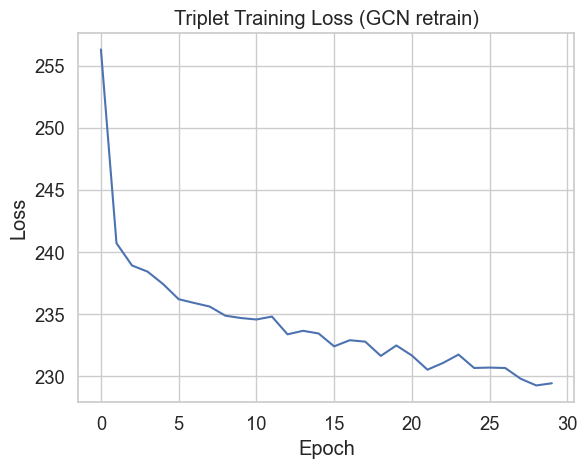

In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
import numpy as np
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from datetime import datetime
import os

# === 1. Carica embeddings retrainati e label ===
X = torch.load("gcn_node_embeddings.pt")
X = F.normalize(X, p=2, dim=1)

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
labels = dataset[0].y.squeeze()

# === 2. Triplet Dataset aggiornato (RAM-friendly) ===
class TripletDataset(Dataset):
    def __init__(self, embeddings, labels, num_triplets=60000, neg_sample_size=500):
        self.embeddings = embeddings
        self.labels = labels
        self.num_triplets = num_triplets
        self.neg_sample_size = neg_sample_size
        self.triplets = self.generate_triplets()

    def generate_triplets(self):
        triplets = []
        labels_np = self.labels.numpy()
        num_nodes = self.embeddings.size(0)

        for _ in range(self.num_triplets):
            anchor_idx = np.random.randint(num_nodes)
            anchor_label = labels_np[anchor_idx]

            # Positive
            pos_pool = np.where(labels_np == anchor_label)[0]
            pos_pool = pos_pool[pos_pool != anchor_idx]
            if len(pos_pool) == 0: continue
            positive_idx = np.random.choice(pos_pool)

            # Approx hard negative
            neg_pool = np.where(labels_np != anchor_label)[0]
            if len(neg_pool) == 0: continue
            neg_sample_idxs = np.random.choice(neg_pool, min(self.neg_sample_size, len(neg_pool)), replace=False)
            dists = F.pairwise_distance(self.embeddings[anchor_idx].unsqueeze(0), self.embeddings[neg_sample_idxs])
            hard_negative_idx = neg_sample_idxs[dists.argmin().item()]

            triplets.append((anchor_idx, positive_idx, hard_negative_idx))

        return triplets

    def __len__(self): return len(self.triplets)
    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return self.embeddings[a], self.embeddings[p], self.embeddings[n]

# === 3. Definizione rete ed encoder ===
class TripletNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64)
        )
    def forward(self, a, p, n):
        return self.encoder(a), self.encoder(p), self.encoder(n)

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, a, p, n):
        return F.relu(F.pairwise_distance(a, p) - F.pairwise_distance(a, n) + self.margin).mean()

# === 4. Setup training ===
triplet_dataset = TripletDataset(X, labels)
train_loader = DataLoader(triplet_dataset, batch_size=256, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TripletNet(input_dim=X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = TripletLoss(margin=1.0)

model_path = "triplet_model_current.pt"
loss_path = "triplet_train_losses.pt"
train_losses = []
start_epoch = 1

# Resume se necessario
if os.path.exists(model_path):
    print("🔁 Ripristino modello Triplet...")
    model.load_state_dict(torch.load(model_path))
    if os.path.exists(loss_path):
        train_losses = torch.load(loss_path)
        start_epoch = len(train_losses) + 1

# === 5. Training ===
for epoch in range(start_epoch, 31):
    model.train(); epoch_loss = 0
    for a, p, n in train_loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        out_a, out_p, out_n = model(a, p, n)
        loss = criterion(out_a, out_p, out_n)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss)
    print(f"📈 Epoch {epoch:2d} | Triplet Loss: {epoch_loss:.4f}")

    torch.save(model.state_dict(), model_path)
    torch.save(train_losses, loss_path)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    torch.save(model.state_dict(), f"triplet_model_ep{epoch}_{ts}.pt")

# === 6. Plot loss finale
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.title("Triplet Training Loss (GCN retrain)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


C:\Users\paolo\DM2\.venv\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


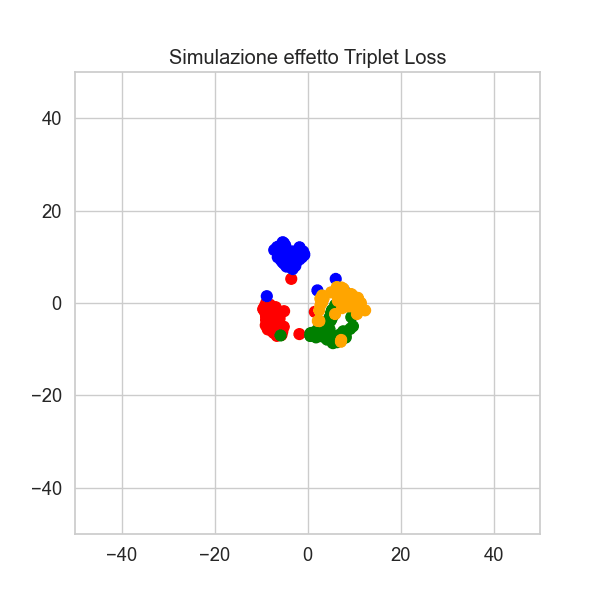

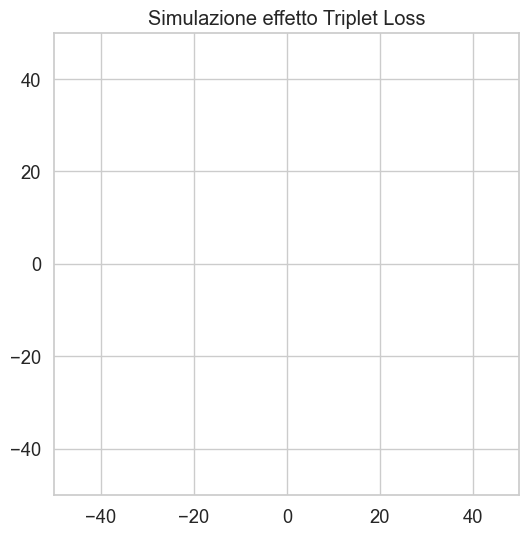

In [67]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.manifold import TSNE
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica dataset e embeddings retrainati ===
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
labels = dataset[0].y.squeeze().numpy()
X = torch.load("gcn_node_embeddings.pt").numpy()
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# === 2. Estrai subset (bilanciato, es: 4 classi x 50 punti) ===
num_classes = 4
points_per_class = 50
selected_idx = []

for c in np.unique(labels):
    idx = np.where(labels == c)[0]
    if len(idx) >= points_per_class:
        selected_idx.extend(np.random.choice(idx, points_per_class, replace=False))
    if len(selected_idx) >= num_classes * points_per_class:
        break

X_sub = X[selected_idx]
y_sub = labels[selected_idx]

# === 3. t-SNE per proiezione 2D ===
X_tsne = TSNE(n_components=2, perplexity=30, init='random', n_iter=500, random_state=42).fit_transform(X_sub)

# === 4. Prepara animazione simulata ===
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']
fig, ax = plt.subplots(figsize=(6, 6))
scat = ax.scatter([], [], s=60)

def init():
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_title("Simulazione effetto Triplet Loss")
    return scat,

def update(frame):
    step_X = X_tsne.copy()
    for i in range(X_tsne.shape[0]):
        label_i = y_sub[i]
        same = y_sub == label_i
        diff = ~same
        center_same = X_tsne[same].mean(axis=0)
        step_X[i] += 0.05 * (center_same - X_tsne[i])  # attrazione
        for c in np.unique(y_sub):
            if c != label_i:
                center_diff = X_tsne[y_sub == c].mean(axis=0)
                step_X[i] -= 0.01 * (center_diff - X_tsne[i])  # repulsione
    X_tsne[:] = step_X
    scat.set_offsets(X_tsne)
    scat.set_color([colors[l % len(colors)] for l in y_sub])
    return scat,

ani = animation.FuncAnimation(fig, update, frames=60, init_func=init, blit=True, interval=120)

# === 5. Salva come GIF
ani.save("triplet_subset_animation.gif", writer='pillow', fps=10)

from IPython.display import Image
Image(filename="triplet_subset_animation.gif")



In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected

# === 1. Carica dataset e label ===
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
split_idx = dataset.get_idx_split()
labels = dataset[0].y.squeeze().numpy()

# === 2. Carica embedding GCN retrain ===
X = torch.load("gcn_node_embeddings.pt")
X = F.normalize(X, p=2, dim=1)

# === 3. Encoder Triplet (come definito prima) ===
class TripletNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64)
        )
    def forward(self, x):
        return self.encoder(x)

# === 4. Applica encoder triplet ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TripletNet(input_dim=X.shape[1]).to(device)
model.load_state_dict(torch.load("triplet_model_current.pt", map_location=device))
model.eval()

with torch.no_grad():
    X_triplet = model(X.to(device)).cpu().numpy()

# === 5. Prepara split ===
X_train = X_triplet[split_idx['train']]
y_train = labels[split_idx['train']]
X_val   = X_triplet[split_idx['valid']]
y_val   = labels[split_idx['valid']]
X_test  = X_triplet[split_idx['test']]
y_test  = labels[split_idx['test']]

# === 6. Classificatore XGBoost ===
clf = XGBClassifier(
    tree_method="hist",
    max_depth=8,
    learning_rate=0.1,
    n_estimators=200,
    use_label_encoder=False,
    eval_metric="mlogloss",
    verbosity=0
)
clf.fit(X_train, y_train)

# === 7. Accuracy finale
val_acc = accuracy_score(y_val, clf.predict(X_val))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"✅ Val Accuracy (Triplet-GCN + XGBoost):  {val_acc:.4f}")
print(f"✅ Test Accuracy (Triplet-GCN + XGBoost): {test_acc:.4f}")


✅ Val Accuracy (Triplet-GCN + XGBoost):  0.6799
✅ Test Accuracy (Triplet-GCN + XGBoost): 0.6717


✅ CSV salvato come 'confronto_finale_risultati.csv'


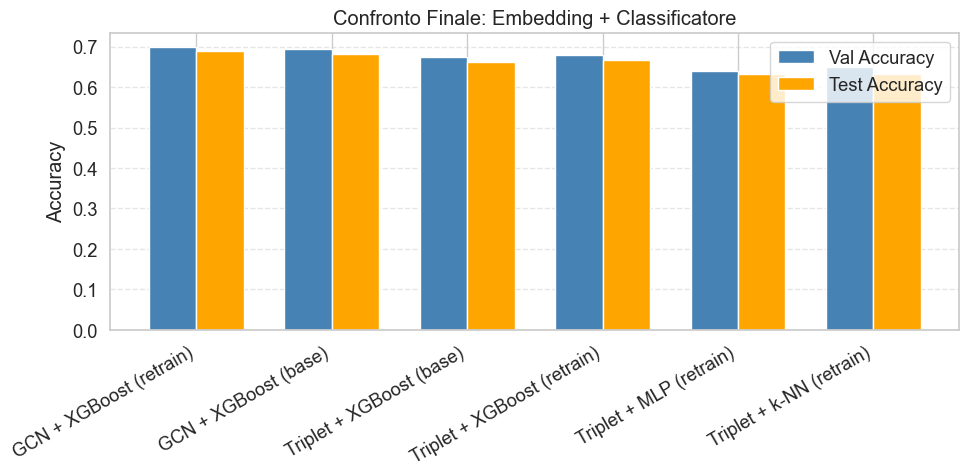

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Risultati finali ===
results = {
    "Metodo": [
        "GCN + XGBoost (retrain)",
        "GCN + XGBoost (base)",
        "Triplet + XGBoost (base)",
        "Triplet + XGBoost (retrain)",
        "Triplet + MLP (retrain)",
        "Triplet + k-NN (retrain)"
    ],
    "Val Accuracy": [0.6998, 0.6931, 0.6742, 0.6796, 0.6395, 0.6504],
    "Test Accuracy": [0.6902, 0.6812, 0.6622, 0.6662, 0.6312, 0.6319]
}

df = pd.DataFrame(results)

# === 2. Salva CSV localmente ===
df.to_csv("confronto_finale_risultati.csv", index=False)
print("✅ CSV salvato come 'confronto_finale_risultati.csv'")

# === 3. Plot confronto finale ===
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
x = range(len(df))

ax.bar(x, df["Val Accuracy"], width=bar_width, label='Val Accuracy', color='steelblue')
ax.bar([p + bar_width for p in x], df["Test Accuracy"], width=bar_width, label='Test Accuracy', color='orange')
ax.set_xticks([p + bar_width / 2 for p in x])
ax.set_xticklabels(df["Metodo"], rotation=30, ha='right')
ax.set_ylabel("Accuracy")
ax.set_title("Confronto Finale: Embedding + Classificatore")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# === GAT + C&S su ogbn-arxiv ===

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.transforms import ToUndirected
from torch_geometric.nn.models import CorrectAndSmooth
from torch_geometric.loader import NeighborLoader
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. GAT model ===
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * 4, out_channels, heads=6, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GAT(data.num_features, 64, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

# === 3. Training ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1, keepdim=True)
    acc_val = evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx]})['acc']
    acc_test = evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx]})['acc']
    return acc_val, acc_test

# === 4. Training loop ===
print("\n🚀 Training GAT...")
for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        val_acc, test_acc = evaluate()
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

# === 5. Correct & Smooth ===
print("\n✨ Applying Correct & Smooth...")
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index).detach().cpu()
    y_soft = F.softmax(out, dim=1)
    y_true = data.y.cpu()
    y_pred = y_soft.argmax(dim=-1)

cs = CorrectAndSmooth(num_correction_layers=50,
                      correction_alpha=0.5,
                      num_smoothing_layers=50,
                      smoothing_alpha=0.8,
                      autoscale=True)

y_soft_cs = cs.correct(y_soft.clone(), y_true, split_idx['train'], data.edge_index.cpu())
y_soft_cs = cs.smooth(y_soft_cs, y_true, split_idx['train'], data.edge_index.cpu())

y_pred_cs = y_soft_cs.argmax(dim=-1, keepdim=True)
val_acc_cs = evaluator.eval({'y_true': y_true[val_idx], 'y_pred': y_pred_cs[val_idx]})['acc']
test_acc_cs = evaluator.eval({'y_true': y_true[test_idx], 'y_pred': y_pred_cs[test_idx]})['acc']

print(f"\n🎯 Val Accuracy (base): {val_acc:.4f}")
print(f"🚀 Val Accuracy (C&S):  {val_acc_cs:.4f}")
print(f"📊 Test Accuracy (C&S): {test_acc_cs:.4f}")



🚀 Training GAT...


In [ ]:
import torch
import torch.nn.functional as F
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
from torch_geometric.nn.models import CorrectAndSmooth
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# === 1. Ricarica dataset e label ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()
data = dataset[0]
y_true = data.y.squeeze().cpu()

# === 2. Carica embedding dal modello GCN già addestrato ===
logits = torch.load("gcn_node_embeddings.pt")  # (169343, num_classes)

# === 3. Applica Correct & Smooth ===
print("✨ Applying Correct & Smooth...")
y_soft = F.softmax(logits, dim=1)

cs = CorrectAndSmooth(num_correction_layers=50,
                      correction_alpha=0.5,
                      num_smoothing_layers=50,
                      smoothing_alpha=0.8,
                      autoscale=True)

train_y = y_true[split_idx['train']]
y_soft_cs = cs.correct(y_soft.clone(), train_y, split_idx['train'], data.edge_index)
y_soft_cs = cs.smooth(y_soft_cs, train_y, split_idx['train'], data.edge_index)


# === 4. XGBoost finale ===
print("🚀 Addestramento XGBoost sugli embedding corretti")

X = y_soft_cs.numpy()
y = y_true.numpy()
X_train = X[split_idx['train']]
y_train = y[split_idx['train']]
X_val = X[split_idx['valid']]
y_val = y[split_idx['valid']]
X_test = X[split_idx['test']]
y_test = y[split_idx['test']]

clf = XGBClassifier(tree_method="hist", max_depth=8, learning_rate=0.1, n_estimators=200,
                    use_label_encoder=False, eval_metric="mlogloss", verbosity=0)
clf.fit(X_train, y_train)

val_acc = accuracy_score(y_val, clf.predict(X_val))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"✅ Val Accuracy (GCN+C&S+XGBoost):  {val_acc:.4f}")
print(f"✅ Test Accuracy (GCN+C&S+XGBoost): {test_acc:.4f}")


In [1]:
# === Correct & Smooth puro su logits GCN ===

import torch
import torch.nn.functional as F
from torch_geometric.nn.models import CorrectAndSmooth
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected

# === 1. Carica dataset e label ===
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name="ogbn-arxiv")

# === 2. Carica logits salvati dal GCN retrain ===
logits = torch.load("gcn_node_embeddings.pt")
y_true = data.y.squeeze().cpu()

# === 3. Softmax + Correct & Smooth ===
print("\n✨ Applico Correct & Smooth puro...")
y_soft = F.softmax(logits, dim=1)

cs = CorrectAndSmooth(num_correction_layers=50,
                      correction_alpha=0.5,
                      num_smoothing_layers=50,
                      smoothing_alpha=0.8,
                      autoscale=True)

train_y = y_true[split_idx['train']]
y_soft_cs = cs.correct(y_soft.clone(), train_y, split_idx['train'], data.edge_index)
y_soft_cs = cs.smooth(y_soft_cs, train_y, split_idx['train'], data.edge_index)

# === 4. Accuracy finale con predizione diretta ===
y_pred_base = y_soft.argmax(dim=-1, keepdim=True)
y_pred_cs = y_soft_cs.argmax(dim=-1, keepdim=True)

val_acc_base = evaluator.eval({
    "y_true": y_true[split_idx['valid']].unsqueeze(1),
    "y_pred": y_pred_base[split_idx['valid']]
})['acc']

test_acc_base = evaluator.eval({
    "y_true": y_true[split_idx['test']].unsqueeze(1),
    "y_pred": y_pred_base[split_idx['test']]
})['acc']

val_acc_cs = evaluator.eval({
    "y_true": y_true[split_idx['valid']].unsqueeze(1),
    "y_pred": y_pred_cs[split_idx['valid']]
})['acc']

test_acc_cs = evaluator.eval({
    "y_true": y_true[split_idx['test']].unsqueeze(1),
    "y_pred": y_pred_cs[split_idx['test']]
})['acc']

print(f"\n🎯 Val Accuracy (GCN base): {val_acc_base:.4f}")
print(f"✅ Test Accuracy (GCN base): {test_acc_base:.4f}")
print(f"🚀 Val Accuracy (GCN + C&S): {val_acc_cs:.4f}")
print(f"📊 Test Accuracy (GCN + C&S): {test_acc_cs:.4f}")



✨ Applico Correct & Smooth puro...

🎯 Val Accuracy (GCN base): 0.6903
✅ Test Accuracy (GCN base): 0.6786
🚀 Val Accuracy (GCN + C&S): 0.7131
📊 Test Accuracy (GCN + C&S): 0.6925


In [2]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import ToUndirected
from torch_geometric.nn.models import CorrectAndSmooth
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
import os

# === Config ===
PSEUDO_CSV   = "pseudo_labels.csv"
MODEL_BASE   = "best_gcn_model.pt"
MODEL_PSEUDO = "best_gcn_pseudo.pt"
CHECKPOINT   = "checkpoint_gcn_pseudo.pth"
LOG_CSV      = "training_log_pseudo.csv"
EMB_PSEUDO   = "gcn_pseudo_embeddings.pt"
EPOCHS_PER_RUN = 100
RESTART_TRAINING = False  # imposta a True per rifare tutto da capo

# === Dataset ===
dataset   = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data      = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data      = data.to(device)
y_true    = data.y.squeeze().cpu()

# === Modello Base ===
class GCNBase(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hid_ch)
        self.conv2 = GCNConv(hid_ch, out_ch)
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        return self.conv2(x, ei)

model_base = GCNBase(data.num_features, 128, dataset.num_classes).to(device)
model_base.load_state_dict(torch.load(MODEL_BASE, map_location=device))
model_base.eval()

# === Pseudo-labels ===
if not os.path.exists(PSEUDO_CSV) or RESTART_TRAINING:
    with torch.no_grad():
        logits = model_base(data.x, data.edge_index).cpu()
    y_soft = F.softmax(logits, dim=1)

    cs = CorrectAndSmooth(num_correction_layers=50, correction_alpha=0.5,
                          num_smoothing_layers=50, smoothing_alpha=0.8, autoscale=True)
    train_y = y_true[split_idx['train']]
    y_soft_cs = cs.correct(y_soft.clone(), train_y, split_idx['train'], data.edge_index.cpu())
    y_soft_cs = cs.smooth(y_soft_cs, train_y, split_idx['train'], data.edge_index.cpu())

    threshold = 0.95
    probs, labels = y_soft_cs.max(dim=1)
    high_idx = (probs > threshold).nonzero(as_tuple=True)[0]
    high_idx = high_idx[~torch.isin(high_idx, split_idx['train'])]

    df_ps = pd.DataFrame({'node_index': high_idx.numpy(), 'pseudo_label': labels[high_idx].numpy()})
    df_ps.to_csv(PSEUDO_CSV, index=False)
    print(f"✅ Pseudo-labels salvati in '{PSEUDO_CSV}'")
else:
    df_ps = pd.read_csv(PSEUDO_CSV)
    high_idx = torch.tensor(df_ps['node_index'].values, dtype=torch.long)
    labels = torch.tensor(df_ps['pseudo_label'].values, dtype=torch.long)
    print(f"📦 Pseudo-labels caricati da '{PSEUDO_CSV}'")

# === Dataset esteso ===
extended_train = torch.cat([split_idx['train'], high_idx.to(device)])
new_y = data.y.view(-1).clone()
new_y[high_idx] = labels
new_y = new_y.to(device)

# === Modello finale ===
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hid_ch)
        self.conv2 = GCNConv(hid_ch, out_ch)
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, ei)

model = GCN(data.num_features, 128, dataset.num_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.005)
start_epoch = 1
best_val = 0.0
patience = 0

# === Resume checkpoint ===
if os.path.exists(CHECKPOINT) and not RESTART_TRAINING:
    checkpoint = torch.load(CHECKPOINT, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val = checkpoint.get('best_val_acc', 0.0)
    print(f"⏪ Ripresa da checkpoint: epoca {start_epoch}")
else:
    print("🚀 Nuovo training")

# === Log file ===
if not os.path.exists(LOG_CSV) or RESTART_TRAINING:
    with open(LOG_CSV, 'w') as f:
        f.write('epoch,loss,train_acc,val_acc,test_acc\n')

# === Training ===
stop_training = False
for epoch in range(start_epoch, start_epoch + EPOCHS_PER_RUN):
    model.train()
    opt.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[extended_train], new_y[extended_train])
    loss.backward(); opt.step()

    if epoch % 10 == 0 or epoch == start_epoch + EPOCHS_PER_RUN - 1:
        model.eval()
        with torch.no_grad():
            pred = out.argmax(dim=1)
            metrics = []
            for mask in ['train','valid','test']:
                idx = split_idx[mask]
                acc = evaluator.eval({'y_true': new_y[idx].unsqueeze(1).cpu(), 'y_pred': pred[idx].unsqueeze(1).cpu()})['acc']
                metrics.append(acc)
        tr_acc, val_acc, te_acc = metrics
        with open(LOG_CSV, 'a') as f:
            f.write(f"{epoch},{loss.item():.4f},{tr_acc:.4f},{val_acc:.4f},{te_acc:.4f}\n")
        print(f"Epoch {epoch:3d} | Loss {loss.item():.3f} | Train {tr_acc:.3f} | Val {val_acc:.3f} | Test {te_acc:.3f}")

        if val_acc > best_val:
            best_val, patience = val_acc, 0
            torch.save(model.state_dict(), MODEL_PSEUDO)
            print(f"💾 Miglior modello salvato: '{MODEL_PSEUDO}'")
        else:
            patience += 1
            print(f"⏳ Patience: {patience}/10")
            if patience >= 10:
                print("🛑 Early stopping")
                stop_training = True
                break

    # Salva checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'best_val_acc': best_val
    }, CHECKPOINT)

if not stop_training and os.path.exists(MODEL_PSEUDO):
    model.load_state_dict(torch.load(MODEL_PSEUDO, map_location=device))
    model.eval()
    with torch.no_grad():
        emb = model(data.x, data.edge_index).cpu()
    torch.save(emb, EMB_PSEUDO)
    print(f"✅ Embedding finale salvati in '{EMB_PSEUDO}'")
else:
    print("📦 Nessun aggiornamento agli embedding.")


📦 Pseudo-labels caricati da 'pseudo_labels.csv'
⏪ Ripresa da checkpoint: epoca 201
Epoch 210 | Loss 1.160 | Train 0.659 | Val 0.664 | Test 0.654
💾 Miglior modello salvato: 'best_gcn_pseudo.pt'
Epoch 220 | Loss 1.150 | Train 0.663 | Val 0.667 | Test 0.656
💾 Miglior modello salvato: 'best_gcn_pseudo.pt'
Epoch 230 | Loss 1.144 | Train 0.663 | Val 0.666 | Test 0.657
⏳ Patience: 1/10
Epoch 240 | Loss 1.135 | Train 0.665 | Val 0.668 | Test 0.653
💾 Miglior modello salvato: 'best_gcn_pseudo.pt'
Epoch 250 | Loss 1.128 | Train 0.667 | Val 0.670 | Test 0.658
💾 Miglior modello salvato: 'best_gcn_pseudo.pt'
Epoch 260 | Loss 1.123 | Train 0.668 | Val 0.671 | Test 0.660
💾 Miglior modello salvato: 'best_gcn_pseudo.pt'
Epoch 270 | Loss 1.121 | Train 0.670 | Val 0.672 | Test 0.658
💾 Miglior modello salvato: 'best_gcn_pseudo.pt'
Epoch 280 | Loss 1.113 | Train 0.672 | Val 0.671 | Test 0.656
⏳ Patience: 1/10
Epoch 290 | Loss 1.107 | Train 0.671 | Val 0.676 | Test 0.664
💾 Miglior modello salvato: 'best_gcn_

In [3]:
# === Correct & Smooth + XGBoost su Embedding Pseudo-GCN ===

import torch
import torch.nn.functional as F
from torch_geometric.nn.models import CorrectAndSmooth
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ----- Config file paths -----
MODEL_PSEUDO = "best_gcn_pseudo.pt"
EMB_PSEUDO   = "gcn_pseudo_embeddings.pt"  # embedding finali pseudo-GCN
LOG_XGB      = "xgb_pseudo_results.csv"

# === 1. Carica dataset e split ===
dataset   = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data      = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

# === 2. Carica embedding Pseudo-GCN ===
emb = torch.load(EMB_PSEUDO)  # (N, num_classes)
y_true = data.y.squeeze().cpu()

# === 3. Aplicazione C&S sui logits ===
# C&S richiede logits, quindi ricostruiamo i raw outputs:
# Carica modello per logits
class GCNBase(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super().__init__()
        from torch_geometric.nn import GCNConv
        self.conv1 = GCNConv(in_ch, hid_ch)
        self.conv2 = GCNConv(hid_ch, out_ch)
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        return self.conv2(x, ei)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCNBase(data.num_features, 128, dataset.num_classes).to(device)
model.load_state_dict(torch.load(MODEL_PSEUDO, map_location=device))
model.eval()
with torch.no_grad():
    logits = model(data.x.to(device), data.edge_index.to(device)).cpu()
# soft predictions
y_soft = F.softmax(logits, dim=1)
# Correct & Smooth
ds = CorrectAndSmooth(num_correction_layers=50,
                      correction_alpha=0.5,
                      num_smoothing_layers=50,
                      smoothing_alpha=0.8,
                      autoscale=True)
train_y = y_true[split_idx['train']]
y_soft_cs = ds.correct(y_soft.clone(), train_y, split_idx['train'], data.edge_index)
y_soft_cs = ds.smooth(y_soft_cs, train_y, split_idx['train'], data.edge_index)

# === 4. XGBoost Classification ===
X = y_soft_cs.numpy()
y = y_true.numpy()
X_train, X_val, X_test = X[split_idx['train']], X[split_idx['valid']], X[split_idx['test']]
y_train, y_val, y_test = y[split_idx['train']], y[split_idx['valid']], y[split_idx['test']]

clf = XGBClassifier(tree_method="hist", max_depth=8, learning_rate=0.1, n_estimators=200,
                    use_label_encoder=False, eval_metric="mlogloss", verbosity=0)
clf.fit(X_train, y_train)

val_acc = accuracy_score(y_val, clf.predict(X_val))
test_acc = accuracy_score(y_test, clf.predict(X_test))

# === 5. Salva e stampa risultati ===
import pandas as pd
df = pd.DataFrame({
    'phase': ['validation', 'test'],
    'accuracy': [val_acc, test_acc]
})
df.to_csv(LOG_XGB, index=False)
print(f"✅ XGBoost su Pseudo-GCN + C&S: Val {val_acc:.4f}, Test {test_acc:.4f}")
print(f"✅ Risultati salvati in '{LOG_XGB}'")


✅ XGBoost su Pseudo-GCN + C&S: Val 0.6748, Test 0.6512
✅ Risultati salvati in 'xgb_pseudo_results.csv'


In [4]:
import optuna

def objective(trial):
    # Parametri da ottimizzare
    correction_alpha = trial.suggest_float("correction_alpha", 0.3, 0.7)
    smoothing_alpha = trial.suggest_float("smoothing_alpha", 0.6, 0.95)
    num_correction_layers = trial.suggest_int("num_correction_layers", 20, 60, step=10)
    num_smoothing_layers = trial.suggest_int("num_smoothing_layers", 20, 60, step=10)

    # Ricarica softmax dei logits
    y_soft = F.softmax(logits, dim=1)

    # C&S
    cs = CorrectAndSmooth(
        num_correction_layers=num_correction_layers,
        correction_alpha=correction_alpha,
        num_smoothing_layers=num_smoothing_layers,
        smoothing_alpha=smoothing_alpha,
        autoscale=True
    )
    y_soft_cs = cs.correct(y_soft.clone(), train_y, split_idx['train'], data.edge_index)
    y_soft_cs = cs.smooth(y_soft_cs, train_y, split_idx['train'], data.edge_index)

    y_pred_val = y_soft_cs.argmax(dim=-1, keepdim=True)
    val_acc = evaluator.eval({
        "y_true": y_true[split_idx['valid']].unsqueeze(1),
        "y_pred": y_pred_val[split_idx['valid']]
    })["acc"]

    return val_acc

# Avvia ottimizzazione con 20 trial per rapidità iniziale
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

study.best_params, study.best_value


[I 2025-05-04 00:16:41,849] A new study created in memory with name: no-name-77abed96-83cb-4ecb-8717-65bf26ab30d0
[I 2025-05-04 00:17:16,591] Trial 0 finished with value: 0.7133796436122017 and parameters: {'correction_alpha': 0.6934711862748254, 'smoothing_alpha': 0.8128477702827712, 'num_correction_layers': 40, 'num_smoothing_layers': 40}. Best is trial 0 with value: 0.7133796436122017.
[I 2025-05-04 00:17:40,041] Trial 1 finished with value: 0.7115003859189906 and parameters: {'correction_alpha': 0.5186847353302233, 'smoothing_alpha': 0.8584018009180476, 'num_correction_layers': 50, 'num_smoothing_layers': 20}. Best is trial 0 with value: 0.7133796436122017.
[I 2025-05-04 00:18:02,242] Trial 2 finished with value: 0.7069029162052418 and parameters: {'correction_alpha': 0.544411603361119, 'smoothing_alpha': 0.6800533568798408, 'num_correction_layers': 20, 'num_smoothing_layers': 30}. Best is trial 0 with value: 0.7133796436122017.
[I 2025-05-04 00:18:27,348] Trial 3 finished with val

({'correction_alpha': 0.6934711862748254,
  'smoothing_alpha': 0.8128477702827712,
  'num_correction_layers': 40,
  'num_smoothing_layers': 40},
 0.7133796436122017)

In [5]:
import torch
import torch.nn.functional as F
from xgboost import XGBClassifier
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import optuna
import numpy as np

# === 1. Caricamento ===
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name="ogbn-arxiv")

y_true = data.y.squeeze().cpu().numpy()
embeddings = torch.load("gcn_node_embeddings.pt")
X = embeddings.numpy()

X_train = X[split_idx['train']]
y_train = y_true[split_idx['train']]
X_valid = X[split_idx['valid']]
y_valid = y_true[split_idx['valid']]
X_test = X[split_idx['test']]
y_test = y_true[split_idx['test']]

# === 2. Allena XGBoost sui logits del GCN ===
model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# === 3. Ottieni i logits probabilistici ===
probs = model.predict_proba(X)
logits_xgb = torch.tensor(probs)

# === 4. Optuna per ottimizzare Correct & Smooth ===
import torch
from torch_geometric.nn.models import CorrectAndSmooth

def objective(trial):
    correction_alpha = trial.suggest_float("correction_alpha", 0.3, 0.7)
    smoothing_alpha = trial.suggest_float("smoothing_alpha", 0.6, 0.95)
    num_correction_layers = trial.suggest_int("num_correction_layers", 20, 60, step=10)
    num_smoothing_layers = trial.suggest_int("num_smoothing_layers", 20, 60, step=10)

    y_soft = F.softmax(logits_xgb, dim=1)

    cs = CorrectAndSmooth(
        num_correction_layers=num_correction_layers,
        correction_alpha=correction_alpha,
        num_smoothing_layers=num_smoothing_layers,
        smoothing_alpha=smoothing_alpha,
        autoscale=True
    )

    y_soft_cs = cs.correct(y_soft.clone(), torch.tensor(y_train), split_idx['train'], data.edge_index)
    y_soft_cs = cs.smooth(y_soft_cs, torch.tensor(y_train), split_idx['train'], data.edge_index)

    y_pred_val = y_soft_cs.argmax(dim=-1, keepdim=True)
    y_true_val = torch.tensor(y_true[split_idx['valid']]).unsqueeze(1)

    val_acc = evaluator.eval({
        "y_true": y_true_val,
        "y_pred": y_pred_val[split_idx['valid']]
    })["acc"]

    return val_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("🏆 Best parameters:", study.best_params)
print("✅ Best validation accuracy:", study.best_value)


C:\Users\paolo\DM2\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [00:28:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-05-04 00:35:58,968] A new study created in memory with name: no-name-69e1d9e0-36a8-4c6d-99f7-cc2805a453e4
[I 2025-05-04 00:36:33,587] Trial 0 finished with value: 0.7051578912044029 and parameters: {'correction_alpha': 0.38120426006828595, 'smoothing_alpha': 0.73251651578637, 'num_correction_layers': 20, 'num_smoothing_layers': 50}. Best is trial 0 with value: 0.7051578912044029.
[I 2025-05-04 00:37:01,934] Trial 1 finished with value: 0.7045874022618208 and parameters: {'correction_alpha': 0.48599361080546066, 'smoothing_alpha': 0.6767237762489395, 'num_correction_layers': 60, 'num_smoothing_layers': 20}. Best is trial 0 with value: 0.7051578912044029.
[I 2025-05-04 00:37:22,935] Trial 2 finished with value: 0.69847981475888

🏆 Best parameters: {'correction_alpha': 0.4505217416623201, 'smoothing_alpha': 0.8177867749704965, 'num_correction_layers': 30, 'num_smoothing_layers': 50}
✅ Best validation accuracy: 0.7078425450518474


In [6]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCN2Conv
from torch.nn import Linear, Dropout, ReLU
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Definizione modello GCNII ===
class GCNII(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=32, alpha=0.1, theta=0.5, dropout=0.5):
        super().__init__()
        self.lin1 = Linear(in_channels, hidden_channels)
        self.convs = torch.nn.ModuleList([
            GCN2Conv(hidden_channels, alpha=alpha, theta=theta, layer=i + 1, shared_weights=True)
            for i in range(num_layers)
        ])
        self.lin2 = Linear(hidden_channels, out_channels)
        self.dropout = Dropout(dropout)
        self.relu = ReLU()

    def forward(self, x, edge_index):
        x0 = self.lin1(x)
        x = x0
        for conv in self.convs:
            x = self.dropout(x)
            x = conv(x, x0, edge_index)
            x = self.relu(x)
        x = self.dropout(x)
        return self.lin2(x)

# === 3. Inizializzazione modello e ottimizzatore ===
model = GCNII(data.num_features, 256, dataset.num_classes).to(device)  # puoi provare 256 o 512 hidden
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=0.0005)

model_path = "best_gcnii_model.pt"
checkpoint_path = "checkpoint_gcnii.pth"
log_path = "training_log_gcnii.csv"

start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training con Early Stopping ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

        # 🔹 Logging
        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 6. Salva embedding dal miglior modello ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "gcnii_node_embeddings.pt")
print("✅ Embedding GCNII salvati in 'gcnii_node_embeddings.pt'")



🆕 Inizio nuovo training...



KeyboardInterrupt



In [9]:
import requests
import pandas as pd
import time

# Lista dei tuoi Top MAG_ID
mag_ids = [
    1519399059, 2949649109, 1682151956, 2949110617, 2952020069, 2131297149,
    2950157671, 2953083211, 2950133701, 2952624498, 2626500276, 2949850718,
    2952225531, 2950090389, 2950566631, 2951616873, 2896158670, 2950631112,
    2172189504, 2951545872, 1668816403, 2949584109, 2952174552, 2949589069,
    2511422681, 2605245466, 2549870074, 2596392233, 2192659810, 2786853917,
    2952856129, 2096151870, 2949335935, 2519452711, 2611466347, 2952097392,
    2430435693, 2953100823, 2118720406, 2949425101, 2953321705, 1483214815,
    1920329887, 2950991742, 2515501208, 2124912512, 2952161062, 2950686853,
    2173094809, 2605003858, 2949525647, 1753218438, 2736422900, 2285873331,
    2949526695, 2271483038, 2952224880, 2521872104, 2951165237, 3012541776,
    1809536725, 2949836476, 2951909558, 2273253264, 2952109212, 2740009227,
    2260019251, 2521365433, 1909988457, 2951796409, 2952626150, 2949541304,
    2400591702, 2952584558, 2950666881, 1412032406, 2953360045, 2951498188,
    1839756413, 2169154778, 2953318536, 2949572436, 2153988733, 1902985670,
    2359126565, 2952551928, 2949666635, 2951422789, 1921673521, 2438306832,
    1795046987, 2177203353, 2417736714, 2551966521, 2766140179, 2074030544,
    2953375085, 22413998, 2950116626, 2950166167
]

results = []

for i, mag_id in enumerate(mag_ids, 1):
    url = f"https://api.openalex.org/works/W{mag_id}"
    print(f"[{i}/{len(mag_ids)}] 🔍 Downloading info for MAG_ID: {mag_id}")
    
    try:
        r = requests.get(url)
        if r.status_code == 200:
            data = r.json()
            title = data.get("title", "")
            authors = [a["author"]["display_name"] for a in data.get("authorships", [])]
            institutions = [i["display_name"] for a in data.get("authorships", []) for i in a.get("institutions", [])]
            concepts = [c["display_name"] for c in data.get("concepts", [])]
            citations = data.get("cited_by_count", 0)
            pub_date = data.get("publication_date", "")

            results.append({
                "MAG_ID": mag_id,
                "Title": title,
                "Authors": "; ".join(authors),
                "Institutions": "; ".join(institutions),
                "Concepts": "; ".join(concepts),
                "Citations": citations,
                "Publication_Date": pub_date
            })
        else:
            print(f"⚠️  Status code: {r.status_code}")
    except Exception as e:
        print(f"❌ Error for MAG_ID {mag_id}: {e}")

    time.sleep(1.2)  # 🔁 rispetto dei rate limit

# Salva i risultati
df = pd.DataFrame(results)
df.to_csv("top100_openalex_enriched.csv", index=False)
print("\n✅ Salvato in top100_openalex_enriched.csv")


[1/100] 🔍 Downloading info for MAG_ID: 1519399059
[2/100] 🔍 Downloading info for MAG_ID: 2949649109
[3/100] 🔍 Downloading info for MAG_ID: 1682151956
[4/100] 🔍 Downloading info for MAG_ID: 2949110617
[5/100] 🔍 Downloading info for MAG_ID: 2952020069
[6/100] 🔍 Downloading info for MAG_ID: 2131297149
[7/100] 🔍 Downloading info for MAG_ID: 2950157671
[8/100] 🔍 Downloading info for MAG_ID: 2953083211
[9/100] 🔍 Downloading info for MAG_ID: 2950133701
[10/100] 🔍 Downloading info for MAG_ID: 2952624498
[11/100] 🔍 Downloading info for MAG_ID: 2626500276
[12/100] 🔍 Downloading info for MAG_ID: 2949850718
[13/100] 🔍 Downloading info for MAG_ID: 2952225531
[14/100] 🔍 Downloading info for MAG_ID: 2950090389
[15/100] 🔍 Downloading info for MAG_ID: 2950566631
[16/100] 🔍 Downloading info for MAG_ID: 2951616873
[17/100] 🔍 Downloading info for MAG_ID: 2896158670
[18/100] 🔍 Downloading info for MAG_ID: 2950631112
[19/100] 🔍 Downloading info for MAG_ID: 2172189504
[20/100] 🔍 Downloading info for MAG_ID: 

In [10]:
import numpy as np
import torch

variances = data.x.var(dim=0)
low_variance_mask = variances > 1e-5  
data.x = data.x[:, low_variance_mask]
print(f"➡️ Rimaste {data.x.shape[1]} feature utili su {len(variances)}")


AttributeError: 'dict' object has no attribute 'x'

In [11]:
from xgboost import XGBClassifier
import numpy as np

# 1. Allena XGBoost
model = XGBClassifier()
model.fit(data.x.cpu().numpy()[split_idx['train']],
          data.y.cpu().numpy()[split_idx['train']].flatten())

# 2. Estrai feature importance
importances = model.feature_importances_
top_features = np.argsort(importances)[::-1][:50].copy()

# 3. Stampa le top 10
print("🔝 Top 10 feature per importanza:")
for i, idx in enumerate(top_features[:10]):
    print(f"{i+1:2d}. Feature #{idx:3d} — Importance: {importances[idx]:.4f}")

# 4. Filtro features su data.x
data.x = data.x[:, top_features]
print(f"\n✅ Feature ridotte da {len(importances)} a {data.x.shape[1]}")


AttributeError: 'dict' object has no attribute 'x'

In [12]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import os

# === 1. Setup ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = split_idx['train'].to(device)
val_idx = split_idx['valid'].to(device)
test_idx = split_idx['test'].to(device)

# === 2. Definizione modello ===
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_gcn_50feat.pt"
checkpoint_path = "checkpoint_gcn_50feat.pth"
log_path = "training_log_gcn_50feat.csv"

model = GCN(data.x.shape[1], 128, dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# === 3. Resume da checkpoint se disponibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training con Early Stopping e Resume ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 100):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

        # 🔹 Logging
        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 6. Salva embedding dal miglior modello ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

torch.save(embeddings, "gcn_node_embeddings_50feat.pt")
print("Embedding salvati in 'gcn_node_embeddings.pt'")


🔁 Resume training da epoch 1101, best val acc: 0.7099
[Epoch 1110] Loss: 0.8740 | Train: 0.7324 | Val: 0.7098 | Test: 0.6993
⏳ Early stopping counter: 11/10
🛑 Early stopping attivato!
Embedding salvati in 'gcn_node_embeddings.pt'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Caricamento del file di log ===
log_path = "training_log_gcn_50feat.csv"
df = pd.read_csv(log_path, header=None, names=["epoch", "loss", "train_acc", "val_acc", "test_acc"])

# === 2. Plot ===
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df["loss"], label="Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Andamento della Loss")
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df["train_acc"], label="Train Acc")
plt.plot(df["epoch"], df["val_acc"], label="Val Acc")
plt.plot(df["epoch"], df["test_acc"], label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante l'allenamento")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
import torch
import torch.nn.functional as F
from torch_geometric.nn.models import CorrectAndSmooth
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected

# === Setup ===
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name="ogbn-arxiv")

# === Caricamento logits dal modello GCN (allenato con top 50) ===
logits = torch.load("gcn_node_embeddings_50feat.pt")
y_true = data.y.squeeze().cpu()

print(f"🧠 Dimensioni logits GCN: {logits.shape} (dovrebbero essere ~ [170k, num_classi])")
print("✅ Applico C&S sui logits del GCN (top 50 feature)")

# === C&S ===
y_soft = F.softmax(logits, dim=1)
cs = CorrectAndSmooth(num_correction_layers=50, correction_alpha=0.5,
                      num_smoothing_layers=50, smoothing_alpha=0.8, autoscale=True)

train_y = y_true[split_idx['train']]
y_soft_cs = cs.correct(y_soft.clone(), train_y, split_idx['train'], data.edge_index)
y_soft_cs = cs.smooth(y_soft_cs, train_y, split_idx['train'], data.edge_index)

# === Accuracy ===
def get_acc(y_soft_pred, split):
    y_pred = y_soft_pred.argmax(dim=-1, keepdim=True)
    return evaluator.eval({
        "y_true": y_true[split].unsqueeze(1),
        "y_pred": y_pred[split]
    })["acc"]

val_base = get_acc(y_soft, split_idx['valid'])
test_base = get_acc(y_soft, split_idx['test'])
val_cs = get_acc(y_soft_cs, split_idx['valid'])
test_cs = get_acc(y_soft_cs, split_idx['test'])

print(f"\n🎯 Val Acc (GCN): {val_base:.4f} | Test Acc (GCN): {test_base:.4f}")
print(f"🚀 Val Acc (GCN + C&S): {val_cs:.4f} | 📊 Test Acc (GCN + C&S): {test_cs:.4f}")


🧠 Dimensioni logits GCN: torch.Size([169343, 40]) (dovrebbero essere ~ [170k, num_classi])
✅ Applico C&S sui logits del GCN (top 50 feature)

🎯 Val Acc (GCN): 0.7099 | Test Acc (GCN): 0.7001
🚀 Val Acc (GCN + C&S): 0.7183 | 📊 Test Acc (GCN + C&S): 0.6977


## Data Mining Esterno con OpenAlex: arricchimento semantico dei nodi

In questa sezione, abbiamo applicato **data mining nel senso più letterale del termine**, andando a "scavare" nuove feature direttamente da fonti esterne.

### 🎯 Obiettivo
Partendo dai `MAG_ID` dei paper nel dataset `ogbn-arxiv`, abbiamo interrogato l'API pubblica **OpenAlex** per estrarre informazioni semantiche e bibliometriche, con l'obiettivo di:
- Migliorare la **rappresentazione informativa** dei nodi.
- Fornire **feature esterne** (come istituzioni, concetti, autori) potenzialmente utili ai modelli GNN.
- Valutare se un arricchimento guidato dalla semantica migliora la classificazione o la qualità degli embedding.

### 🛠️ Dettagli implementativi
- Il file `mag_ids.csv` contiene l'elenco dei `MAG_ID` da elaborare.
- Per ogni paper vengono estratti:
  - `Title`, `Authors`, `Institutions`
  - `Concepts` associati
  - Numero di `Citations`
  - Data di pubblicazione (`Publication_Date`)
- Utilizziamo una struttura **multi-thread** (con `threading` e `Queue`) per effettuare richieste in parallelo.
- Il sistema è **robusto e sicuro**:
  - Salvataggio incrementale automatico ogni `SAVE_EVERY` richieste.
  - Backup periodico ogni ora.
  - Supporto a resume da output parziale (`openalex_enriched_parallel.csv`).
  - Log dettagliato con gestione delle eccezioni (`run_log.txt`).
  
- Ogni richiesta all’API è gestita con `timeout`, `retry` implicito, e `sleep` per evitare il rate limiting.

### 📦 Output
Il risultato è un dataset CSV con colonne arricchite, che può essere:
- Fuso con il grafo esistente per generare nuove **feature testuali o simboliche**.
- Usato per analisi di correlazione con etichette.
- Trasformato in embedding tramite NLP o encoding categoriale.

> Questo approccio dimostra come **l’arricchimento del grafo con fonti esterne** possa estendere la visione dei modelli GNN, dando loro accesso a segnali altrimenti invisibili nella struttura pura del grafo.


import requests
import pandas as pd
import time
import threading
import os
import logging
from queue import Queue
from datetime import datetime
from tqdm import tqdm

# === CONFIG ===
MAG_IDS_FILE = "mag_ids.csv"
OUTFILE = "openalex_enriched_parallel.csv"
SAVE_EVERY = 50
THREADS = 8
SLEEP_BETWEEN_REQUESTS = 1
BACKUP_EVERY_SECONDS = 3600
REQUEST_TIMEOUT = 10

# === Logger ===
class TqdmLoggingHandler(logging.Handler):
    def emit(self, record):
        try:
            msg = self.format(record)
            tqdm.write(msg)
            self.flush()
        except Exception:
            self.handleError(record)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    filename="run_log.txt",
    filemode="a"
)

console_handler = TqdmLoggingHandler()
console_handler.setLevel(logging.INFO)
formatter = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s")
console_handler.setFormatter(formatter)
logging.getLogger().addHandler(console_handler)

logging.info("=== Avvio nuovo run ===")
logging.info(f"Configurazione: THREADS={THREADS}, SAVE_EVERY={SAVE_EVERY}, SLEEP={SLEEP_BETWEEN_REQUESTS}s, TIMEOUT={REQUEST_TIMEOUT}s")

# === Carica MAG_ID ===
logging.info(f"Lettura file: {MAG_IDS_FILE}")
mag_ids_df = pd.read_csv(MAG_IDS_FILE, dtype={"MAG_ID": str})  # 👈 forza stringa!
MAG_IDS = mag_ids_df["MAG_ID"].tolist()

# === Carica quelli già fatti ===
if os.path.exists(OUTFILE):
    done_df = pd.read_csv(OUTFILE, dtype={"MAG_ID": str})  # 👈 forza stringa!
    done_ids = set(done_df["MAG_ID"].tolist())
    logging.info(f"Ripresa da file esistente: {len(done_ids)} MAG_ID già elaborati.")
else:
    done_df = pd.DataFrame(columns=["MAG_ID"])
    done_ids = set()
    logging.info("Nessun file di output trovato. Partenza da zero.")

# === Filtra solo quelli da scaricare ===
remaining_ids = [mid for mid in MAG_IDS if mid not in done_ids]
logging.info(f"Totale MAG_ID da elaborare: {len(remaining_ids)}")

# === Coda thread-safe ===
q = Queue()
for mid in remaining_ids:
    q.put(mid)

lock = threading.Lock()
results = []
last_backup = time.time()

# === Barra di avanzamento ===
pbar_lock = threading.Lock()
pbar = tqdm(total=len(remaining_ids), desc="Download Progress", ncols=100)

def fetch_info():
    global results, last_backup
    thread_name = threading.current_thread().name
    logging.info(f"Thread {thread_name} avviato.")
    local_results = []

    while not q.empty():
        try:
            mag_id = q.get_nowait()
        except Exception:
            break

        url = f"https://api.openalex.org/works/W{mag_id}"

        try:
            r = requests.get(url, timeout=REQUEST_TIMEOUT)
            if r.status_code == 200:
                data = r.json()
                title = data.get("title", "")
                authors = [a["author"]["display_name"] for a in data.get("authorships", [])]
                institutions = [i["display_name"] for a in data.get("authorships", []) for i in a.get("institutions", [])]
                concepts = [c["display_name"] for c in data.get("concepts", [])]
                citations = data.get("cited_by_count", 0)
                pub_date = data.get("publication_date", "")

                row = {
                    "MAG_ID": mag_id,
                    "Title": title,
                    "Authors": "; ".join(authors),
                    "Institutions": "; ".join(institutions),
                    "Concepts": "; ".join(concepts),
                    "Citations": citations,
                    "Publication_Date": pub_date
                }

                local_results.append(row)
                logging.info(f"Scaricato con successo: {mag_id}")

            else:
                logging.warning(f"Status {r.status_code} per {mag_id}")

        except Exception as e:
            logging.error(f"Errore durante la richiesta di {mag_id}: {e}")

        with pbar_lock:
            pbar.update(1)

        if len(local_results) >= SAVE_EVERY:
            with lock:
                results.extend(local_results)
                flush_results_to_disk()
                local_results = []

        if time.time() - last_backup >= BACKUP_EVERY_SECONDS:
            with lock:
                results.extend(local_results)
                flush_results_to_disk(backup=True)
                local_results = []
                last_backup = time.time()

        time.sleep(SLEEP_BETWEEN_REQUESTS)
        q.task_done()

    if local_results:
        with lock:
            results.extend(local_results)
            flush_results_to_disk()

    logging.info(f"Thread {thread_name} terminato.")

def flush_results_to_disk(backup=False):
    global results, done_df
    if not results:
        return
    df_partial = pd.DataFrame(results)
    results = []

    combined = pd.concat([done_df, df_partial])
    combined.drop_duplicates(subset="MAG_ID", inplace=True)

    if backup:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_file = f"backup_{timestamp}.csv"
        combined.to_csv(backup_file, index=False)
        logging.info(f"Backup salvato: {backup_file} ({len(combined)} righe)")
    else:
        temp_file = OUTFILE + ".tmp"
        combined.to_csv(temp_file, index=False)
        os.replace(temp_file, OUTFILE)
        logging.info(f"Salvataggio normale su {OUTFILE}: {len(combined)} righe totali.")

    done_df = combined

# === Avvio threads ===
threads = []
for i in range(THREADS):
    t = threading.Thread(target=fetch_info, name=f"Worker-{i+1}")
    t.start()
    threads.append(t)

# === Attendi completamento ===
try:
    for t in threads:
        t.join()
except KeyboardInterrupt:
    logging.warning("Interruzione manuale! Salvataggio immediato...")
    with lock:
        flush_results_to_disk()
finally:
    with lock:
        flush_results_to_disk()
    pbar.close()
    print("✅ Completato!")
    logging.info("Run completata.")


In [1]:
import pandas as pd

# === 1. Caricamento ===
csv_path = "openalex_enriched_parallel.csv"
df = pd.read_csv(csv_path)

# === 2. Riepilogo generale ===
print("🔎 Riepilogo file OpenAlex")
print(f"📦 Righe totali: {len(df):,}")
print(f"📌 Colonne: {list(df.columns)}\n")

# === 3. Controllo duplicati ===
duplicates = df.duplicated(subset="MAG_ID").sum()
print(f"🧹 Duplicati su MAG_ID: {duplicates}")

# === 4. Valori nulli principali ===
nulls = df[["MAG_ID", "Title", "Citations", "Publication_Date"]].isnull().sum()
print("\n🧪 Valori nulli:")
print(nulls)

# === 5. Titoli vuoti (anche stringhe vuote) ===
empty_titles = (df["Title"].isnull() | (df["Title"].str.strip() == "")).sum()
print(f"\n📝 Titoli completamente vuoti: {empty_titles}")

# === 6. Anteprima ===
print("\n📌 Anteprima casuale:")
print(df.sample(3, random_state=42))

# === 7. Statistiche citazioni (bonus) ===
print("\n📊 Statistiche 'Citations':")
print(df["Citations"].describe())


🔎 Riepilogo file OpenAlex
📦 Righe totali: 167,267
📌 Colonne: ['MAG_ID', 'Title', 'Authors', 'Institutions', 'Concepts', 'Citations', 'Publication_Date']

🧹 Duplicati su MAG_ID: 0

🧪 Valori nulli:
MAG_ID              0
Title               0
Citations           0
Publication_Date    0
dtype: int64

📝 Titoli completamente vuoti: 0

📌 Anteprima casuale:
            MAG_ID                                              Title  \
111907  2946832503  Discriminative Clustering for Robust Unsupervi...   
62568   2953051087  Space-Time Interference Alignment and Degrees ...   
81895   2951033988  A context-aware e-bike system to reduce pollut...   

                                                  Authors  \
111907               Rui Wang; Guoyin Wang; Ricardo Henao   
62568                        Namyoon Lee; Robert W. Heath   
81895   Shaun Sweeney; Rodrigo Ordón͂ez-Hurtado; Franc...   

                                             Institutions  \
111907                                           

👤 Autori più frequenti:
Authors
H. Vincent Poor         446
Rui Zhang               306
Yang Liu                264
Yoshua Bengio           255
Chunhua Shen            235
Mérouane Debbah         224
Sergey Levine           218
Shuicheng Yan           212
Walid Saad              198
Mohamed‐Slim Alouini    195
Robert Schober          195
Loet Leydesdorff        188
Giuseppe Caire          186
Philip S. Yu            180
Shlomo Shamai           179
Petar Popovski          178
David Eppstein          177
Robert W. Heath         172
Wei Wang                171
Pieter Abbeel           168
Name: count, dtype: int64

🔥 Autori più citati:
Karen Simonyan        90319
Jimmy Ba              89054
Andrew Zisserman      88860
Diederik P. Kingma    88198
Yoshua Bengio         64360
Christian Szegedy     62108
Jay B. Dean           46830
Oriol Vinyals         44094
Ilya Sutskever        42644
Dumitru Erhan         42534
Kenton Lee            40748
Kyunghyun Cho         39911
Łukasz Kaiser         39

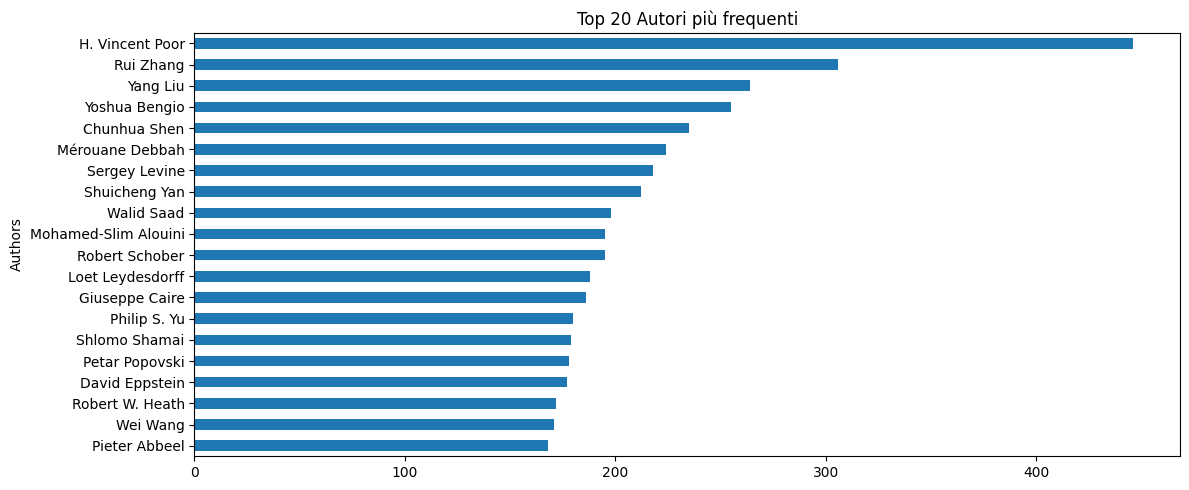

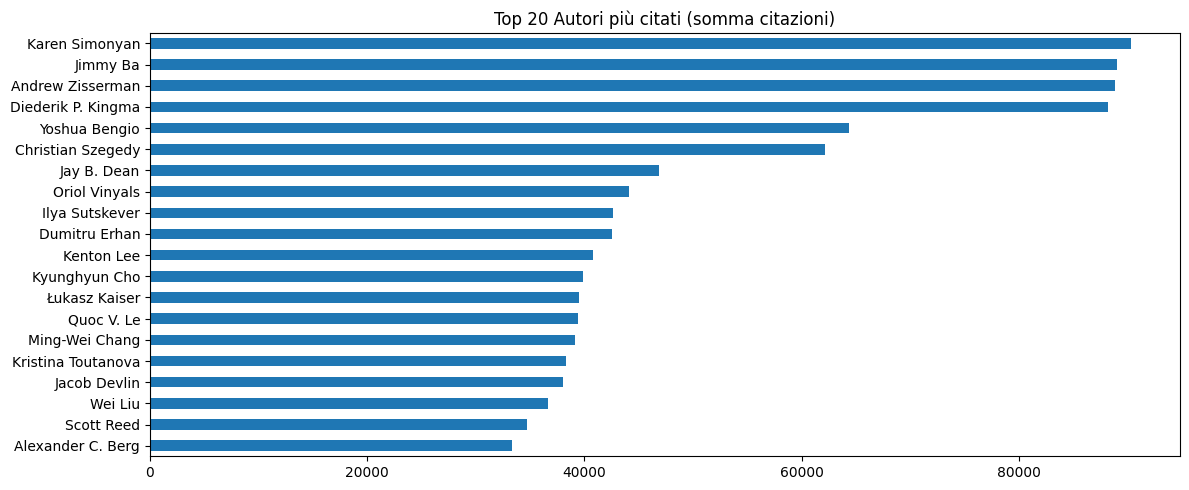

In [2]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# === 1. Carica il dataset ===
df = pd.read_csv("openalex_enriched_parallel.csv")

# === 2. Estrai tutti gli autori ===
all_authors = df['Authors'].dropna().str.split('; ').explode()
author_counts = all_authors.value_counts()

# === 3. Autori più frequenti ===
top_authors = author_counts.head(20)
print("👤 Autori più frequenti:")
print(top_authors)

# === 4. Autori più citati ===
author_citations = Counter()

for _, row in df.dropna(subset=["Authors", "Citations"]).iterrows():
    authors = row["Authors"].split("; ")
    citations = row["Citations"]
    for author in authors:
        author_citations[author] += citations

top_cited_authors = pd.Series(author_citations).sort_values(ascending=False).head(20)
print("\n🔥 Autori più citati:")
print(top_cited_authors)

# === 5. Visualizza (facoltativo) ===
plt.figure(figsize=(12, 5))
top_authors.plot(kind='barh', title='Top 20 Autori più frequenti')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
top_cited_authors.plot(kind='barh', title='Top 20 Autori più citati (somma citazioni)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# === 1. Carica il dataset ===
df = pd.read_csv("openalex_enriched_parallel.csv")

# === 2. Estrai e conta tutte le istituzioni ===
all_institutions = df['Institutions'].dropna().str.split('; ').explode()
institution_counts = all_institutions.value_counts()

# === 3. Istituzioni più frequenti ===
top_institutions = institution_counts.head(20)
print("🏛️ Istituzioni più frequenti:")
print(top_institutions)

# === 4. Istituzioni più citate ===
institution_citations = Counter()

for _, row in df.dropna(subset=["Institutions", "Citations"]).iterrows():
    institutions = row["Institutions"].split("; ")
    citations = row["Citations"]
    for inst in institutions:
        institution_citations[inst] += citations

top_cited_institutions = pd.Series(institution_citations).sort_values(ascending=False).head(20)
print("\n🔥 Istituzioni più citate:")
print(top_cited_institutions)

# === 5. Visualizza (facoltativo) ===
plt.figure(figsize=(12, 5))
top_institutions.plot(kind='barh', title='Top 20 Istituzioni più frequenti')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
top_cited_institutions.plot(kind='barh', title='Top 20 Istituzioni più citate (somma citazioni)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


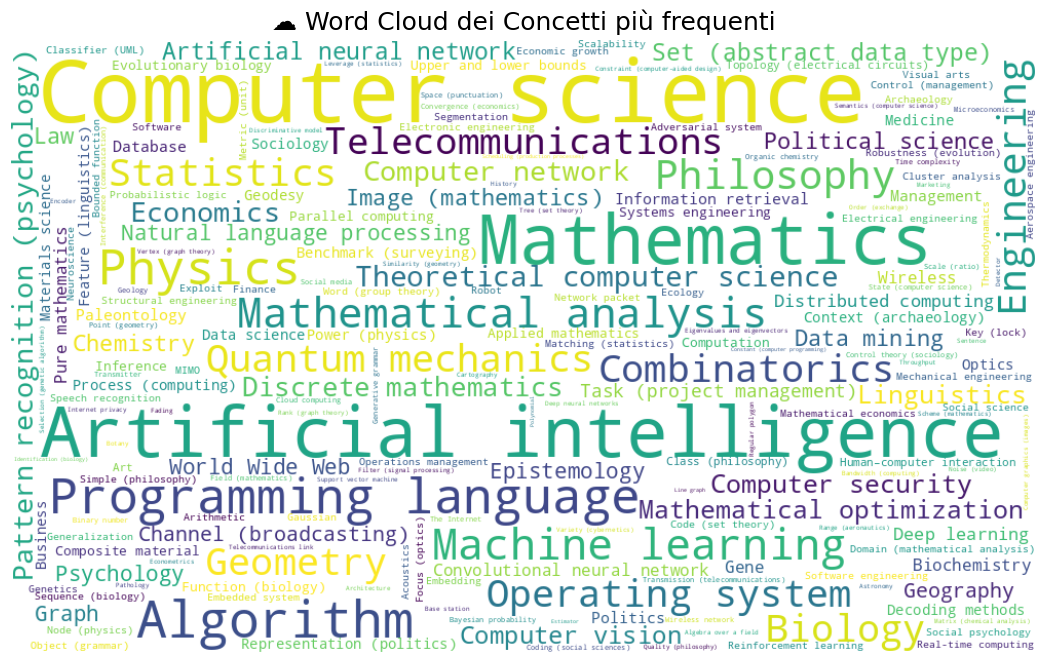

In [3]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# === 1. Carica dataset ===
df = pd.read_csv("openalex_enriched_parallel.csv")

# === 2. Unisci tutti i concetti ===
concepts_series = df['Concepts'].dropna().str.split('; ')
all_concepts = [concept for sublist in concepts_series for concept in sublist]

# === 3. Conta frequenze
from collections import Counter
concept_counts = Counter(all_concepts)

# === 4. Crea Word Cloud ===
wordcloud = WordCloud(width=1000, height=600, background_color='white', colormap='viridis')\
    .generate_from_frequencies(concept_counts)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("☁️ Word Cloud dei Concetti più frequenti", fontsize=18)
plt.show()


In [4]:
import pandas as pd
from collections import Counter

# === 1. Carica il dataset ===
df = pd.read_csv("openalex_enriched_parallel.csv")

# === 2. Filtro: paper con 'Università della Calabria' (anche in inglese)
calabria_mask = df['Institutions'].fillna('').str.contains('Calabria', case=False)
df_calabria = df[calabria_mask]

print(f"📄 Paper trovati con affiliazione 'Calabria': {len(df_calabria)}")

# === 3. Conta citazioni per autore (tra quelli affiliati)
author_citations = Counter()

for _, row in df_calabria.dropna(subset=["Authors", "Citations"]).iterrows():
    authors = row["Authors"].split("; ")
    citations = row["Citations"]
    for author in authors:
        author_citations[author] += citations

# === 4. Mostra i più citati
top_calabria_authors = pd.Series(author_citations).sort_values(ascending=False).head(20)

print("\n🎓 Autori più citati dell'Università della Calabria:")
print(top_calabria_authors)


📄 Paper trovati con affiliazione 'Calabria': 109

🎓 Autori più citati dell'Università della Calabria:
Nicola Leone            2177
Wolfgang Faber          1806
Francesco Scarcello     1783
Georg Gottlob           1725
Thomas Eiter            1449
Gerald Pfeifer          1410
Simona Perri            1255
Francesco Ricca          548
Francesco Calimeri       376
Giovambattista Ianni     357
Marco Maratea            342
Martin Gebser            299
Thomas Krennwallner      271
Roland Kaminski          232
Torsten Schaub           232
Gianluigi Greco          226
Andrea Tagarelli         205
Roberto Interdonato      192
Mario Alviano            180
Axel Polleres            175
dtype: int64


🔍 Concetti più studiati all'Università della Calabria:
Computer science                108
Programming language             69
Mathematics                      63
Theoretical computer science     61
Artificial intelligence          47
Set (abstract data type)         45
Answer set programming           34
Algorithm                        26
Biology                          24
Logic programming                21
Mathematical analysis            18
Semantics (computer science)     17
Discrete mathematics             16
Geometry                         16
Operating system                 15
Combinatorics                    14
Mathematical optimization        14
Telecommunications               14
Engineering                      13
Physics                          13
dtype: int64


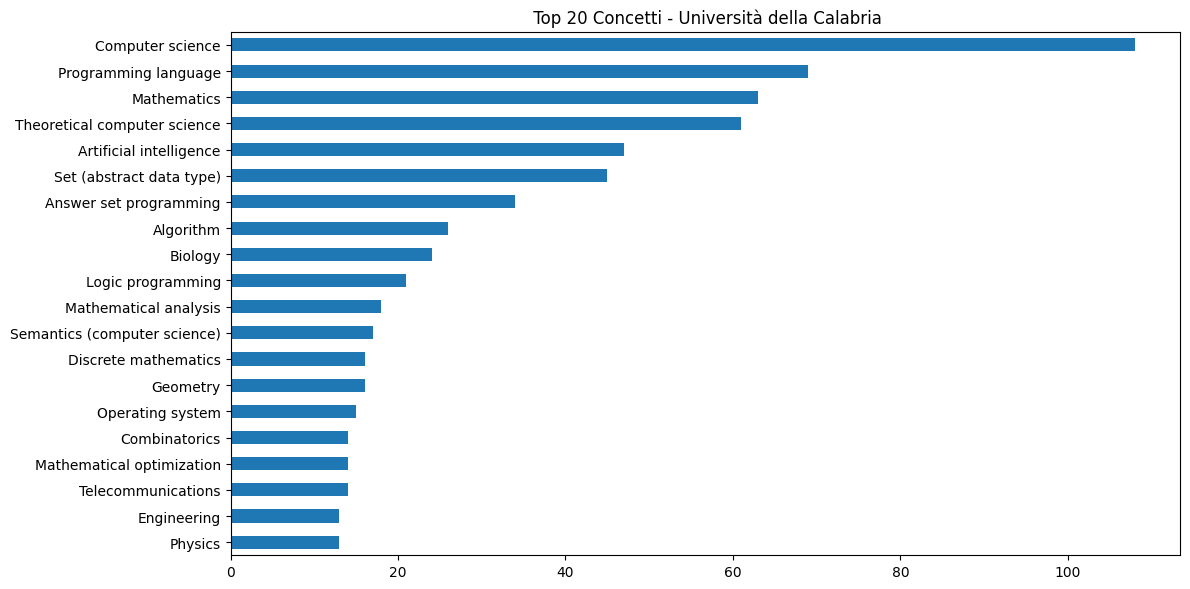

In [17]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# === 1. Carica il dataset ===
df = pd.read_csv("openalex_enriched_parallel.csv")

# === 2. Filtra i paper dell'Università della Calabria
calabria_mask = df['Institutions'].fillna('').str.contains('Calabria', case=False)
df_calabria = df[calabria_mask]

# === 3. Estrai tutti i concetti
concepts = df_calabria['Concepts'].dropna().str.split('; ')
all_concepts = [c for sublist in concepts for c in sublist]

# === 4. Conta frequenze
concept_counts = Counter(all_concepts)
top_concepts = pd.Series(concept_counts).sort_values(ascending=False).head(20)

print("🔍 Concetti più studiati all'Università della Calabria:")
print(top_concepts)

# === 5. Visualizza con barplot
plt.figure(figsize=(12, 6))
top_concepts.plot(kind='barh', title=' Top 20 Concetti - Università della Calabria')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [6]:
import torch
import pandas as pd
import numpy as np
from torch_geometric.transforms import ToUndirected
from ogb.nodeproppred import PygNodePropPredDataset
import os

# === 1. Imposta device su CPU ===
device = torch.device('cpu')

# === 2. Caricamento dataset ===
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
data = dataset[0].to(device)

# === 3. Carica il mapping OGBN_ID <-> MAG_ID ===
mapping_df = pd.read_csv("mag_ids.csv", dtype={"MAG_ID": str})
magid_to_ogbnid = dict(zip(mapping_df["MAG_ID"], mapping_df["OGBN_ID"]))

# === 4. Carica il CSV arricchito da OpenAlex ===
enriched_df = pd.read_csv("openalex_enriched_parallel.csv", dtype={"MAG_ID": str})

# === 5. Costruzione feature extra per ogni nodo ===
num_nodes = data.num_nodes
feature_dim = 5  # numero di nuove feature: Citations, n_Authors, n_Institutions, n_Concepts, anno_pubblicazione

new_features = torch.zeros((num_nodes, feature_dim), dtype=torch.float)

for _, row in enriched_df.iterrows():
    mag_id = row["MAG_ID"]
    ogbn_id = magid_to_ogbnid.get(mag_id, None)
    if ogbn_id is None:
        continue

    # Estrai valori
    citations = row.get("Citations", 0)
    n_authors = len(str(row.get("Authors", "")).split(";")) if pd.notnull(row.get("Authors")) else 0
    n_inst = len(str(row.get("Institutions", "")).split(";")) if pd.notnull(row.get("Institutions")) else 0
    n_concepts = len(str(row.get("Concepts", "")).split(";")) if pd.notnull(row.get("Concepts")) else 0

    # Parsing anno da Publication_Date
    try:
        year = int(str(row.get("Publication_Date", ""))[:4])
        year = max(1900, min(year, 2025))  # clamp
    except:
        year = 2000  # default

    # Normalizza anno (opzionale: range 0–1)
    norm_year = (year - 1900) / (2025 - 1900)

    # Assegna feature
    new_features[int(ogbn_id)] = torch.tensor([citations, n_authors, n_inst, n_concepts, norm_year])

# === 6. Normalizzazione (z-score robusta su nuove feature) ===
mask = (new_features.sum(dim=1) != 0)  # solo nodi con info
mean = new_features[mask].mean(dim=0)
std = new_features[mask].std(dim=0) + 1e-6
new_features = (new_features - mean) / std

# === 7. Estendi data.x solo se richiesto ===
ENRICH = True  # metti False per run vecchi!

if ENRICH:
    data.x = torch.cat([data.x, new_features], dim=1)
    print(f"✅ Feature arricchite: nuova shape data.x = {data.x.shape}")
else:
    print(f"⚠️ Arricchimento disattivato: data.x = {data.x.shape}")

# === (Opzionale) Salva grafo arricchito ===
torch.save(data.cpu(), "ogbn_arxiv_with_openalex_enriched.pt")
print("💾 Grafo salvato in 'ogbn_arxiv_with_openalex_enriched.pt'")


✅ Feature arricchite: nuova shape data.x = torch.Size([169343, 133])
💾 Grafo salvato in 'ogbn_arxiv_with_openalex_enriched.pt'


In [7]:
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.transforms import ToUndirected
import torch

# Carica dataset originale per ottenere split_idx
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/ogbn-arxiv', transform=ToUndirected())
split_idx = dataset.get_idx_split()

# Salva split_idx su disco
torch.save(split_idx, "split_idx.pt")
print("✅ split_idx salvato in 'split_idx.pt'")


✅ split_idx salvato in 'split_idx.pt'


In [8]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from ogb.nodeproppred import Evaluator

# === 1. Carica grafo arricchito ===
data = torch.load("ogbn_arxiv_with_openalex_enriched.pt")
split_idx = torch.load("split_idx.pt")  # Assicurati di salvare a parte se non incluso nel .pt
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cpu')
data = data.to(device)
train_idx = split_idx['train']
val_idx = split_idx['valid']
test_idx = split_idx['test']

# === 2. Definizione modello ===
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_path = "best_gcn_openalex.pt"
checkpoint_path = "checkpoint_gcn_openalex.pth"
log_path = "training_log_gcn_openalex.csv"

model = GCN(data.x.shape[1], 128, data.y.max().item() + 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# === 3. Resume da checkpoint se disponibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 4. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 5. Training con Early Stopping e Resume ===
early_stop_patience = 10
for epoch in range(start_epoch, start_epoch + 200):
    loss = train()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:03d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 6. Salva embedding dal miglior modello ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()
torch.save(embeddings, "gcn_node_embeddings_openalex.pt")
print("✅ Embedding salvati in 'gcn_node_embeddings_openalex.pt'")


🔁 Resume training da epoch 1201, best val acc: 0.7113
[Epoch 1210] Loss: 0.8331 | Train: 0.7448 | Val: 0.7109 | Test: 0.7016
⏳ Early stopping counter: 11/10
🛑 Early stopping attivato!
✅ Embedding salvati in 'gcn_node_embeddings_openalex.pt'


In [18]:
import os
import torch
import torch.nn.functional as F
from torch.nn import Dropout, LayerNorm
from torch_geometric.nn import GCNConv
from ogb.nodeproppred import Evaluator

# === 1. Carica grafo arricchito ===
data = torch.load("ogbn_arxiv_with_openalex_enriched.pt")
split_idx = torch.load("split_idx.pt")
evaluator = Evaluator(name='ogbn-arxiv')

device = torch.device('cpu')
data = data.to(device)
train_idx = split_idx['train']
val_idx = split_idx['valid']
test_idx = split_idx['test']

# === 2. Modello GCN migliorato ===
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.norm1 = LayerNorm(hidden_channels)
        self.dropout = Dropout(0.5)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

# === 3. Paths ===
model_path = "best_gcn_openalex_advanced.pt"
checkpoint_path = "checkpoint_gcn_openalex_advanced.pth"
log_path = "training_log_gcn_openalex_advanced.csv"

model = GCN(data.x.shape[1], 128, data.y.max().item() + 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# === 4. Resume da checkpoint se disponibile ===
start_epoch = 1
best_val_acc = 0.0
patience_counter = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint['patience_counter']
    print(f"🔁 Resume training da epoch {start_epoch}, best val acc: {best_val_acc:.4f}")
else:
    print("🆕 Inizio nuovo training...")

# === 5. Funzioni di training e valutazione ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x, data.edge_index)
    y_pred = out.argmax(dim=-1)
    return (
        evaluator.eval({'y_true': data.y[train_idx], 'y_pred': y_pred[train_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[val_idx], 'y_pred': y_pred[val_idx].unsqueeze(1)})['acc'],
        evaluator.eval({'y_true': data.y[test_idx], 'y_pred': y_pred[test_idx].unsqueeze(1)})['acc'],
    )

# === 6. Training con Early Stopping e Scheduler ===
early_stop_patience = 15
for epoch in range(start_epoch, start_epoch + 200):
    loss = train()
    
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = evaluate()
        print(f"[Epoch {epoch:04d}] Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
        scheduler.step(val_acc)

        with open(log_path, "a") as f:
            f.write(f"{epoch},{loss:.4f},{train_acc:.4f},{val_acc:.4f},{test_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("💾 Nuovo best model salvato")
        else:
            patience_counter += 1
            print(f"⏳ Early stopping counter: {patience_counter}/{early_stop_patience}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, checkpoint_path)

        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping attivato!")
            break

# === 7. Salva embedding finale ===
model.load_state_dict(torch.load(model_path))
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()
torch.save(embeddings, "gcn_node_embeddings_openalex_advanced.pt")
print("✅ Embedding salvati in 'gcn_node_embeddings_openalex_advanced.pt'")


import numpy as np

# Calcola predizioni
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    val_pred = out[val_idx].argmax(dim=1).cpu().numpy()
    test_pred = out[test_idx].argmax(dim=1).cpu().numpy()

# Salva come .npy per l'ensemble
np.save("gcn_val_pred.npy", val_pred)
np.save("gcn_test_pred.npy", test_pred)

print("✅ Predizioni GCN salvate come 'gcn_val_pred.npy' e 'gcn_test_pred.npy'")



🔁 Resume training da epoch 521, best val acc: 0.7101
[Epoch 0530] Loss: 0.9805 | Train: 0.7283 | Val: 0.7095 | Test: 0.7002
⏳ Early stopping counter: 11/15
[Epoch 0540] Loss: 0.9803 | Train: 0.7279 | Val: 0.7095 | Test: 0.7001
⏳ Early stopping counter: 12/15
[Epoch 0550] Loss: 0.9787 | Train: 0.7283 | Val: 0.7094 | Test: 0.6997
⏳ Early stopping counter: 13/15
[Epoch 0560] Loss: 0.9817 | Train: 0.7287 | Val: 0.7097 | Test: 0.7000
⏳ Early stopping counter: 14/15
[Epoch 0570] Loss: 0.9778 | Train: 0.7288 | Val: 0.7095 | Test: 0.7006
⏳ Early stopping counter: 15/15
🛑 Early stopping attivato!
✅ Embedding salvati in 'gcn_node_embeddings_openalex_advanced.pt'
✅ Predizioni GCN salvate come 'gcn_val_pred.npy' e 'gcn_test_pred.npy'


In [10]:
import torch
import xgboost as xgb
import numpy as np
import pandas as pd
from ogb.nodeproppred import Evaluator
from sklearn.metrics import accuracy_score
import os

# === 1. Carica embeddings, labels e split ===
embeddings = torch.load("gcn_node_embeddings_openalex.pt")
data = torch.load("ogbn_arxiv_with_openalex_enriched.pt")
split_idx = torch.load("split_idx.pt")

X = embeddings.numpy()
y = data.y.squeeze().numpy()
train_idx = split_idx['train'].numpy()
val_idx = split_idx['valid'].numpy()
test_idx = split_idx['test'].numpy()

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# === 2. Setup evaluator ===
evaluator = Evaluator(name="ogbn-arxiv")

def ogb_eval(y_true, y_pred):
    return evaluator.eval({
        "y_true": torch.tensor(y_true).unsqueeze(1),
        "y_pred": torch.tensor(y_pred).unsqueeze(1)
    })["acc"]

# === 3. Definizione modello ===
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=np.max(y) + 1,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    early_stopping_rounds=20,
    use_label_encoder=False,
    eval_metric="mlogloss",
    verbosity=1
)

# === 4. Training ===
print("🚀 Inizio training XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# === 5. Salvataggi ===
os.makedirs("xgboost_results", exist_ok=True)
model.save_model("xgboost_results/xgb_model_openalex.json")

# === 6. Predizioni e valutazione ===
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

val_acc = ogb_eval(y_val, y_val_pred)
test_acc = ogb_eval(y_test, y_test_pred)

print(f"\n📊 VALID Accuracy OGB: {val_acc:.4f}")
print(f"📊 TEST  Accuracy OGB: {test_acc:.4f}")

# === 7. Salva log in CSV ===
df_log = pd.DataFrame(model.evals_result()["validation_0"]["mlogloss"], columns=["mlogloss"])
df_log.to_csv("xgboost_results/xgb_training_log.csv", index_label="epoch")

# === 8. Salva predizioni ===
np.savez("xgboost_results/xgb_preds_openalex.npz", 
         y_val_pred=y_val_pred, y_test_pred=y_test_pred)

print("✅ Tutto salvato in ./xgboost_results/")


🚀 Inizio training XGBoost...


C:\Users\paolo\DM2\.venv\lib\site-packages\xgboost\callback.py:386: UserWarning: [15:55:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:2.74466
[1]	validation_0-mlogloss:2.46332
[2]	validation_0-mlogloss:2.26318
[3]	validation_0-mlogloss:2.10746
[4]	validation_0-mlogloss:1.98068
[5]	validation_0-mlogloss:1.87390
[6]	validation_0-mlogloss:1.78259
[7]	validation_0-mlogloss:1.70399
[8]	validation_0-mlogloss:1.63427
[9]	validation_0-mlogloss:1.57335
[10]	validation_0-mlogloss:1.51863
[11]	validation_0-mlogloss:1.46985
[12]	validation_0-mlogloss:1.42615
[13]	validation_0-mlogloss:1.38669
[14]	validation_0-mlogloss:1.35079
[15]	validation_0-mlogloss:1.31809
[16]	validation_0-mlogloss:1.28815
[17]	validation_0-mlogloss:1.26109
[18]	validation_0-mlogloss:1.23639
[19]	validation_0-mlogloss:1.21386
[20]	validation_0-mlogloss:1.19338
[21]	validation_0-mlogloss:1.17425
[22]	validation_0-mlogloss:1.15685
[23]	validation_0-mlogloss:1.14103
[24]	validation_0-mlogloss:1.12640
[25]	validation_0-mlogloss:1.11292
[26]	validation_0-mlogloss:1.10022
[27]	validation_0-mlogloss:1.08851
[28]	validation_0-mlogloss:1.0

In [11]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# === Caricamento dati ===
embeddings = torch.load("gcn_node_embeddings_openalex.pt")
data = torch.load("ogbn_arxiv_with_openalex_enriched.pt")
split_idx = torch.load("split_idx.pt")

X = embeddings.numpy()
y = data.y.squeeze().numpy()
train_idx = split_idx['train'].numpy()
val_idx = split_idx['valid'].numpy()
test_idx = split_idx['test'].numpy()

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# === Classificatori ===
classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "DecisionTree": DecisionTreeClassifier(),
    "NaiveBayes": GaussianNB(),
    "SVM": make_pipeline(StandardScaler(), LinearSVC(max_iter=10000, dual=False))
}

results = []

for name, clf in classifiers.items():
    print(f"\n🔧 Training {name}...")
    clf.fit(X_train, y_train)
    val_pred = clf.predict(X_val)
    test_pred = clf.predict(X_test)

    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append((name, val_acc, test_acc))

    # Salvataggio predizioni
    np.save(f"{name}_val_pred.npy", val_pred)
    np.save(f"{name}_test_pred.npy", test_pred)

# === Salva i risultati ===
df_results = pd.DataFrame(results, columns=["Model", "Validation Accuracy", "Test Accuracy"])
df_results.to_csv("classical_model_results.csv", index=False)

print("\n✅ Risultati salvati in 'classical_model_results.csv'")
print(df_results)



🔧 Training KNN...

🔧 Training LogisticRegression...

🔧 Training DecisionTree...

🔧 Training NaiveBayes...

🔧 Training SVM...

✅ Risultati salvati in 'classical_model_results.csv'
                Model  Validation Accuracy  Test Accuracy
0                 KNN             0.674251       0.656318
1  LogisticRegression             0.708312       0.698990
2        DecisionTree             0.582201       0.570129
3          NaiveBayes             0.574415       0.565850
4                 SVM             0.694990       0.682262


In [12]:
import numpy as np
from sklearn.metrics import accuracy_score
from scipy.stats import mode

import numpy as np

y_val = data.y[val_idx].squeeze().cpu().numpy()
y_test = data.y[test_idx].squeeze().cpu().numpy()

np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("✅ Etichette salvate: y_val.npy, y_test.npy")


# Carica le predizioni
gcn_val = np.load("gcn_val_pred.npy")
log_val = np.load("LogisticRegression_val_pred.npy")
svm_val = np.load("SVM_val_pred.npy")

gcn_test = np.load("gcn_test_pred.npy")
log_test = np.load("LogisticRegression_test_pred.npy")
svm_test = np.load("SVM_test_pred.npy")

# Hard voting
val_preds = np.vstack([gcn_val, log_val, svm_val])
test_preds = np.vstack([gcn_test, log_test, svm_test])

val_ensemble = mode(val_preds, axis=0).mode.squeeze()
test_ensemble = mode(test_preds, axis=0).mode.squeeze()

# Ground truth
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

val_acc = accuracy_score(y_val, val_ensemble)
test_acc = accuracy_score(y_test, test_ensemble)

print(f"✅ Ensemble Voting - Validation Accuracy: {val_acc:.4f}")
print(f"✅ Ensemble Voting - Test Accuracy: {test_acc:.4f}")

np.save("ensemble_val_pred.npy", val_ensemble)
np.save("ensemble_test_pred.npy", test_ensemble)


✅ Etichette salvate: y_val.npy, y_test.npy
✅ Ensemble Voting - Validation Accuracy: 0.7101
✅ Ensemble Voting - Test Accuracy: 0.6985


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score
from ogb.nodeproppred import Evaluator

# === Parametri Ensemble ===
ENSEMBLE_SIZE = 5
EPOCHS = 200
HIDDEN_DIM = 256
LR = 1e-3
DROPOUT = 0.5

# === Carica dati ===
embeddings = torch.load("gcn_node_embeddings_openalex_advanced.pt")
data = torch.load("ogbn_arxiv_with_openalex_enriched.pt")
split_idx = torch.load("split_idx.pt")

X = embeddings.numpy()
y = data.y.squeeze().numpy()
train_idx = split_idx["train"].numpy()
val_idx = split_idx["valid"].numpy()
test_idx = split_idx["test"].numpy()

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# === Evaluator OGB-style ===
evaluator = Evaluator(name="ogbn-arxiv")
def ogb_eval(y_true, y_pred):
    return evaluator.eval({
        "y_true": torch.tensor(y_true).unsqueeze(1),
        "y_pred": torch.tensor(y_pred).unsqueeze(1)
    })["acc"]

# === MLP semplice ===
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# === Ensemble Training ===
val_logits_all = []
test_logits_all = []

for run in range(ENSEMBLE_SIZE):
    print(f"🚀 MLP {run+1}/{ENSEMBLE_SIZE}")
    model = MLP(X.shape[1], HIDDEN_DIM, np.max(y)+1, DROPOUT)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    for epoch in range(EPOCHS):
        model.train()
        logits = model(X_train_t)
        loss = loss_fn(logits, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Eval
    model.eval()
    with torch.no_grad():
        val_logits = model(torch.tensor(X_val, dtype=torch.float32))
        test_logits = model(torch.tensor(X_test, dtype=torch.float32))
        val_logits_all.append(val_logits)
        test_logits_all.append(test_logits)

# === Media softmax (soft voting)
val_probs_avg = torch.softmax(torch.stack(val_logits_all).mean(dim=0), dim=1)
test_probs_avg = torch.softmax(torch.stack(test_logits_all).mean(dim=0), dim=1)

val_pred = val_probs_avg.argmax(dim=1).numpy()
test_pred = test_probs_avg.argmax(dim=1).numpy()

# === Accuracy
val_acc = ogb_eval(y_val, val_pred)
test_acc = ogb_eval(y_test, test_pred)

print(f"\n✅ MLP Ensemble Accuracy - Val: {val_acc:.4f} | Test: {test_acc:.4f}")


🚀 MLP 1/5
🚀 MLP 2/5
🚀 MLP 3/5
🚀 MLP 4/5
🚀 MLP 5/5

✅ MLP Ensemble Accuracy - Val: 0.7021 | Test: 0.6899


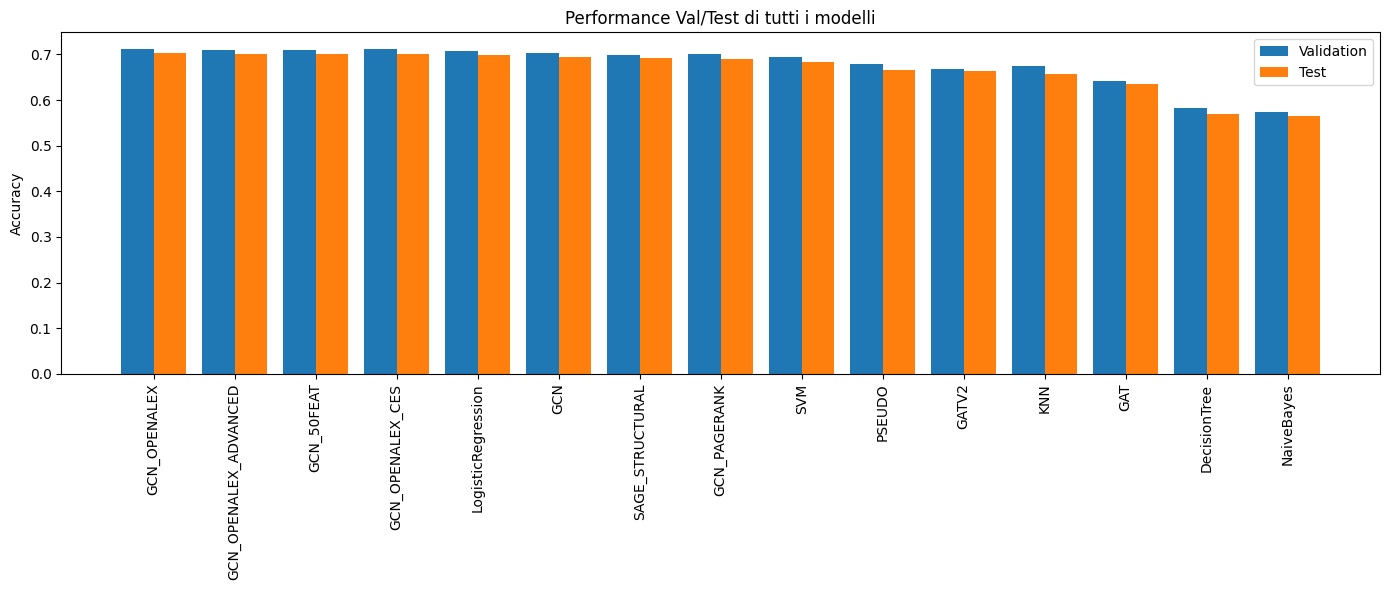

,Model,Validation Accuracy,Test Accuracy,Type
0,GCN_OPENALEX,0.711300,0.702200,GNN
1,GCN_OPENALEX_ADVANCED,0.710100,0.700200,GNN
2,GCN_50FEAT,0.709900,0.700100,GNN
3,GCN_OPENALEX_CES,0.712700,0.699900,GNN
4,LogisticRegression,0.708312,0.698990,Classical
5,GCN,0.703400,0.694500,GNN
6,SAGE_STRUCTURAL,0.697700,0.693000,GNN
7,GCN_PAGERANK,0.700700,0.690200,GNN
8,SVM,0.694990,0.682262,Classical
9,PSEUDO,0.678400,0.664700,GNN


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob
from IPython.display import display

# === 1. Carica risultati modelli classici ===
df_classical = pd.read_csv("classical_model_results.csv")
df_classical["Type"] = "Classical"

# === 2. Carica log dei modelli GNN ===
log_files = glob("training_log_*.csv")
gnn_rows = []
for file in log_files:
    try:
        df = pd.read_csv(file)
        # Ignora file non compatibili
        if "val_acc" not in df.columns or "test_acc" not in df.columns:
            print(f"⚠️ File {file} saltato: colonne mancanti")
            continue
        model_name = os.path.basename(file).replace("training_log_", "").replace(".csv", "").upper()
        val_acc = df["val_acc"].max()
        test_acc = df.loc[df["val_acc"].idxmax(), "test_acc"]
        gnn_rows.append({
            "Model": model_name,
            "Validation Accuracy": val_acc,
            "Test Accuracy": test_acc,
            "Type": "GNN"
        })
    except Exception as e:
        print(f"⚠️ Errore su {file}: {e}")

df_gnn = pd.DataFrame(gnn_rows)

# === 3. Unione e ordinamento ===
df_all = pd.concat([df_classical, df_gnn], ignore_index=True)
df_all["Validation Accuracy"] = pd.to_numeric(df_all["Validation Accuracy"], errors="coerce")
df_all["Test Accuracy"] = pd.to_numeric(df_all["Test Accuracy"], errors="coerce")
df_all_sorted = df_all.sort_values("Test Accuracy", ascending=False)

# === 4. Bar chart ===
plt.figure(figsize=(14, 6))
bar_width = 0.4
x = np.arange(len(df_all_sorted))
plt.bar(x - bar_width/2, df_all_sorted["Validation Accuracy"], bar_width, label="Validation")
plt.bar(x + bar_width/2, df_all_sorted["Test Accuracy"], bar_width, label="Test")
plt.xticks(x, df_all_sorted["Model"], rotation=90)
plt.ylabel("Accuracy")
plt.title("Performance Val/Test di tutti i modelli")
plt.legend()
plt.tight_layout()
plt.savefig("confronto_modelli_val_test.png")
plt.show()

# === 5. Mostra tabella ordinata
display(df_all_sorted.reset_index(drop=True))

# === 6. (Opzionale) Salva tabella
df_all_sorted.to_csv("confronto_finale_risultati.csv", index=False)


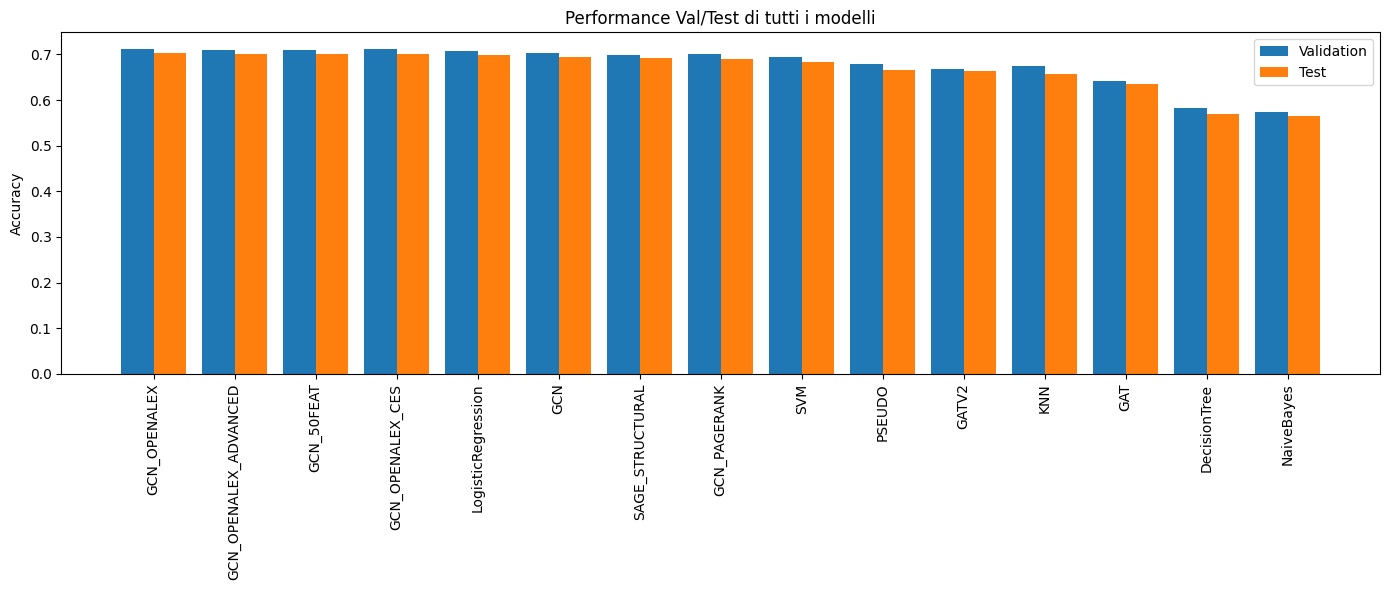

,Model,Validation Accuracy,Test Accuracy,Type
0,GCN_OPENALEX,0.711300,0.702200,GNN
1,GCN_OPENALEX_ADVANCED,0.710100,0.700200,GNN
2,GCN_50FEAT,0.709900,0.700100,GNN
3,GCN_OPENALEX_CES,0.712700,0.699900,GNN
4,LogisticRegression,0.708312,0.698990,Classical
5,GCN,0.703400,0.694500,GNN
6,SAGE_STRUCTURAL,0.697700,0.693000,GNN
7,GCN_PAGERANK,0.700700,0.690200,GNN
8,SVM,0.694990,0.682262,Classical
9,PSEUDO,0.678400,0.664700,GNN


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob
from IPython.display import display

# === 1. Carica risultati modelli classici ===
df_classical = pd.read_csv("classical_model_results.csv")
df_classical["Type"] = "Classical"

# === 2. Carica log dei modelli GNN ===
log_files = glob("training_log_*.csv")
gnn_rows = []
for file in log_files:
    try:
        df = pd.read_csv(file)
        # Ignora file non compatibili
        if "val_acc" not in df.columns or "test_acc" not in df.columns:
            print(f"⚠️ File {file} saltato: colonne mancanti")
            continue
        model_name = os.path.basename(file).replace("training_log_", "").replace(".csv", "").upper()
        val_acc = df["val_acc"].max()
        test_acc = df.loc[df["val_acc"].idxmax(), "test_acc"]
        gnn_rows.append({
            "Model": model_name,
            "Validation Accuracy": val_acc,
            "Test Accuracy": test_acc,
            "Type": "GNN"
        })
    except Exception as e:
        print(f"⚠️ Errore su {file}: {e}")

df_gnn = pd.DataFrame(gnn_rows)

# === 3. Unione e ordinamento ===
df_all = pd.concat([df_classical, df_gnn], ignore_index=True)
df_all["Validation Accuracy"] = pd.to_numeric(df_all["Validation Accuracy"], errors="coerce")
df_all["Test Accuracy"] = pd.to_numeric(df_all["Test Accuracy"], errors="coerce")
df_all_sorted = df_all.sort_values("Test Accuracy", ascending=False)

# === 4. Bar chart ===
plt.figure(figsize=(14, 6))
bar_width = 0.4
x = np.arange(len(df_all_sorted))
plt.bar(x - bar_width/2, df_all_sorted["Validation Accuracy"], bar_width, label="Validation")
plt.bar(x + bar_width/2, df_all_sorted["Test Accuracy"], bar_width, label="Test")
plt.xticks(x, df_all_sorted["Model"], rotation=90)
plt.ylabel("Accuracy")
plt.title("Performance Val/Test di tutti i modelli")
plt.legend()
plt.tight_layout()
plt.savefig("confronto_modelli_val_test.png")
plt.show()

# === 5. Mostra tabella ordinata
display(df_all_sorted.reset_index(drop=True))

# === 6. (Opzionale) Salva tabella
df_all_sorted.to_csv("confronto_finale_risultati.csv", index=False)


In [19]:
import torch
import torch.nn.functional as F
from xgboost import XGBClassifier
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected
import optuna
import numpy as np

# === 1. Caricamento ===
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/ogbn-arxiv", transform=ToUndirected())
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name="ogbn-arxiv")

y_true = data.y.squeeze().cpu().numpy()
embeddings = torch.load("gcn_node_embeddings_openalex.pt")
X = embeddings.numpy()

X_train = X[split_idx['train']]
y_train = y_true[split_idx['train']]
X_valid = X[split_idx['valid']]
y_valid = y_true[split_idx['valid']]
X_test = X[split_idx['test']]
y_test = y_true[split_idx['test']]

# === 2. Allena XGBoost sui logits del GCN ===
model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# === 3. Ottieni i logits probabilistici ===
probs = model.predict_proba(X)
logits_xgb = torch.tensor(probs)

# === 4. Optuna per ottimizzare Correct & Smooth ===
import torch
from torch_geometric.nn.models import CorrectAndSmooth

def objective(trial):
    correction_alpha = trial.suggest_float("correction_alpha", 0.3, 0.7)
    smoothing_alpha = trial.suggest_float("smoothing_alpha", 0.6, 0.95)
    num_correction_layers = trial.suggest_int("num_correction_layers", 20, 60, step=10)
    num_smoothing_layers = trial.suggest_int("num_smoothing_layers", 20, 60, step=10)

    y_soft = F.softmax(logits_xgb, dim=1)

    cs = CorrectAndSmooth(
        num_correction_layers=num_correction_layers,
        correction_alpha=correction_alpha,
        num_smoothing_layers=num_smoothing_layers,
        smoothing_alpha=smoothing_alpha,
        autoscale=True
    )

    y_soft_cs = cs.correct(y_soft.clone(), torch.tensor(y_train), split_idx['train'], data.edge_index)
    y_soft_cs = cs.smooth(y_soft_cs, torch.tensor(y_train), split_idx['train'], data.edge_index)

    y_pred_val = y_soft_cs.argmax(dim=-1, keepdim=True)
    y_true_val = torch.tensor(y_true[split_idx['valid']]).unsqueeze(1)

    val_acc = evaluator.eval({
        "y_true": y_true_val,
        "y_pred": y_pred_val[split_idx['valid']]
    })["acc"]

    return val_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("🏆 Best parameters:", study.best_params)
print("✅ Best validation accuracy:", study.best_value)


C:\Users\paolo\DM2\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [19:02:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-05-04 19:10:20,760] A new study created in memory with name: no-name-bdb81d3f-63ef-4d78-ad31-a199e5fb352d
[I 2025-05-04 19:10:49,153] Trial 0 finished with value: 0.7062988690895667 and parameters: {'correction_alpha': 0.34173839021914765, 'smoothing_alpha': 0.8038557215203858, 'num_correction_layers': 20, 'num_smoothing_layers': 50}. Best is trial 0 with value: 0.7062988690895667.
[I 2025-05-04 19:11:16,334] Trial 1 finished with value: 0.7054934729353334 and parameters: {'correction_alpha': 0.5733449060457414, 'smoothing_alpha': 0.6335356615976261, 'num_correction_layers': 60, 'num_smoothing_layers': 20}. Best is trial 0 with value: 0.7062988690895667.
[I 2025-05-04 19:11:29,750] Trial 2 finished with value: 0.7041175878385

🏆 Best parameters: {'correction_alpha': 0.4659613726192571, 'smoothing_alpha': 0.8152493444030221, 'num_correction_layers': 60, 'num_smoothing_layers': 60}
✅ Best validation accuracy: 0.7082788013020571
